# PCA Dynamic NWB-Only (v2)

NWB-only pipeline. No `df_units.json` or `df_stim.json` is needed.


### Suggestions on how to improve Notebook
1. okay how can i now run each of these PCAs on a per probe level. For example in the df_units there is the column header "probe", values for "probe" can be either (A,B,C,D,E,F). 

### Imports


In [28]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pynwb import NWBHDF5IO
from scipy.ndimage import gaussian_filter1d

sns.set_context("talk")
sns.set_style("white")
warnings.filterwarnings("ignore")


### Set NP Recording Folder name here:

In [29]:
NP_Recording_name = 'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00'


### Setting up root save path for PCA plots

In [30]:
NP_root_path = rf"H:\Grant\Neuropixels\Kilosort_Recordings\{NP_Recording_name}"
if not Path(NP_root_path).exists():
    print(f"Directory {NP_root_path} does not exist. Please check the path and try again.")
    raise FileNotFoundError(f"Directory {NP_root_path} does not exist. Please check the path and try again.")

root_PCA_plot_save_path = Path(NP_root_path) / "PCA_plots"
if not root_PCA_plot_save_path.exists():
    root_PCA_plot_save_path.mkdir(exist_ok=True)
    print(f"Created directory for PCA plots at: {root_PCA_plot_save_path}")
else:
    print(f"Directory for PCA plots already exists at: {root_PCA_plot_save_path}")

Directory for PCA plots already exists at: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots


### this allows plots to be saved to the same directory as the data, which is useful for organization and sharing.

In [31]:
def _sanitize_name(x: str) -> str:
    s = str(x)
    bad = ['\\', '/', ':', '*', '?', '"', '<', '>', '|']
    for b in bad:
        s = s.replace(b, '_')
    return s.strip().replace(' ', '_')


### NWB Loader


In [32]:
class nwb_loader:
    def __init__(self, nwb_path):
        self.nwb_path = str(nwb_path)
        self.io = None
        self.nwb = None
        self.load_nwb()

    def load_nwb(self):
        self.io = NWBHDF5IO(self.nwb_path, "r", load_namespaces=True)
        self.nwb = self.io.read()
        return self.nwb

    def trials(self):
        return self.nwb.trials.to_dataframe() if self.nwb.trials is not None else pd.DataFrame()

    def units(self):
        return self.nwb.units.to_dataframe() if self.nwb.units is not None else pd.DataFrame()

    def optogenetics_states(self):
        if "optogenetics_states" in self.nwb.intervals:
            return self.nwb.intervals["optogenetics_states"].to_dataframe()
        return pd.DataFrame()

    def close(self):
        try:
            if self.io is not None:
                self.io.close()
        except Exception:
            pass


### Config


In [34]:
NWB_PATH = Path(r"G:\Grant\neuropixels\nwb\Reach15")

WINDOW_START_S = -0.5
WINDOW_END_S = 3.5
BIN_SIZE_S = 0.05
N_COMPONENTS = 12
SMOOTH_SIGMA = 2

LABEL_MODE = "block"   # 'block' or 'stimulus'
EVENT_INCLUDE = None    # e.g., ['reach'] or None

# Memory safety controls
MAX_EVENTS = 5000                 # hard cap on analyzed events (None disables)
EVENT_SUBSAMPLE_MODE = "uniform"  # 'uniform' or 'first'
MAX_TENSOR_GB = 8.0               # abort if trials tensor estimate exceeds this

PROBE_FILTER = None     # 'A'..'F' or None
KSLABEL_FILTER = None   # 'good'/'mua' or 2/1 or None
UNIT_FILTER_QUERY = None
MAX_UNITS = None

OUT_DIR = Path.cwd() / "extra_files"
OUT_DIR.mkdir(parents=True, exist_ok=True)


### Helpers


In [35]:
def resolve_nwb_path(p: Path) -> Path:
    if not p.exists():
        raise FileNotFoundError(f"NWB path not found: {p}")
    if p.is_file():
        return p
    nwb_files = sorted(list(p.rglob("*.nwb")))
    if len(nwb_files) == 1:
        return nwb_files[0]
    if len(nwb_files) > 1:
        raise ValueError("Multiple NWB files found. Point NWB_PATH to one file.")
    files = [x for x in p.iterdir() if x.is_file()]
    if len(files) == 1:
        return files[0]
    raise ValueError("Could not resolve a unique NWB file path.")


def zscore_rows(x: np.ndarray) -> np.ndarray:
    ss = StandardScaler(with_mean=True, with_std=True)
    return ss.fit_transform(x.T).T


def choose_event_time_col(df: pd.DataFrame) -> str:
    for c in ["start_time", "time", "event_time", "timestamps"]:
        if c in df.columns:
            return c
    raise ValueError(f"No event-time column found in trials table. Columns: {list(df.columns)}")


def normalize_kslabel(v):
    if pd.isna(v):
        return np.nan
    try:
        iv = int(float(v))
        if iv == 2:
            return "good"
        if iv == 1:
            return "mua"
    except Exception:
        pass
    s = str(v).strip().lower()
    if s in {"2", "good", "single", "singleunit", "single_unit"}:
        return "good"
    if s in {"1", "mua", "multi", "multiunit", "multi_unit"}:
        return "mua"
    return s


def infer_is_opto(df_trials: pd.DataFrame) -> pd.Series:
    if "optogenetics_LED_state" in df_trials.columns:
        c = df_trials["optogenetics_LED_state"]
        if pd.api.types.is_numeric_dtype(c):
            return pd.to_numeric(c, errors="coerce").fillna(0) > 0
        return c.astype(str).str.lower().isin(["1", "true", "on", "high"])
    if "stimulus" in df_trials.columns:
        s = df_trials["stimulus"].astype(str).str.lower()
        return s.str.contains("opto|laser|led|stim", regex=True)
    return pd.Series([False] * len(df_trials), index=df_trials.index)


def build_block_labels(is_opto: pd.Series) -> pd.DataFrame:
    is_opto = is_opto.astype(bool).reset_index(drop=True)
    block_id = (is_opto != is_opto.shift(1, fill_value=is_opto.iloc[0])).cumsum()

    mapping = {}
    seen_opto = False
    opto_k = 1
    wash_k = 1
    for b in block_id.unique():
        state = bool(is_opto[block_id == b].iloc[0])
        if state:
            mapping[b] = f"opto_epoch_{opto_k}"
            opto_k += 1
            seen_opto = True
        else:
            mapping[b] = "baseline" if not seen_opto else f"washout_epoch_{wash_k}"
            if seen_opto:
                wash_k += 1

    return pd.DataFrame({"block_id": block_id, "is_opto": is_opto, "block_label": block_id.map(mapping)})


def find_probe_col(df: pd.DataFrame):
    for c in ["probe", "probe_name", "probe_id", "probe_letter", "electrode_group"]:
        if c in df.columns:
            return c
    return None


def find_kslabel_col(df: pd.DataFrame):
    for c in ["KSLabel", "kslabel", "ks_label", "label", "quality"]:
        if c in df.columns:
            return c
    return None


def pick_region_col(df: pd.DataFrame):
    for c in ["brain_region", "location", "region", "acronym", "structure", "ccf_acronym"]:
        if c in df.columns:
            return c
    return None


### Load NWB Tables


In [36]:
resolved_nwb = resolve_nwb_path(NWB_PATH)
mouse = nwb_loader(resolved_nwb)

df_trials = mouse.trials().reset_index(drop=True)
df_units = mouse.units().reset_index(drop=True)
df_stim_unModifed = mouse.trials().reset_index(drop=True)

print("NWB:", resolved_nwb)
print("trials shape:", df_trials.shape)
print("units shape:", df_units.shape)
print("trials columns:", list(df_trials.columns))
print("units columns:", list(df_units.columns))


NWB: G:\Grant\neuropixels\nwb\Reach15
trials shape: (1352824, 4)
units shape: (4600, 9)
trials columns: ['start_time', 'stop_time', 'stimulus', 'optogenetics_LED_state']
units columns: ['depth', 'xpos', 'ypos', 'label', 'KSlabel', 'KSamplitude', 'KScontamination', 'probe', 'spike_times']


In [37]:
# print unique names inside stimulus
unit_probes = np.array(df_units.probe.unique())
unit_headers = df_units.columns.tolist()
df_units_dic = {}

print('===== Total units Per Probe ====')
for probe in unit_probes:
    df = df_units[df_units['probe']==probe]
    print(f'{probe}: ', len(df))
    df_units_dic[probe] = df
print('\n')
probe_letter = 'A'
print(f'Comapre with Above: total units in probe {probe_letter}: ', len(df_units_dic[probe_letter]))
df_units_dic[probe_letter][0:5]

===== Total units Per Probe ====
A:  554
B:  1316
C:  355
D:  820
E:  864
F:  691


Comapre with Above: total units in probe A:  554


,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,"[9938.427594575005, 9938.443329123113, 9938.44..."
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,"[9938.363989665882, 9938.408826460065, 9938.42..."
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,"[9938.135738714089, 9939.27045963741, 9940.801..."
3,2775.0,27.0,375.0,0,2,8.5,0.0,A,"[9938.897430842511, 9940.381573391209, 9941.04..."
4,2745.0,59.0,405.0,0,2,9.1,7.4,A,"[9938.29451763671, 9938.519134975282, 9938.609..."


### Load bombcell Results

In [10]:
qm_df_list = []
qm_dic = {}
# set root bombcell path 
for probe in unit_probes:
    print(f'Loading Probe {probe} quality_metrics.csv')
    bc_qm_path = fr"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_{probe}\bombcell\Probe_{probe}_quality_metrics.csv"
    # print('      ',bc_qm_path)
    qm_df = pd.read_csv(bc_qm_path)
    qm_df_list.append(qm_df)
    qm_dic[probe] = qm_df

### Look at one of the probes quality_metrics.csv from the dic
probe_letter = "B"
qm_dic[probe_letter]

Loading Probe A quality_metrics.csv
Loading Probe B quality_metrics.csv
Loading Probe C quality_metrics.csv
Loading Probe D quality_metrics.csv
Loading Probe E quality_metrics.csv
Loading Probe F quality_metrics.csv


,Bombcell_unit_type,bc_roiLabel,cluster_id,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,...,maxDriftEstimate,cumDriftEstimate,rawAmplitude,signalToNoiseRatio,isolationDistance,Lratio,silhouetteScore,useTheseTimesStart,useTheseTimesStop,maxChannels
0,MUA,IN_ROI,0,0,342314.0,1.0,1.0,166.666667,0.013970,0.020126,...,11.119194,57.314980,72.875717,14.510937,NaN,NaN,NaN,0.000067,9295.179267,2
1,MUA,IN_ROI,1,1,93291.0,2.0,1.0,133.333333,0.021148,0.050982,...,25.348637,271.297123,23.371343,2.061966,NaN,NaN,NaN,0.000067,9295.179267,0
2,NOISE,IN_ROI,2,2,21451.0,1.0,1.0,700.000000,0.017437,0.126556,...,9.852627,236.820278,51.590074,13.997928,NaN,NaN,NaN,0.000067,9295.179267,1
3,MUA,IN_ROI,3,3,48982.0,1.0,1.0,200.000000,0.020088,0.015577,...,21.799164,422.647194,65.607953,8.144144,NaN,NaN,NaN,0.000067,9295.179267,1
4,GOOD,IN_ROI,4,4,17269.0,1.0,1.0,233.333333,0.030410,0.021121,...,29.794754,330.584137,47.304186,7.611712,NaN,NaN,NaN,0.000067,9295.179267,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1311,MUA,OUT_ROI,1311,1311,94232.0,1.0,1.0,133.333333,0.018073,0.024039,...,3778.352539,33845.103516,20.537167,2.396758,NaN,NaN,NaN,0.000067,9295.179267,357
1312,MUA,OUT_ROI,1312,1312,1486.0,1.0,1.0,300.000000,0.025199,0.036436,...,25.231201,118.135742,13.312992,3.542415,NaN,NaN,NaN,0.000067,9295.179267,357
1313,NON-SOMA,OUT_ROI,1313,1313,1175.0,1.0,1.0,233.333333,0.022037,0.047541,...,23.249023,273.681641,46.155959,5.259838,NaN,NaN,NaN,0.000067,9295.179267,357
1314,MUA,OUT_ROI,1314,1314,2601.0,1.0,1.0,166.666667,0.024749,0.053390,...,20.525635,31.273438,11.809050,2.343361,NaN,NaN,NaN,0.000067,9295.179267,357


In [11]:
### Look at one of the probes quality_metrics.csv from the dic
probe_letter = "E"
qm_dic[probe_letter]

,Bombcell_unit_type,bc_roiLabel,cluster_id,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,...,maxDriftEstimate,cumDriftEstimate,rawAmplitude,signalToNoiseRatio,isolationDistance,Lratio,silhouetteScore,useTheseTimesStart,useTheseTimesStop,maxChannels
0,NON-SOMA,IN_ROI,0,0,302.0,1.0,1.0,200.0,0.018677,0.010223,...,24.241371,469.517036,17.205716,3.098545,NaN,NaN,NaN,0.0003,9295.2395,25
1,NON-SOMA,IN_ROI,1,1,23063.0,1.0,1.0,200.0,0.023395,0.034017,...,19.156597,157.544125,47.435221,14.550487,NaN,NaN,NaN,0.0003,9295.2395,1
2,NOISE,IN_ROI,2,2,41013.0,2.0,2.0,400.0,0.037405,0.127608,...,13.474518,113.402157,68.206922,12.086486,NaN,NaN,NaN,0.0003,9295.2395,21
3,MUA,IN_ROI,3,3,2558.0,2.0,1.0,500.0,0.023233,0.142165,...,42.070847,1042.221340,82.300007,15.866048,NaN,NaN,NaN,0.0003,9295.2395,21
4,NOISE,IN_ROI,4,4,25540.0,2.0,2.0,100.0,0.055958,0.036925,...,37.151985,558.720367,10.219774,1.739762,NaN,NaN,NaN,0.0003,9295.2395,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,MUA,OUT_ROI,859,859,39987.0,2.0,1.0,700.0,0.069340,0.161780,...,53.915283,662.756836,151.221590,63.154808,NaN,NaN,NaN,0.0003,9295.2395,380
860,MUA,OUT_ROI,860,860,54200.0,2.0,1.0,200.0,0.060062,0.009964,...,48.777100,758.604248,205.234832,113.377360,NaN,NaN,NaN,0.0003,9295.2395,380
861,MUA,OUT_ROI,861,861,200691.0,2.0,1.0,600.0,0.020898,0.113920,...,63.108643,508.811035,24.369253,2.723692,NaN,NaN,NaN,0.0003,9295.2395,357
862,MUA,OUT_ROI,862,862,79925.0,2.0,1.0,600.0,0.019167,0.127718,...,24.424072,342.160156,32.999388,2.973003,NaN,NaN,NaN,0.0003,9295.2395,357


### Verify the bombcell quality metrics dictonary matches the number of untis in df_units on a per probe basis

In [12]:
print('===== Total units Per Probe ====')
for probe in unit_probes:
    df = df_units[df_units['probe']==probe]
    df_units_len = len(df)
    qm_dic_len = len(qm_dic[probe])
    if df_units_len == qm_dic_len:
        print(f'df_units {probe}: ', df_units_len)
        print(f'qm_dic_len {probe}: ', qm_dic_len)
        print('------------------------')
    else:
        print(f'**qualitt_metrics.csv and df_units for Probe {probe} do NOT have same number of units***')
        print(f'df_units {probe}: ', df_units_len)
        print(f'qm_dic_len {probe}: ', qm_dic_len)
        print('------------------------')


===== Total units Per Probe ====
df_units A:  554
qm_dic_len A:  554
------------------------
df_units B:  1316
qm_dic_len B:  1316
------------------------
df_units C:  355
qm_dic_len C:  355
------------------------
df_units D:  820
qm_dic_len D:  820
------------------------
df_units E:  864
qm_dic_len E:  864
------------------------
df_units F:  691
qm_dic_len F:  691
------------------------


### How to Run Bombcell if NOT done
- Step 1: Use BOMBCELL github repo
- Step 2: Run the following file -> C:\Users\user\Documents\github\bombcell\py_bombcell\grant\running_BC\BC_open_ephys_unified.ipynb
- Step 3: Run the following file -> C:\Users\user\Documents\github\bombcell\py_bombcell\grant\phy_update\add_brain_region_to_phy.ipynb
- Doing this should produce the quality_metrics.csv you need 

In [13]:
import pandas as pd
clusster_bc_dic = {}
print('===== Merging bc_ROI, Brain_Region ,bc_classificationReason into df_units ====')
for probe in unit_probes:
    file_path = fr"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_{probe}\cluster_bc_classificationReason.tsv"
    df1 = pd.read_csv(file_path, sep='\t')
    df2 = df_units[df_units['probe']==probe]
    df1_len = len(df1)
    df2_len = len(df2)
    if df1_len == df2_len:
        clusster_bc_dic[probe] = df1
        print(f'SUCCESS probe {probe}')
        print('------------------------')
    else:
        print(f"ERROR PROBE {probe}")
        print(f'**qualitt_metrics.csv and df_units for Probe {probe} do NOT have same number of units***')
        print(f'cluster.tsv {probe}: ', df1_len)
        print(f'df_units {probe}: ', df2_len)
        print('------------------------')


===== Merging bc_ROI, Brain_Region ,bc_classificationReason into df_units ====
SUCCESS probe A
------------------------
SUCCESS probe B
------------------------
SUCCESS probe C
------------------------
SUCCESS probe D
------------------------
SUCCESS probe E
------------------------
SUCCESS probe F
------------------------


### Verify cluster_bc_classificationReason.tsv dic is correct per probe

In [14]:
probe_letter = 'A'
clusster_bc_dic[probe_letter][0:3]


,cluster_id,bc_classificationReason,bc_ROI,Brain_Region
0,0,NOISE,IN_ROI,SIM
1,1,NOISE,IN_ROI,SIM
2,2,NOISE,IN_ROI,SIM


### Combine Bombcell quality_metrics.csv and cluster_bc_classificationReason metrics columns with df_units 

In [15]:
merged_dic = {}

for probe in unit_probes:
    u = df_units_dic[probe].copy().reset_index(drop=True)
    qm = qm_dic[probe].copy().reset_index(drop=True)
    cl = clusster_bc_dic[probe].copy().reset_index(drop=True)

    # Ensure cluster_id exists and is same dtype
    if "cluster_id" not in u.columns:
        # if needed, bring from qm by position first
        u["cluster_id"] = qm["cluster_id"].values

    u["cluster_id"] = pd.to_numeric(u["cluster_id"], errors="coerce")
    qm["cluster_id"] = pd.to_numeric(qm["cluster_id"], errors="coerce")
    cl["cluster_id"] = pd.to_numeric(cl["cluster_id"], errors="coerce")

    # Merge by key (safe), not by index alignment
    m = (
        u.merge(
            qm[["cluster_id", "nSpikes", "maxDriftEstimate", "maxChannels"]],
            on="cluster_id",
            how="left",
        )
        .merge(
            cl[["cluster_id", "bc_classificationReason", "bc_ROI", "Brain_Region"]],
            on="cluster_id",
            how="left",
        )
        .rename(
            columns={
                "bc_classificationReason": "bc_label",
                "bc_ROI": "in_brainRegion",
                "Brain_Region": "brain_region",
            }
        )
    )

    merged_dic[probe] = m

    print(
        probe,
        "units=", len(m),
        "in_brainRegion non-null=", m["in_brainRegion"].notna().sum()
    )


A units= 554 in_brainRegion non-null= 554
B units= 1316 in_brainRegion non-null= 1316
C units= 355 in_brainRegion non-null= 355
D units= 820 in_brainRegion non-null= 820
E units= 864 in_brainRegion non-null= 864
F units= 691 in_brainRegion non-null= 691


### Verify the new merged_dic has data from quality_metrics.csv and values from df_units

In [16]:
probe_letter = 'A'
merged_dic[probe_letter][0:3]


,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,in_brainRegion,brain_region
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,"[9938.427594575005, 9938.443329123113, 9938.44...",0,14579.0,29.717560,52,NOISE,IN_ROI,SIM
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,"[9938.363989665882, 9938.408826460065, 9938.42...",1,35469.0,93.164818,52,NOISE,IN_ROI,SIM
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,"[9938.135738714089, 9939.27045963741, 9940.801...",2,176.0,4.297394,5,NOISE,IN_ROI,SIM


### PCA Extension: Per Probe + ROI + Event Selection

Below is the all-in-one PCA section using `merged_dic` and `stim_df`.


### load df_stim / stim_df

In [17]:
df_trials[0:2]

,start_time,stop_time,stimulus,optogenetics_LED_state
0,10239.422800,10239.422800,tone1_timestamps,0
1,10261.289967,10261.289967,tone1_timestamps,0


In [19]:
if "stim_df" not in globals() or not isinstance(stim_df, pd.DataFrame) or stim_df.empty:
    if "df_trials" not in globals() or not isinstance(df_trials, pd.DataFrame) or df_trials.empty:
        raise ValueError("Need df_trials to build stim_df.")

    time_col = choose_event_time_col(df_trials)
    stim_df = df_trials.copy()
    stim_df["event_time_s"] = pd.to_numeric(stim_df[time_col], errors="coerce")
    stim_df = stim_df.dropna(subset=["event_time_s"]).sort_values("event_time_s").reset_index(drop=True)

    blk = build_block_labels(infer_is_opto(stim_df))
    stim_df = pd.concat([stim_df, blk], axis=1)
    stim_df["trial_index"] = np.arange(len(stim_df), dtype=int)
    stim_df["label"] = stim_df["stimulus"].astype(str) if "stimulus" in stim_df.columns else stim_df["block_label"].astype(str)

print("stim_df ready. columns:", list(stim_df.columns))
print("n_events:", len(stim_df))
stim_df


stim_df ready. columns: ['start_time', 'stop_time', 'stimulus', 'optogenetics_LED_state', 'event_time_s', 'block_id', 'is_opto', 'block_label', 'trial_index', 'label']
n_events: 1352824


,start_time,stop_time,stimulus,optogenetics_LED_state,event_time_s,block_id,is_opto,block_label,trial_index,label
0,10028.508867,10028.508867,frame_events_timestamp,0,10028.508867,0,False,baseline,0,frame_events_timestamp
1,10028.515500,10028.515500,frame_events_timestamp,0,10028.515500,0,False,baseline,1,frame_events_timestamp
2,10028.522200,10028.522200,frame_events_timestamp,0,10028.522200,0,False,baseline,2,frame_events_timestamp
3,10028.528833,10028.528833,frame_events_timestamp,0,10028.528833,0,False,baseline,3,frame_events_timestamp
4,10028.535533,10028.535533,frame_events_timestamp,0,10028.535533,0,False,baseline,4,frame_events_timestamp
...,...,...,...,...,...,...,...,...,...,...
1352819,19028.808167,19028.808167,frame_events_timestamp,0,19028.808167,380,False,washout_epoch_190,1352819,frame_events_timestamp
1352820,19028.814867,19028.814867,frame_events_timestamp,0,19028.814867,380,False,washout_epoch_190,1352820,frame_events_timestamp
1352821,19028.821500,19028.821500,frame_events_timestamp,0,19028.821500,380,False,washout_epoch_190,1352821,frame_events_timestamp
1352822,19028.828200,19028.828200,frame_events_timestamp,0,19028.828200,380,False,washout_epoch_190,1352822,frame_events_timestamp


### Look at the new stim_df created from df_trials

In [21]:
# Drop frame-events rows permanently from stim_df
if "stimulus" not in stim_df.columns:
    raise ValueError("stim_df has no 'stimulus' column")

stim_before = len(stim_df)
stim_df = stim_df[
    ~stim_df["stimulus"].astype(str).str.strip().str.lower().isin(
        ["frame_events_timestamps", "frame_events_timestamp"]
    )
].reset_index(drop=True)
df_stim =stim_df.copy()
print(f"stim_df rows: {stim_before} -> {len(stim_df)}")
print("Remaining stimulus values:")
print(stim_df["stimulus"].astype(str).value_counts().head(20))
stim_df


stim_df rows: 3006 -> 3006
Remaining stimulus values:
stimulus
optical_timestamps              1900
tone1_timestamps                 376
reachInit_stimROI_timestamps     270
tone2_timestamps                 270
stimROI_timestamps               130
opto_tagging_timestamps           60
Name: count, dtype: int64


,start_time,stop_time,stimulus,optogenetics_LED_state,event_time_s,block_id,is_opto,block_label,trial_index,label
0,10239.422800,10239.422800,tone1_timestamps,0,10239.422800,0,False,baseline,31632,tone1_timestamps
1,10239.893300,10239.893300,reachInit_stimROI_timestamps,0,10239.893300,0,False,baseline,31704,reachInit_stimROI_timestamps
2,10239.944600,10239.944600,tone2_timestamps,0,10239.944600,0,False,baseline,31712,tone2_timestamps
3,10261.289967,10261.289967,tone1_timestamps,0,10261.289967,0,False,baseline,34915,tone1_timestamps
4,10263.343867,10263.343867,reachInit_stimROI_timestamps,0,10263.343867,0,False,baseline,35224,reachInit_stimROI_timestamps
...,...,...,...,...,...,...,...,...,...,...
3001,18958.635000,18958.635000,optical_timestamps,0,18958.635000,380,False,washout_epoch_190,1342290,optical_timestamps
3002,18958.640000,18958.640000,optical_timestamps,0,18958.640000,380,False,washout_epoch_190,1342292,optical_timestamps
3003,18958.650000,18958.650000,optical_timestamps,0,18958.650000,380,False,washout_epoch_190,1342295,optical_timestamps
3004,18958.655000,18958.655000,optical_timestamps,0,18958.655000,380,False,washout_epoch_190,1342296,optical_timestamps


### Seperate out each stimulus type and create a list of their start_times

In [22]:
all_stimROI_triggers = df_stim[df_stim['stimulus']=='reachInit_stimROI_timestamps']
stim_ROI_df = df_stim[df_stim['stimulus']=='stimROI_timestamps']
optical_df = df_stim[df_stim['stimulus']=='optical_timestamps'] 
tone2_df= df_stim[df_stim['stimulus']=='tone2_timestamps']
tone1_df = df_stim[df_stim['stimulus']=='tone1_timestamps']
frame_events_df = df_stim_unModifed[df_stim_unModifed['stimulus']=='frame_events_timestamp']

tone1_start_times = tone1_df['start_time'].values
tone2_start_times = tone2_df['start_time'].values
stimROI_start_times = stim_ROI_df['start_time'].values
optical_start_times = optical_df['start_time'].values
all_stimROI_triggers_start_times = all_stimROI_triggers['start_time'].values
frame_events_start_times = frame_events_df['start_time'].values

# Step 2: Create a new DataFrame with the start times of the frame events and the closest tone1 and tone2 start times
tone1_start_times[0],tone2_start_times[0],all_stimROI_triggers_start_times[0], stimROI_start_times[0], optical_start_times[0]

(np.float64(10239.4228),
 np.float64(10239.9446),
 np.float64(10239.8933),
 np.float64(10919.650066666667),
 np.float64(10919.650066666667))

In [23]:
print('total all_stimROI_triggers_start_times: ', len(all_stimROI_triggers_start_times))
print('total stimROI_start_times: ', len(stimROI_start_times))
print("example all_stimROI_triggers_start_times: ", all_stimROI_triggers_start_times[0:5])
print("example stimROI_start_times: ", stimROI_start_times[0:5])

total all_stimROI_triggers_start_times:  270
total stimROI_start_times:  130
example all_stimROI_triggers_start_times:  [10239.8933     10263.34386667 10285.49436667 10306.93156667
 10383.17133333]
example stimROI_start_times:  [10919.65006667 10941.26043333 10961.23046667 11002.56426667
 11024.05476667]


### Seperate out the optical timestamps that occur during the closed loop opto period vs the opto tagging period
- opto_closed_loop_start_timestamps = optical pulses that occur during the closed loop opto period (i.e. before the first opto tagging timestamp)
- opto_tag_start_timestamps = optical pulses that occur during the opto tagging period (i.e. after the first opto tagging timestamp)

In [24]:
total_opto_tagging_events = 60
pulses_per_event = 10

print('Total optical start times:', len(optical_start_times)    )
print(f'Total opto-tagging events: {total_opto_tagging_events}')
total_opto_tagging_pulses = pulses_per_event
print(f'Total opto-tagging pulses: {total_opto_tagging_pulses}')
first_opto_tagging_timestamp = optical_start_times[-600]  # adjust to get the first opto-tagging pulse index
end_opto_tagging_index = optical_start_times[-1]  # adjust to get the last opto-tagging pulse index
print(f'Opto-tagging start time: {first_opto_tagging_timestamp}, end time: {end_opto_tagging_index}')
last_tone2_time = tone2_start_times[-1]
print(f'Last tone2 time: {last_tone2_time}')
start_of_opto_tagging_index = np.where(optical_start_times == first_opto_tagging_timestamp)[0][0]
print(f'Start of opto-tagging index: {start_of_opto_tagging_index}')

behavioral_video_duration =  len(frame_events_start_times)/150/60 # in minutes
final_behavioral_video_time = frame_events_start_times[-1]

# start_optp_tagging_index = np.where(optical_start_times > final_behavioral_video_time)[0][0]
start_of_opto_tagging_index = np.where(optical_start_times == first_opto_tagging_timestamp)[0][0]

total_optical_timestamps = np.where(optical_start_times > final_behavioral_video_time)[0]
first_opto_tagging_timestamp = optical_start_times[start_of_opto_tagging_index]
final_closed_loop_optical_index = start_of_opto_tagging_index 
opto_closed_loop_start_timestamps = optical_start_times[0:final_closed_loop_optical_index]

if first_opto_tagging_timestamp > final_behavioral_video_time:
    result = '** good: otpical tagging started after the final behavioral video timestamp **'
else:
    result = '** issue: otpical tagging started before the final behavioral video timestamp **'

print('behavioral video duration:',round(behavioral_video_duration, 2), ' --> this value shows the duration of the behavioral video in minutes, should be less than the total open-ephys recording duration')
print('final timestamp for closed loop opto:',opto_closed_loop_start_timestamps[-1], ' --> this is the final timestamp for the closed loop opto')

print('final behavioral video timestamp:',round(final_behavioral_video_time, 2), ' --> this value shows when the final behavioral video timestamp is, should be before the first opto tagging timestamp')
print('first opto tagging timestamp:',round(first_opto_tagging_timestamp,2),'--> this value should be greater than the final behavioral video timestamp aboce ie.',round(final_behavioral_video_time, 2))
print(result)
print('start opto tagging timestamp (idx):',start_of_opto_tagging_index, ' --> this is the index of the first opto tagging timestamp after the final behavioral video timestamp')
print('total non-opto tagging optical timestamps:',len(optical_start_times[0:start_of_opto_tagging_index]), '--> this is the total number of optical timestamps before the first opto tagging timestamp')
print('total opto tagging timestamp:',len(total_optical_timestamps), '--> this is the total number of optical timestamps that occred after the final behavioral video timestamp / during the opto tagging period')


opto_closed_loop_start_timestamps = optical_start_times[0:final_closed_loop_optical_index]
opto_tag_start_timestamps = optical_start_times[start_of_opto_tagging_index::]

print('final timestamp for closed loop opto:',opto_closed_loop_start_timestamps[-1], ' --> this is the final timestamp for the closed loop opto')
print('first timestamp for opto tagging:',opto_tag_start_timestamps[0], ' --> this is the first timestamp for the opto tagging')


Total optical start times: 1900
Total opto-tagging events: 60
Total opto-tagging pulses: 10
Opto-tagging start time: 18840.179166666665, end time: 18958.665
Last tone2 time: 18785.354166666668
Start of opto-tagging index: 1300
behavioral video duration: 149.98  --> this value shows the duration of the behavioral video in minutes, should be less than the total open-ephys recording duration
final timestamp for closed loop opto: 18785.558  --> this is the final timestamp for the closed loop opto
final behavioral video timestamp: 19028.83  --> this value shows when the final behavioral video timestamp is, should be before the first opto tagging timestamp
first opto tagging timestamp: 18840.18 --> this value should be greater than the final behavioral video timestamp aboce ie. 19028.83
** issue: otpical tagging started before the final behavioral video timestamp **
start opto tagging timestamp (idx): 1300  --> this is the index of the first opto tagging timestamp after the final behavioral 

In [25]:
print(f"opto_closed_loop_start_timestamps: {len(opto_closed_loop_start_timestamps)}")
print(f"opto_tag_start_timestamps: {len(opto_tag_start_timestamps)}")

opto_closed_loop_start_timestamps: 1300
opto_tag_start_timestamps: 600


### Load in the trial indices for each epoch type

In [26]:
baseline_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_baseline_trial_numbers_tone2_aligned.npy"
washout_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_washout_trial_numbers_tone2_aligned.npy"
optoicalStim_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_stim_allowed_trial_numbers_tone2_aligned.npy"

#load .npy files
baseline_trials_idx = np.load(baseline_trials_index_path, allow_pickle=True)
washout_trials_idx = np.load(washout_trials_index_path, allow_pickle=True)
optoicalStim_trials_idx = np.load(optoicalStim_trials_index_path, allow_pickle=True)

print('Total Baseline Trials: ', len(baseline_trials_idx))
print('Total Washout epochs: ', len(washout_trials_idx))
print('Total Optical Stim epochs: ', len(optoicalStim_trials_idx))
print('')
print('baseline_trials_idx',baseline_trials_idx)
print('optoicalStim_trials_idx',optoicalStim_trials_idx)
print('washout_trials_idx',washout_trials_idx)


Total Baseline Trials:  20
Total Washout epochs:  5
Total Optical Stim epochs:  5

baseline_trials_idx [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
optoicalStim_trials_idx [list([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
 list([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])
 list([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120])
 list([141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160])
 list([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270])]
washout_trials_idx [list([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])
 list([81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92

### Seperate out stimulus trils from non-stimulus trials

This section builds:
1. `stimulation_trials_start_times`
2. `washout_trials_start_times`
3. `pca_event_meta` with `epoch_id` + `condition`

It uses:
- `all_stimROI_triggers_start_times`
- `baseline_trials_idx`, `optoicalStim_trials_idx`, `washout_trials_idx`


In [27]:
def _flatten_idx(x):
    if isinstance(x, np.ndarray):
        x = x.tolist()
    if not isinstance(x, (list, tuple)):
        return [int(x)]
    out = []
    for item in x:
        if isinstance(item, (list, tuple, np.ndarray)):
            out.extend(_flatten_idx(item))
        else:
            out.append(int(item))
    return out


def _normalize_trial_indices(idx_nested, n_trials):
    """
    Accept nested trial index/number groups and normalize to 0-based integer indices.
    Handles 1-based trial numbers automatically.
    Returns list[list[int]] preserving epoch nesting.
    """
    if isinstance(idx_nested, np.ndarray):
        idx_nested = idx_nested.tolist()
    if not isinstance(idx_nested, (list, tuple)):
        idx_nested = [idx_nested]

    # force epoch nesting
    epochs = []
    for ep in idx_nested:
        if isinstance(ep, (list, tuple, np.ndarray)):
            epochs.append([int(v) for v in _flatten_idx(ep)])
        else:
            epochs.append([int(ep)])

    # detect indexing convention from global max
    all_vals = [v for ep in epochs for v in ep]
    if len(all_vals) == 0:
        return [[] for _ in epochs]

    max_v = max(all_vals)
    min_v = min(all_vals)

    # 1-based if max equals n_trials and min >= 1
    one_based = (max_v <= n_trials) and (min_v >= 1)

    norm = []
    for ep in epochs:
        if one_based:
            ep0 = [v - 1 for v in ep]
        else:
            ep0 = [v for v in ep]
        ep0 = [v for v in ep0 if 0 <= v < n_trials]
        norm.append(sorted(list(set(ep0))))
    return norm


if 'all_stimROI_triggers_start_times' not in globals():
    raise ValueError("all_stimROI_triggers_start_times not found. Run the stim extraction cells first.")
if 'baseline_trials_idx' not in globals() or 'optoicalStim_trials_idx' not in globals() or 'washout_trials_idx' not in globals():
    raise ValueError("Need baseline_trials_idx, optoicalStim_trials_idx, washout_trials_idx loaded first.")

all_stimROI_triggers_start_times = np.asarray(all_stimROI_triggers_start_times, dtype=float)
n_trials_total = len(all_stimROI_triggers_start_times)

baseline_idx_epochs = _normalize_trial_indices(baseline_trials_idx, n_trials_total)
stim_idx_epochs = _normalize_trial_indices(optoicalStim_trials_idx, n_trials_total)
wash_idx_epochs = _normalize_trial_indices(washout_trials_idx, n_trials_total)

# Build metadata rows
rows = []

# baseline is epoch 0 (or baseline_1 for plotting readability)
for ep_i, ep_idx in enumerate(baseline_idx_epochs, start=1):
    for tidx in ep_idx:
        rows.append({
            "trial_index0": int(tidx),
            "trial_number": int(tidx + 1),
            "start_time": float(all_stimROI_triggers_start_times[tidx]),
            "condition": "baseline",
            "epoch_id": int(0),
            "condition_epoch": f"baseline_epoch",
        })

for ep_i, ep_idx in enumerate(stim_idx_epochs, start=1):
    for tidx in ep_idx:
        rows.append({
            "trial_index0": int(tidx),
            "trial_number": int(tidx + 1),
            "start_time": float(all_stimROI_triggers_start_times[tidx]),
            "condition": "stimulation",
            "epoch_id": int(ep_i),
            "condition_epoch": f"stimulation_epoch_{ep_i}",
        })

for ep_i, ep_idx in enumerate(wash_idx_epochs, start=1):
    for tidx in ep_idx:
        rows.append({
            "trial_index0": int(tidx),
            "trial_number": int(tidx + 1),
            "start_time": float(all_stimROI_triggers_start_times[tidx]),
            "condition": "washout",
            "epoch_id": int(ep_i),
            "condition_epoch": f"washout_epoch_{ep_i}",
        })

pca_event_meta = pd.DataFrame(rows).drop_duplicates(subset=["trial_index0"]).sort_values("trial_index0").reset_index(drop=True)

# Requested outputs
stimulation_trials_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "stimulation", "start_time"].to_numpy(dtype=float)
washout_trials_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "washout", "start_time"].to_numpy(dtype=float)

print("Built pca_event_meta rows:", len(pca_event_meta))
print("stimulation_trials_start_times:", len(stimulation_trials_start_times))
print("washout_trials_start_times:", len(washout_trials_start_times))
# print("\nCounts by condition/epoch:")
# print(pca_event_meta.groupby(["condition", "epoch_id"]).size())
print('\n')
baseline_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "baseline", "start_time"].to_numpy(dtype=float)
stimulation_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "stimulation", "start_time"].to_numpy(dtype=float)
washout_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "washout", "start_time"].to_numpy(dtype=float)
print("Baseline trials:", len(baseline_start_times), "\n     start_times range:", baseline_start_times.min(), "-", baseline_start_times.max())
print("Stimulation trials:", len(stimulation_start_times), "\n     start_times range:", stimulation_start_times.min(), "-", stimulation_start_times.max())
print("Washout trials:", len(washout_start_times), "\n     start_times range:", washout_start_times.min(), "-", washout_start_times.max())


pca_event_meta.head(3)


Built pca_event_meta rows: 270
stimulation_trials_start_times: 130
washout_trials_start_times: 120


Baseline trials: 20 
     start_times range: 10239.8933 - 10893.505433333334
Stimulation trials: 130 
     start_times range: 10919.65 - 18785.4879
Washout trials: 120 
     start_times range: 11432.124666666667 - 18502.825833333332


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
0,0,1,10239.893300,baseline,0,baseline_epoch
1,1,2,10263.343867,baseline,0,baseline_epoch
2,2,3,10285.494367,baseline,0,baseline_epoch


### Seperate out which trials are baseline, washout and optical stim

In [293]:
total_opto_tagging_events = 60
pulses_per_event = 10

print('Total optical start times:', len(optical_start_times)    )
print(f'Total opto-tagging events: {total_opto_tagging_events}')
total_opto_tagging_pulses =  pulses_per_event
print(f'Total opto-tagging pulses: {total_opto_tagging_pulses}')
first_opto_tagging_timestamp = optical_start_times[-600]  # adjust to get the first opto-tagging pulse index
end_opto_tagging_index = optical_start_times[-1]  # adjust to get the last opto-tagging pulse index
print(f'Opto-tagging start time: {first_opto_tagging_timestamp}, end time: {end_opto_tagging_index}')
last_tone2_time = tone2_start_times[-1]
print(f'Last tone2 time: {last_tone2_time}')
start_of_opto_tagging_index = np.where(optical_start_times == first_opto_tagging_timestamp)[0][0]
print(f'Start of opto-tagging index: {start_of_opto_tagging_index}')

Total optical start times: 1900
Total opto-tagging events: 60
Total opto-tagging pulses: 10
Opto-tagging start time: 18840.179166666665, end time: 18958.665
Last tone2 time: 18785.354166666668
Start of opto-tagging index: 1300


### Create final merged df with all the info for each unit for each probe 

In [294]:
merged_dic = {}

for probe in unit_probes:
    u = df_units_dic[probe].copy().reset_index(drop=True)
    qm = qm_dic[probe].copy().reset_index(drop=True)
    cl = clusster_bc_dic[probe].copy().reset_index(drop=True)

    # Ensure cluster_id exists and is same dtype
    if "cluster_id" not in u.columns:
        # if needed, bring from qm by position first
        u["cluster_id"] = qm["cluster_id"].values

    u["cluster_id"] = pd.to_numeric(u["cluster_id"], errors="coerce")
    qm["cluster_id"] = pd.to_numeric(qm["cluster_id"], errors="coerce")
    cl["cluster_id"] = pd.to_numeric(cl["cluster_id"], errors="coerce")

    # Merge by key (safe), not by index alignment
    m = (
        u.merge(
            qm[["cluster_id", "nSpikes", "maxDriftEstimate", "maxChannels"]],
            on="cluster_id",
            how="left",
        )
        .merge(
            cl[["cluster_id", "bc_classificationReason", "bc_ROI", "Brain_Region"]],
            on="cluster_id",
            how="left",
        )
        .rename(
            columns={
                "bc_classificationReason": "bc_label",
                "bc_ROI": "in_brainRegion",
                "Brain_Region": "brain_region",
            }
        )
    )

    merged_dic[probe] = m

    print(
        probe,
        "units=", len(m),
        "in_brainRegion non-null=", m["in_brainRegion"].notna().sum()
    )


A units= 554 in_brainRegion non-null= 554
B units= 1316 in_brainRegion non-null= 1316
C units= 355 in_brainRegion non-null= 355
D units= 820 in_brainRegion non-null= 820
E units= 864 in_brainRegion non-null= 864
F units= 691 in_brainRegion non-null= 691


In [295]:
stimulus_types = stim_df.stimulus.tolist()
# show unique stimulus types
stimulus_types_unique = pd.unique(stimulus_types)
stimulus_types_unique

array(['tone1_timestamps', 'reachInit_stimROI_timestamps',
       'tone2_timestamps', 'stimROI_timestamps', 'optical_timestamps',
       'opto_tagging_timestamps'], dtype=object)

### PCA Config


In [296]:
# Event selection for PCA
# Use raw event names and timestamps from stim_df
PCA_EVENT_TIME_COL = "timestamp" if "timestamp" in stim_df.columns else "event_time_s"
PCA_EVENT_LABEL_COL = "stimulus" if "stimulus" in stim_df.columns else ("label" if "label" in stim_df.columns else None)
PCA_EVENT_FILTER_COL = PCA_EVENT_LABEL_COL

# Keep only these event names (exact match). None => keep all (after exclusions).
PCA_EVENT_FILTER_VALUES = None   # example: ["reach_start", "pellet_contact"]

# Always exclude frame timestamps from PCA event selection
PCA_EXCLUDE_EVENT_NAMES = ["frame_events_timestamps", "frame_events_timestamp"]

# Probe/ROI/KSLabel selection
PCA_TARGET_PROBE = "A"
PCA_SELECTED_PROBES = None
PCA_ROI_FILTER = "IN_ROI"       # "IN_ROI", "OUT_ROI", or None
PCA_KSLABEL_FILTER = "good"     # "good", "mua", "both" (or 2,1,None)

# Optional downsampling (disabled by default)
PCA_MAX_EVENTS = None
PCA_EVENT_SUBSAMPLE_MODE = "uniform"   # "uniform" or "first"

PCA_MAX_TENSOR_GB = 8.0


### PCA Helpers


In [297]:
def pca_select_events(stim_df,
                      event_time_col="timestamp",
                      event_label_col=None,
                      event_filter_col=None,
                      event_filter_values=None,
                      exclude_event_names=None,
                      max_events=None,
                      subsample_mode="uniform"):
    # Resolve event time column robustly across schemas
    if event_time_col not in stim_df.columns:
        for alt in ["timestamp", "event_time_s", "start_time", "time"]:
            if alt in stim_df.columns:
                print(f"pca_select_events: using '{alt}' as event time column (requested '{event_time_col}' not found).")
                event_time_col = alt
                break
    if event_time_col not in stim_df.columns:
        raise ValueError(f"{event_time_col} not in stim_df columns: {list(stim_df.columns)}")

    out = stim_df.copy()
    out[event_time_col] = pd.to_numeric(out[event_time_col], errors="coerce")
    out = out.dropna(subset=[event_time_col]).sort_values(event_time_col).reset_index(drop=True)

    if exclude_event_names is not None:
        if isinstance(exclude_event_names, str):
            exclude_event_names = [exclude_event_names]
        else:
            exclude_event_names = list(exclude_event_names)
        exclude_norm = {str(x).strip().lower() for x in exclude_event_names}
    else:
        exclude_norm = set()

    if "stimulus" in out.columns and exclude_norm:
        stim_norm = out["stimulus"].astype(str).str.strip().str.lower()
        out = out[~stim_norm.isin(exclude_norm)].reset_index(drop=True)

    if event_filter_col is not None and event_filter_col in out.columns and exclude_norm:
        col_norm = out[event_filter_col].astype(str).str.strip().str.lower()
        out = out[~col_norm.isin(exclude_norm)].reset_index(drop=True)

    if event_filter_values is not None:
        keep_norm = {str(v).strip().lower() for v in event_filter_values}
        if "stimulus" in out.columns:
            stim_norm = out["stimulus"].astype(str).str.strip().str.lower()
            out = out[stim_norm.isin(keep_norm)].reset_index(drop=True)
        elif event_filter_col is not None and event_filter_col in out.columns:
            col_norm = out[event_filter_col].astype(str).str.strip().str.lower()
            out = out[col_norm.isin(keep_norm)].reset_index(drop=True)

    n_before = len(out)
    if max_events is not None and n_before > max_events:
        if subsample_mode == "first":
            idx = np.arange(max_events)
        else:
            idx = np.linspace(0, n_before - 1, max_events, dtype=int)
        out = out.iloc[idx].reset_index(drop=True)
        print(f"Downsampled events: {n_before} -> {len(out)} (mode={subsample_mode})")

    if len(out) == 0:
        raise ValueError("No events remain after filtering. Check PCA_EVENT_FILTER_VALUES/PCA_EXCLUDE_EVENT_NAMES.")

    if event_label_col is not None and event_label_col in out.columns:
        labels = out[event_label_col].astype(str).to_numpy()
    elif "stimulus" in out.columns:
        labels = out["stimulus"].astype(str).to_numpy()
    else:
        labels = np.array(["all_events"] * len(out), dtype=object)

    return out, out[event_time_col].to_numpy(dtype=float), labels



def _pca_norm_kslabel(v):
    if pd.isna(v):
        return np.nan
    try:
        iv = int(float(v))
        if iv == 2:
            return "good"
        if iv == 1:
            return "mua"
    except Exception:
        pass
    s = str(v).strip().lower()
    if s in {"2", "good", "single", "singleunit", "single_unit"}:
        return "good"
    if s in {"1", "mua", "multi", "multiunit", "multi_unit"}:
        return "mua"
    return s


def _pca_norm_brain_region(v):
    if pd.isna(v):
        return "unknown"
    s = str(v).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return "unknown"
    return s


def pca_get_probe_units_df(merged_dic, probe, roi_filter=None, kslabel_filter="both", brain_region_filter=None):
    if probe not in merged_dic:
        raise ValueError(f"Probe {probe} not in merged_dic keys: {list(merged_dic.keys())}")

    df = merged_dic[probe].copy().reset_index(drop=True)
    if "spike_times" not in df.columns:
        raise ValueError(f"Probe {probe} DataFrame missing spike_times column.")

    if "probe" in df.columns:
        probe_norm = df["probe"].astype(str).str.strip().str.upper().str[0]
        df = df[probe_norm == str(probe).strip().upper()].reset_index(drop=True)

    if roi_filter is not None:
        if "in_brainRegion" not in df.columns:
            raise ValueError("ROI filter requested but in_brainRegion column is missing.")
        df = df[df["in_brainRegion"].astype(str) == str(roi_filter)].reset_index(drop=True)

    if brain_region_filter is not None:
        if "brain_region" not in df.columns:
            raise ValueError("brain_region_filter requested but brain_region column is missing.")
        br = df["brain_region"].map(_pca_norm_brain_region)
        target = _pca_norm_brain_region(brain_region_filter)
        df = df.assign(brain_region=br)
        df = df[df["brain_region"] == target].reset_index(drop=True)

    valid = df["spike_times"].apply(lambda x: isinstance(x, (list, np.ndarray))).to_numpy()
    df = df[valid].reset_index(drop=True)
    return df



def pca_bin_spikes_around_events(spike_times_list, event_times_s, win_start_s, win_end_s, bin_size_s, max_tensor_gb=8.0):
    edges = np.arange(win_start_s, win_end_s + bin_size_s, bin_size_s)
    n_bins = len(edges) - 1
    n_trials = len(event_times_s)
    n_units = len(spike_times_list)

    est_gb = (n_trials * n_units * n_bins * np.dtype(np.float32).itemsize) / (1024**3)
    print(f"Requested tensor shape=({n_trials}, {n_units}, {n_bins}) est_mem={est_gb:.2f} GB")
    if est_gb > max_tensor_gb:
        raise MemoryError(
            f"Estimated tensor memory {est_gb:.2f} GB exceeds PCA_MAX_TENSOR_GB={max_tensor_gb}. "
            "Reduce events/units or increase BIN_SIZE_S."
        )

    X = np.zeros((n_trials, n_units, n_bins), dtype=np.float32)
    for u, st in enumerate(spike_times_list):
        st = np.asarray(st, dtype=float)
        if st.size == 0:
            continue
        for t, t0 in enumerate(event_times_s):
            i0 = np.searchsorted(st, t0 + WINDOW_START_S, side="left")
            i1 = np.searchsorted(st, t0 + WINDOW_END_S, side="right")
            rel = st[i0:i1] - t0
            if rel.size:
                counts, _ = np.histogram(rel, bins=edges)
                X[t, u, :] = counts / bin_size_s

    return X, edges[:-1]



def pca_trial_level(trials, labels, n_components=12):
    X_trial = trials.mean(axis=2).T  # (units, trials)
    Xz = zscore_rows(X_trial)
    pca = PCA(n_components=min(n_components, Xz.shape[0], Xz.shape[1]))
    Xp = pca.fit_transform(Xz.T).T
    trial_types = pd.unique(labels)
    t_type_ind = [np.where(labels == t)[0] for t in trial_types]
    return Xp, pca.explained_variance_ratio_, trial_types, t_type_ind



def pca_trajectory(trials, labels, n_components=12):
    trial_types = pd.unique(labels)
    t_type_ind = [np.where(labels == t)[0] for t in trial_types]

    trial_averages = []
    kept_labels = []
    for t, idx in zip(trial_types, t_type_ind):
        if len(idx) > 0:
            trial_averages.append(trials[idx].mean(axis=0))
            kept_labels.append(t)

    if len(trial_averages) < 2:
        raise ValueError("Need at least 2 non-empty event labels for trajectory PCA.")

    Xa = np.hstack(trial_averages)
    Xaz = zscore_rows(Xa)
    pca = PCA(n_components=min(n_components, Xaz.shape[0], Xaz.shape[1]))
    Xa_p = pca.fit_transform(Xaz.T).T
    return Xa_p, pca.explained_variance_ratio_, kept_labels



def pca_plot_trial_level(Xp, trial_types, t_type_ind, probe="unknown", brain_region="unknown", n_units=None, title_prefix="", show_plots=True):
    projections = [(0, 1), (1, 2), (0, 2)]
    pal = sns.color_palette("colorblind", len(trial_types))

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, (i, j) in zip(axes, projections):
        for k, t in enumerate(trial_types):
            idx = t_type_ind[k]
            ax.scatter(Xp[i, idx], Xp[j, idx], s=28, alpha=0.8, color=pal[k], label=str(t))
        ax.set_xlabel(f"PC {i+1}")
        ax.set_ylabel(f"PC {j+1}")
    axes[0].set_title(f"{title_prefix} Trial PCA")
    axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.93, units_text, ha="center", va="center", fontsize=10)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 1, 0.9])

    save_path = root_PCA_plot_save_path / 'stimulus_panel_trial'
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_{_sanitize_name(brain_region)}_{_sanitize_name(title_prefix)}.png"
    plt.savefig(out, dpi=250, bbox_inches='tight')
    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def pca_plot_trajectory(Xa_p, kept_labels, n_bins, time, smooth_sigma=2, probe="unknown", brain_region="unknown", n_units=None, title_prefix="", show_plots=True):
    pal = sns.color_palette("colorblind", len(kept_labels))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
    for comp in range(min(3, Xa_p.shape[0])):
        ax = axes[comp]
        for k, lbl in enumerate(kept_labels):
            s = k * n_bins
            e = (k + 1) * n_bins
            x = Xa_p[comp, s:e]
            if smooth_sigma and smooth_sigma > 0:
                x = gaussian_filter1d(x, sigma=smooth_sigma)
            ax.plot(time, x, lw=2, color=pal[k], label=str(lbl))
        ax.axvline(0, color="gray", ls="--", lw=1)
        ax.set_ylabel(f"PC {comp+1}")

    axes[1].set_xlabel("Time from event (s)")
    axes[0].set_title(f"{title_prefix} Trajectory PCA")
    axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.93, units_text, ha="center", va="center", fontsize=10)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    save_path = root_PCA_plot_save_path / 'pca_plot_trajectory'
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_{_sanitize_name(brain_region)}_{_sanitize_name(title_prefix)}_trajectory.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


In [298]:
# Override helper: enforce KSLabel filter behavior for per-probe unit selection

def _pca_norm_kslabel(v):
    if pd.isna(v):
        return np.nan
    try:
        iv = int(float(v))
        if iv == 2:
            return "good"
        if iv == 1:
            return "mua"
    except Exception:
        pass
    s = str(v).strip().lower()
    if s in {"2", "good", "single", "singleunit", "single_unit"}:
        return "good"
    if s in {"1", "mua", "multi", "multiunit", "multi_unit"}:
        return "mua"
    return s


def pca_get_probe_units_df(merged_dic, probe, roi_filter=None, kslabel_filter="both"):
    if probe not in merged_dic:
        raise ValueError(f"Probe {probe} not in merged_dic keys: {list(merged_dic.keys())}")

    df = merged_dic[probe].copy().reset_index(drop=True)
    if "spike_times" not in df.columns:
        raise ValueError(f"Probe {probe} DataFrame missing spike_times column.")

    if "probe" in df.columns:
        probe_norm = df["probe"].astype(str).str.strip().str.upper().str[0]
        df = df[probe_norm == str(probe).strip().upper()].reset_index(drop=True)

    if roi_filter is not None:
        if "in_brainRegion" not in df.columns:
            raise ValueError("ROI filter requested but in_brainRegion column is missing.")
        df = df[df["in_brainRegion"].astype(str) == str(roi_filter)].reset_index(drop=True)

    # KSLabel filter: accepts 'good'/'mua'/'both' or 2/1/None
    ks_mode = "both" if kslabel_filter is None else str(kslabel_filter).strip().lower()
    if ks_mode not in {"both", "all", "none"}:
        ks_col = None
        for c in ["KSlabel", "KSLabel", "kslabel", "ks_label"]:
            if c in df.columns:
                ks_col = c
                break
        if ks_col is None:
            raise ValueError("KSLabel filter requested but no KSlabel/KSLabel column exists in probe dataframe.")

        target = _pca_norm_kslabel(kslabel_filter)
        if target not in {"good", "mua"}:
            raise ValueError(f"Invalid kslabel_filter={kslabel_filter}. Use 'good', 'mua', or 'both'.")

        ks_norm = df[ks_col].map(_pca_norm_kslabel)
        df = df[ks_norm == target].reset_index(drop=True)

    valid = df["spike_times"].apply(lambda x: isinstance(x, (list, np.ndarray))).to_numpy()
    df = df[valid].reset_index(drop=True)
    return df


### Ensure `stim_df` Exists for PCA Section
If `stim_df` is not already built, this creates it from `df_trials`.


In [299]:
stimulus_types = stim_df.stimulus.tolist()
# show unique stimulus types
stimulus_types_unique = pd.unique(stimulus_types)
stimulus_types_unique

array(['tone1_timestamps', 'reachInit_stimROI_timestamps',
       'tone2_timestamps', 'stimROI_timestamps', 'optical_timestamps',
       'opto_tagging_timestamps'], dtype=object)

### Select Events for PCA


In [300]:
events_sel_df, pca_event_times, pca_event_labels = pca_select_events(
    stim_df=stim_df,
    event_time_col=PCA_EVENT_TIME_COL,
    event_label_col=PCA_EVENT_LABEL_COL,
    event_filter_col=PCA_EVENT_FILTER_COL,
    event_filter_values=PCA_EVENT_FILTER_VALUES,
    exclude_event_names=PCA_EXCLUDE_EVENT_NAMES,
    max_events=PCA_MAX_EVENTS,
    subsample_mode=PCA_EVENT_SUBSAMPLE_MODE,
)

print("Selected events:", len(events_sel_df))
if "stimulus" in events_sel_df.columns:
    print("\nSelected stimulus counts:")
    print(events_sel_df["stimulus"].astype(str).value_counts())

# strict guard: never let frame events into PCA
if "stimulus" in events_sel_df.columns:
    stim_norm = events_sel_df["stimulus"].astype(str).str.strip().str.lower().unique()
    assert "frame_events_timestamp" not in stim_norm

print("\nPCA label counts:")
print(pd.Series(pca_event_labels).value_counts())


Selected events: 3006

Selected stimulus counts:
stimulus
optical_timestamps              1900
tone1_timestamps                 376
reachInit_stimROI_timestamps     270
tone2_timestamps                 270
stimROI_timestamps               130
opto_tagging_timestamps           60
Name: count, dtype: int64

PCA label counts:
optical_timestamps              1900
tone1_timestamps                 376
reachInit_stimROI_timestamps     270
tone2_timestamps                 270
stimROI_timestamps               130
opto_tagging_timestamps           60
Name: count, dtype: int64


In [301]:
events_sel_df["stimulus"].astype(str).str.strip().str.lower().value_counts().head(20)
len(events_sel_df)
events_sel_df


,start_time,stop_time,stimulus,optogenetics_LED_state,event_time_s,block_id,is_opto,block_label,trial_index,label
0,10239.422800,10239.422800,tone1_timestamps,0,10239.422800,0,False,baseline,31632,tone1_timestamps
1,10239.893300,10239.893300,reachInit_stimROI_timestamps,0,10239.893300,0,False,baseline,31704,reachInit_stimROI_timestamps
2,10239.944600,10239.944600,tone2_timestamps,0,10239.944600,0,False,baseline,31712,tone2_timestamps
3,10261.289967,10261.289967,tone1_timestamps,0,10261.289967,0,False,baseline,34915,tone1_timestamps
4,10263.343867,10263.343867,reachInit_stimROI_timestamps,0,10263.343867,0,False,baseline,35224,reachInit_stimROI_timestamps
...,...,...,...,...,...,...,...,...,...,...
3001,18958.635000,18958.635000,optical_timestamps,0,18958.635000,380,False,washout_epoch_190,1342290,optical_timestamps
3002,18958.640000,18958.640000,optical_timestamps,0,18958.640000,380,False,washout_epoch_190,1342292,optical_timestamps
3003,18958.650000,18958.650000,optical_timestamps,0,18958.650000,380,False,washout_epoch_190,1342295,optical_timestamps
3004,18958.655000,18958.655000,optical_timestamps,0,18958.655000,380,False,washout_epoch_190,1342296,optical_timestamps


### Patch: KSLabel + Stimulus Matching Overrides

This cell enforces KSLabel filtering (`good`/`mua`/`both`) and case-insensitive stimulus matching.
Run once before single/multi-probe PCA and overlay cells.


In [302]:
def _pca_norm_kslabel(v):
    if pd.isna(v):
        return np.nan
    try:
        iv = int(float(v))
        if iv == 2:
            return "good"
        if iv == 1:
            return "mua"
    except Exception:
        pass
    s = str(v).strip().lower()
    if s in {"2", "good", "single", "singleunit", "single_unit"}:
        return "good"
    if s in {"1", "mua", "multi", "multiunit", "multi_unit"}:
        return "mua"
    return s


def _pca_norm_brain_region(v):
    if pd.isna(v):
        return "unknown"
    s = str(v).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return "unknown"
    return s


def pca_get_probe_units_df(merged_dic, probe, roi_filter=None, kslabel_filter="both", brain_region_filter=None):
    if probe not in merged_dic:
        raise ValueError(f"Probe {probe} not in merged_dic keys: {list(merged_dic.keys())}")

    df = merged_dic[probe].copy().reset_index(drop=True)
    if "spike_times" not in df.columns:
        raise ValueError(f"Probe {probe} DataFrame missing spike_times column.")

    if "probe" in df.columns:
        probe_norm = df["probe"].astype(str).str.strip().str.upper().str[0]
        df = df[probe_norm == str(probe).strip().upper()].reset_index(drop=True)

    if roi_filter is not None:
        if "in_brainRegion" not in df.columns:
            raise ValueError("ROI filter requested but in_brainRegion column is missing.")
        df = df[df["in_brainRegion"].astype(str) == str(roi_filter)].reset_index(drop=True)

    ks_mode = "both" if kslabel_filter is None else str(kslabel_filter).strip().lower()
    if ks_mode not in {"both", "all", "none"}:
        ks_col = None
        for c in ["KSlabel", "KSLabel", "kslabel", "ks_label"]:
            if c in df.columns:
                ks_col = c
                break
        if ks_col is None:
            raise ValueError("KSLabel filter requested but no KSlabel/KSLabel column exists in probe dataframe.")

        target = _pca_norm_kslabel(kslabel_filter)
        if target not in {"good", "mua"}:
            raise ValueError(f"Invalid kslabel_filter={kslabel_filter}. Use 'good', 'mua', or 'both'.")

        ks_norm = df[ks_col].map(_pca_norm_kslabel)
        df = df[ks_norm == target].reset_index(drop=True)

    if "brain_region" in df.columns:
        df = df.assign(brain_region=df["brain_region"].map(_pca_norm_brain_region))

    if brain_region_filter is not None:
        if "brain_region" not in df.columns:
            raise ValueError("brain_region_filter requested but brain_region column is missing.")
        target = _pca_norm_brain_region(brain_region_filter)
        df = df[df["brain_region"] == target].reset_index(drop=True)

    valid = df["spike_times"].apply(lambda x: isinstance(x, (list, np.ndarray))).to_numpy()
    df = df[valid].reset_index(drop=True)
    return df


def get_stim_events(events_df, stim_label_col, stim_name, time_col, max_events_per_stim=None):
    stim_target = str(stim_name).strip().lower()
    stim_vals = events_df[stim_label_col].astype(str).str.strip().str.lower()
    sdf = events_df[stim_vals == stim_target].copy().reset_index(drop=True)

    if max_events_per_stim is not None and len(sdf) > max_events_per_stim:
        idx = np.linspace(0, len(sdf) - 1, max_events_per_stim, dtype=int)
        sdf = sdf.iloc[idx].reset_index(drop=True)

    times = pd.to_numeric(sdf[time_col], errors="coerce").dropna().to_numpy(dtype=float)
    return sdf, times


def create_stim_events(events_df, stim_label_col, stim_name, time_col, max_events_per_stim=None):
    stim_target = str(stim_name).strip().lower()
    stim_vals = events_df[stim_label_col].astype(str).str.strip().str.lower()
    sdf = events_df[stim_vals == stim_target].copy().reset_index(drop=True)

    if max_events_per_stim is not None and len(sdf) > max_events_per_stim:
        idx = np.linspace(0, len(sdf) - 1, max_events_per_stim, dtype=int)
        sdf = sdf.iloc[idx].reset_index(drop=True)

    times = pd.to_numeric(sdf[time_col], errors="coerce").dropna().to_numpy(dtype=float)
    return sdf, times


print("Patch overrides loaded: pca_get_probe_units_df + get_stim_events + brain_region_filter")


Patch overrides loaded: pca_get_probe_units_df + get_stim_events + brain_region_filter


# =====================================================
# Plotting
# =====================================================

### Single Probe PCA Run


Requested tensor shape=(3006, 14, 80) est_mem=0.01 GB
Probe A | brain_region=IP | ROI=IN_ROI | KS=good | units=14 | trials=3006
Trial PCA EVR first 5: [0.6324 0.1067 0.0749 0.0641 0.0552]


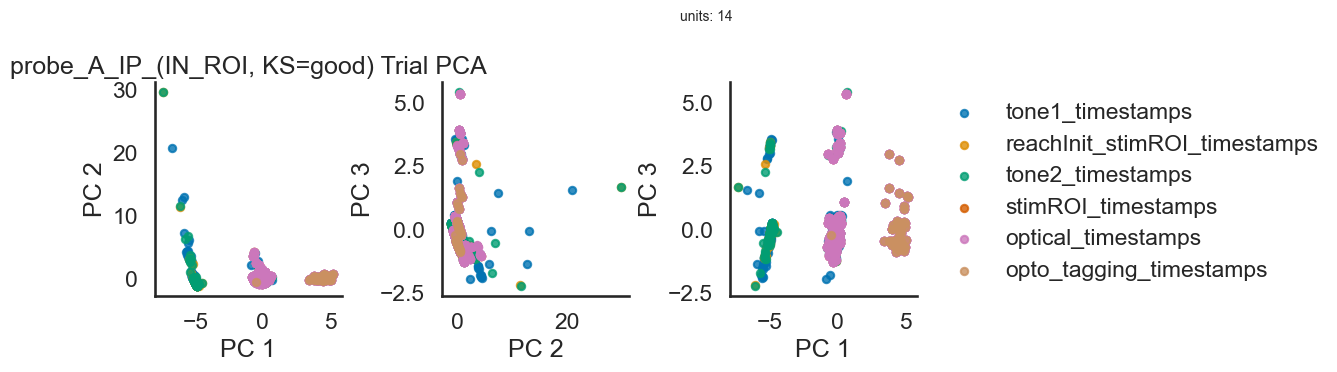

Trajectory PCA EVR first 5: [0.6971 0.0924 0.075  0.0604 0.0536]


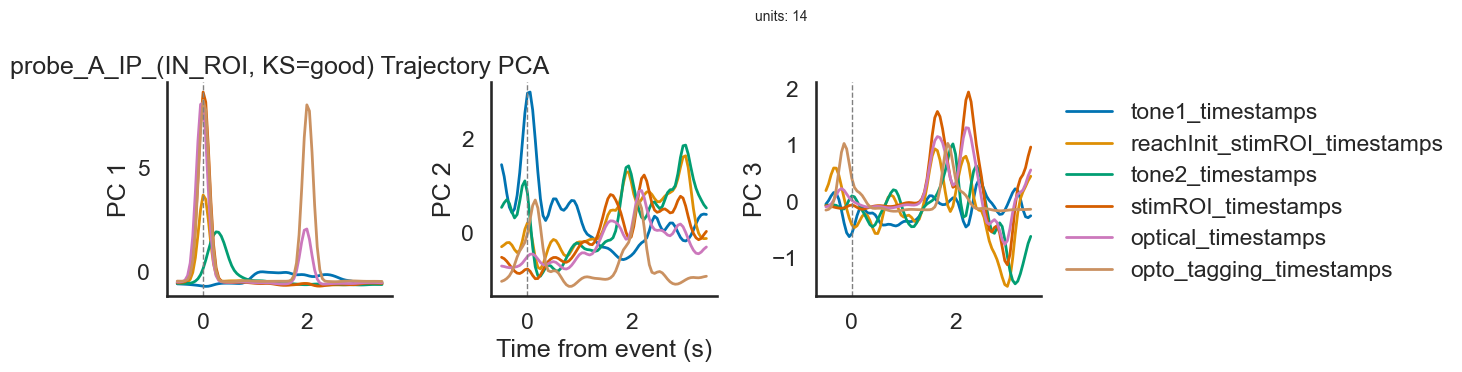

Requested tensor shape=(3006, 117, 80) est_mem=0.10 GB
Probe A | brain_region=SIM | ROI=IN_ROI | KS=good | units=117 | trials=3006
Trial PCA EVR first 5: [0.5405 0.0972 0.0506 0.0325 0.0201]


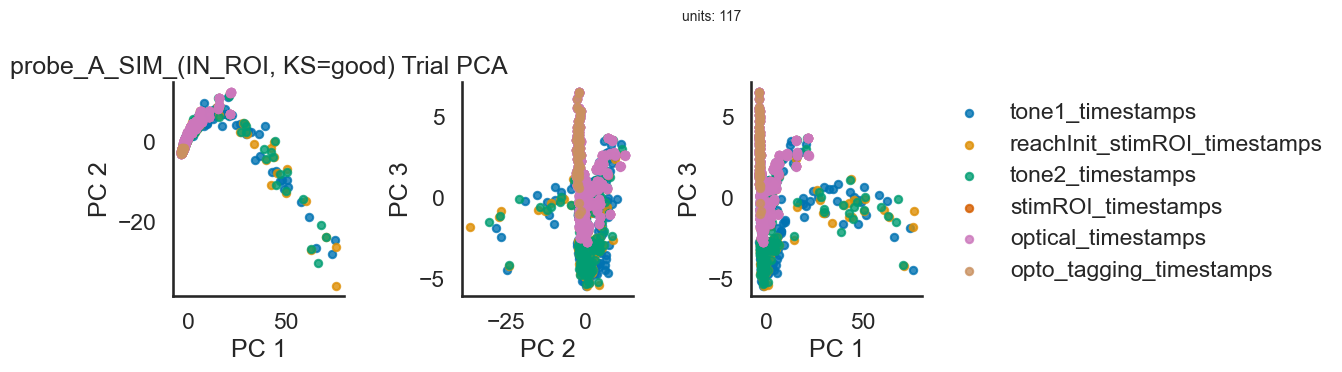

Trajectory PCA EVR first 5: [0.473  0.1536 0.0555 0.0446 0.0257]


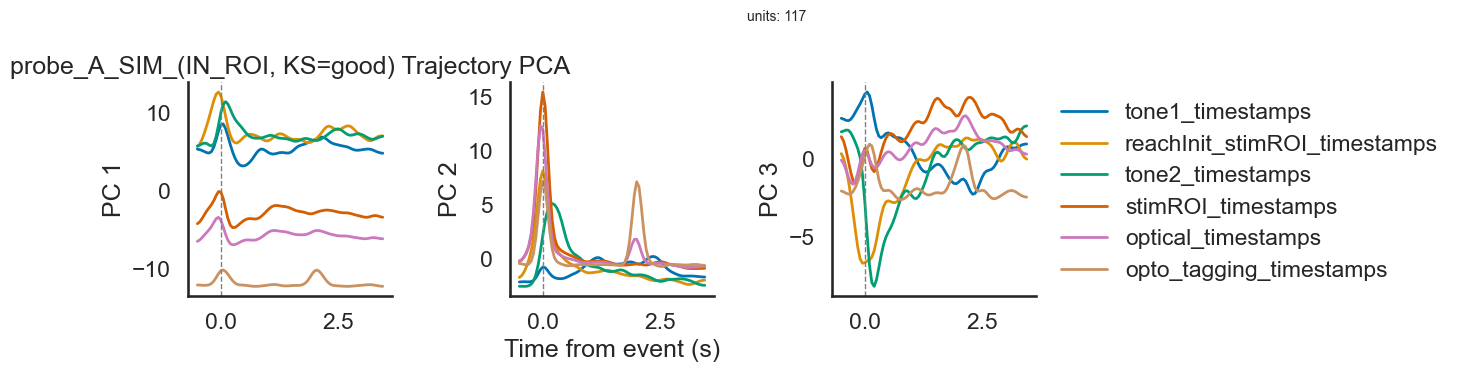

Requested tensor shape=(3006, 6, 80) est_mem=0.01 GB
Probe A | brain_region=unknown | ROI=IN_ROI | KS=good | units=6 | trials=3006
Trial PCA EVR first 5: [0.6726 0.1707 0.1435 0.0109 0.0015]


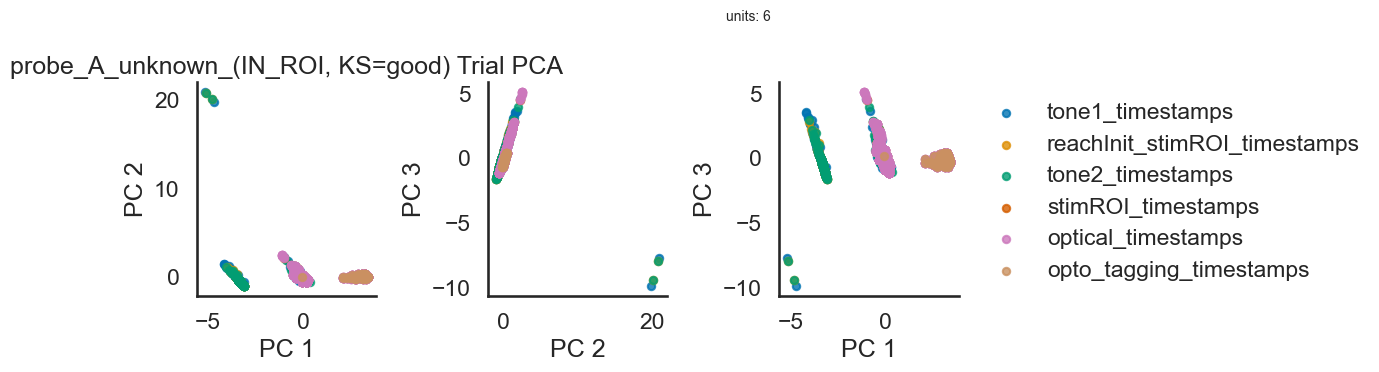

Trajectory PCA EVR first 5: [6.577e-01 1.719e-01 1.506e-01 1.950e-02 3.000e-04]


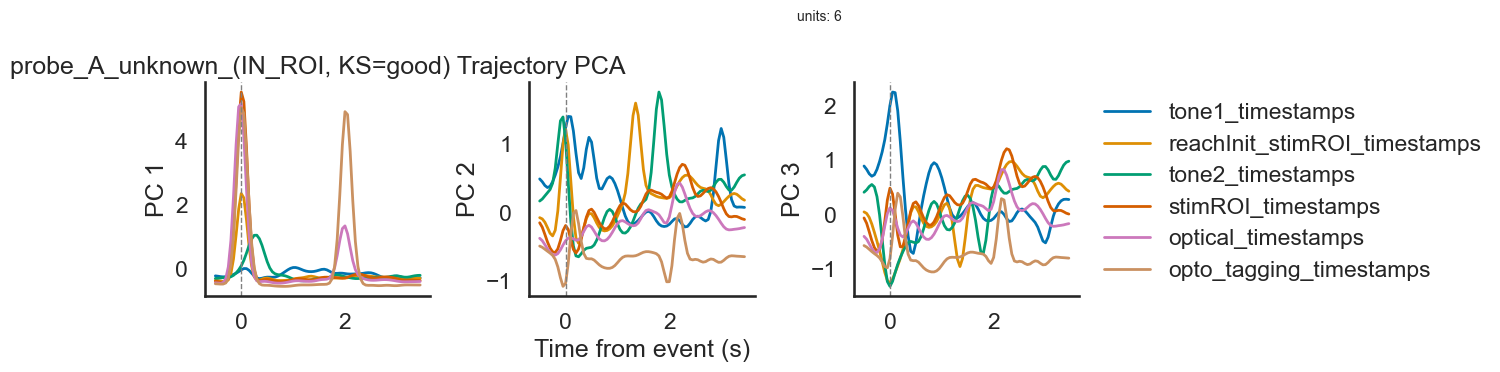

In [260]:
PCA_TARGET_PROBE = "A"
PCA_ROI_FILTER = "IN_ROI"
PCA_KSLABEL_FILTER = "good"

probe_units_all_df = pca_get_probe_units_df(
    merged_dic=merged_dic,
    probe=PCA_TARGET_PROBE,
    roi_filter=PCA_ROI_FILTER,
    kslabel_filter=PCA_KSLABEL_FILTER,
)

if probe_units_all_df.empty:
    raise ValueError(f"Probe {PCA_TARGET_PROBE}: no units after ROI/KS filters.")

if "brain_region" in probe_units_all_df.columns:
    _brain_regions = sorted(probe_units_all_df["brain_region"].map(_pca_norm_brain_region).unique().tolist())
else:
    _brain_regions = [None]

for _brain_region in _brain_regions:
    region_label = _pca_norm_brain_region(_brain_region) if _brain_region is not None else "all_regions"
    probe_units_df = pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=PCA_TARGET_PROBE,
        roi_filter=PCA_ROI_FILTER,
        kslabel_filter=PCA_KSLABEL_FILTER,
        brain_region_filter=_brain_region,
    )
    if probe_units_df.empty:
        print(f"Skipping probe {PCA_TARGET_PROBE} | brain_region={region_label}: no units")
        continue

    spike_times_list = [np.asarray(x, dtype=float) for x in probe_units_df["spike_times"].values]

    trials_probe, pca_time = pca_bin_spikes_around_events(
        spike_times_list=spike_times_list,
        event_times_s=pca_event_times,
        win_start_s=WINDOW_START_S,
        win_end_s=WINDOW_END_S,
        bin_size_s=BIN_SIZE_S,
        max_tensor_gb=PCA_MAX_TENSOR_GB,
    )

    print(
        f"Probe {PCA_TARGET_PROBE} | brain_region={region_label} | ROI={PCA_ROI_FILTER} "
        f"| KS={PCA_KSLABEL_FILTER} | units={len(spike_times_list)} | trials={trials_probe.shape[0]}"
    )

    Xp, evr_trial, trial_types, t_type_ind = pca_trial_level(trials_probe, pca_event_labels, n_components=N_COMPONENTS)
    print("Trial PCA EVR first 5:", np.round(evr_trial[:5], 4))
    pca_plot_trial_level(
        Xp,
        trial_types,
        t_type_ind,
        probe=PCA_TARGET_PROBE,
        brain_region=region_label,
        n_units=trials_probe.shape[1],
        title_prefix=f"probe_{PCA_TARGET_PROBE}_{region_label}_({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})",
        show_plots=True,
    )

    Xa_p, evr_traj, kept_labels = pca_trajectory(trials_probe, pca_event_labels, n_components=N_COMPONENTS)
    print("Trajectory PCA EVR first 5:", np.round(evr_traj[:5], 4))
    pca_plot_trajectory(
        Xa_p,
        kept_labels,
        n_bins=trials_probe.shape[2],
        time=pca_time,
        smooth_sigma=SMOOTH_SIGMA,
        probe=PCA_TARGET_PROBE,
        brain_region=region_label,
        n_units=trials_probe.shape[1],
        title_prefix=f"probe_{PCA_TARGET_PROBE}_{region_label}_({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})",
        show_plots=True,
    )


### Multi-Probe PCA Runs
Runs selected/all probes and stores results in `pca_results_by_probe`.


In [218]:
multiProbe_batch_run = True

In [116]:
if multiProbe_batch_run:
    if PCA_SELECTED_PROBES is None:
        probes_to_run = sorted(list(merged_dic.keys()))
    else:
        probes_to_run = [p for p in PCA_SELECTED_PROBES if p in merged_dic]

    pca_results_by_probe = {}

    for probe in probes_to_run:
        print("\n============================")
        print(f"Running probe {probe} | ROI={PCA_ROI_FILTER} | KS={PCA_KSLABEL_FILTER}")

        probe_units_all_df = pca_get_probe_units_df(
            merged_dic,
            probe=probe,
            roi_filter=PCA_ROI_FILTER,
            kslabel_filter=PCA_KSLABEL_FILTER,
        )
        if probe_units_all_df.empty:
            print(f"Skipping probe {probe}: no units after filtering.")
            continue

        if "brain_region" in probe_units_all_df.columns:
            brain_regions_to_run = sorted(probe_units_all_df["brain_region"].map(_pca_norm_brain_region).unique().tolist())
        else:
            brain_regions_to_run = [None]

        probe_region_results = {}
        for brain_region in brain_regions_to_run:
            region_label = _pca_norm_brain_region(brain_region) if brain_region is not None else "all_regions"
            print(f"  -> brain_region={region_label}")

            probe_units_df = pca_get_probe_units_df(
                merged_dic,
                probe=probe,
                roi_filter=PCA_ROI_FILTER,
                kslabel_filter=PCA_KSLABEL_FILTER,
                brain_region_filter=brain_region,
            )
            if probe_units_df.empty:
                print(f"     Skipping region {region_label}: no units.")
                continue

            spike_times_list = [np.asarray(x, dtype=float) for x in probe_units_df["spike_times"].values]

            try:
                trials_probe, pca_time = pca_bin_spikes_around_events(
                    spike_times_list=spike_times_list,
                    event_times_s=pca_event_times,
                    win_start_s=WINDOW_START_S,
                    win_end_s=WINDOW_END_S,
                    bin_size_s=BIN_SIZE_S,
                    max_tensor_gb=PCA_MAX_TENSOR_GB,
                )
            except MemoryError as e:
                print(f"     Skipping probe {probe} region {region_label} due to memory guard: {e}")
                continue

            Xp, evr_trial, trial_types, t_type_ind = pca_trial_level(trials_probe, pca_event_labels, n_components=N_COMPONENTS)
            Xa_p, evr_traj, kept_labels = pca_trajectory(trials_probe, pca_event_labels, n_components=N_COMPONENTS)

            probe_region_results[region_label] = {
                "units_df": probe_units_df,
                "trials": trials_probe,
                "time": pca_time,
                "trial_scores": Xp,
                "trial_evr": evr_trial,
                "trial_types": trial_types,
                "trial_type_ind": t_type_ind,
                "traj_scores": Xa_p,
                "traj_evr": evr_traj,
                "traj_labels": kept_labels,
                "brain_region": region_label,
            }

            print(f"     units={trials_probe.shape[1]}, trials={trials_probe.shape[0]}")
            print("     Trial EVR first 3:", np.round(evr_trial[:3], 4), "| Traj EVR first 3:", np.round(evr_traj[:3], 4))

        if len(probe_region_results) > 0:
            pca_results_by_probe[probe] = probe_region_results

    print("\nCompleted probes:", list(pca_results_by_probe.keys()))
else:
    print("Multi-probe batch run is disabled. Set multiProbe_batch_run=True to enable.")



Running probe A | ROI=IN_ROI | KS=good
  -> brain_region=IP
Requested tensor shape=(3006, 14, 80) est_mem=0.01 GB
     units=14, trials=3006
     Trial EVR first 3: [0.6324 0.1067 0.0749] | Traj EVR first 3: [0.6971 0.0924 0.075 ]
  -> brain_region=SIM
Requested tensor shape=(3006, 117, 80) est_mem=0.10 GB
     units=117, trials=3006
     Trial EVR first 3: [0.5405 0.0972 0.0506] | Traj EVR first 3: [0.473  0.1536 0.0555]
  -> brain_region=unknown
Requested tensor shape=(3006, 6, 80) est_mem=0.01 GB
     units=6, trials=3006
     Trial EVR first 3: [0.6726 0.1707 0.1435] | Traj EVR first 3: [0.6577 0.1719 0.1506]

Running probe B | ROI=IN_ROI | KS=good
  -> brain_region=PG
Requested tensor shape=(3006, 124, 80) est_mem=0.11 GB
     units=124, trials=3006
     Trial EVR first 3: [0.261  0.1381 0.1015] | Traj EVR first 3: [0.333  0.168  0.0866]

Running probe C | ROI=IN_ROI | KS=good
  -> brain_region=MoP
Requested tensor shape=(3006, 158, 80) est_mem=0.14 GB
     units=158, trials=3006

### Batch run PCA on all probes with trajectory plots 
- saves out all Plots to PCA_plot_save_path with probe and ROI in filename

In [117]:
if multiProbe_batch_run:
    for probe in probes_to_run:
        PCA_PLOT_PROBE = probe

        if PCA_PLOT_PROBE not in pca_results_by_probe:
            print(f"Skipping {PCA_PLOT_PROBE}: no PCA results found.")
            continue

        for brain_region, res in pca_results_by_probe[PCA_PLOT_PROBE].items():
            pca_plot_trial_level(
                Xp=res["trial_scores"],
                trial_types=res["trial_types"],
                t_type_ind=res["trial_type_ind"],
                probe=PCA_PLOT_PROBE,
                brain_region=brain_region,
                n_units=res["trials"].shape[1],
                title_prefix=f"probe_{PCA_PLOT_PROBE}_{brain_region}_({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})",
                show_plots=False,
            )
            pca_plot_trajectory(
                Xa_p=res["traj_scores"],
                kept_labels=res["traj_labels"],
                n_bins=res["trials"].shape[2],
                time=res["time"],
                smooth_sigma=SMOOTH_SIGMA,
                probe=PCA_PLOT_PROBE,
                brain_region=brain_region,
                n_units=res["trials"].shape[1],
                title_prefix=f"probe_{PCA_PLOT_PROBE}_{brain_region}_({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})",
                show_plots=False,
            )
else:
    print("Multi-probe batch plotting is disabled. Set multiProbe_batch_run=True to enable.")


PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel_trial\probe_A_IP_probe_A_IP_(IN_ROI,_KS=good).png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\pca_plot_trajectory\probe_A_IP_probe_A_IP_(IN_ROI,_KS=good)_trajectory.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel_trial\probe_A_SIM_probe_A_SIM_(IN_ROI,_KS=good).png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\pca_plot_trajectory\probe_A_SIM_probe_A_SIM_(IN_ROI,_KS=good)_trajectory.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel_trial\

### Plot Any Probe from Multi-Probe Results


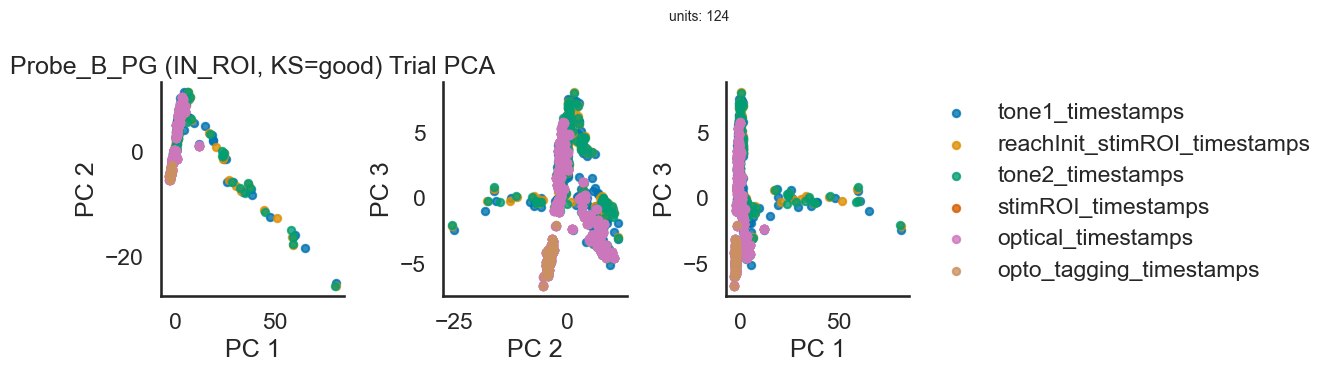

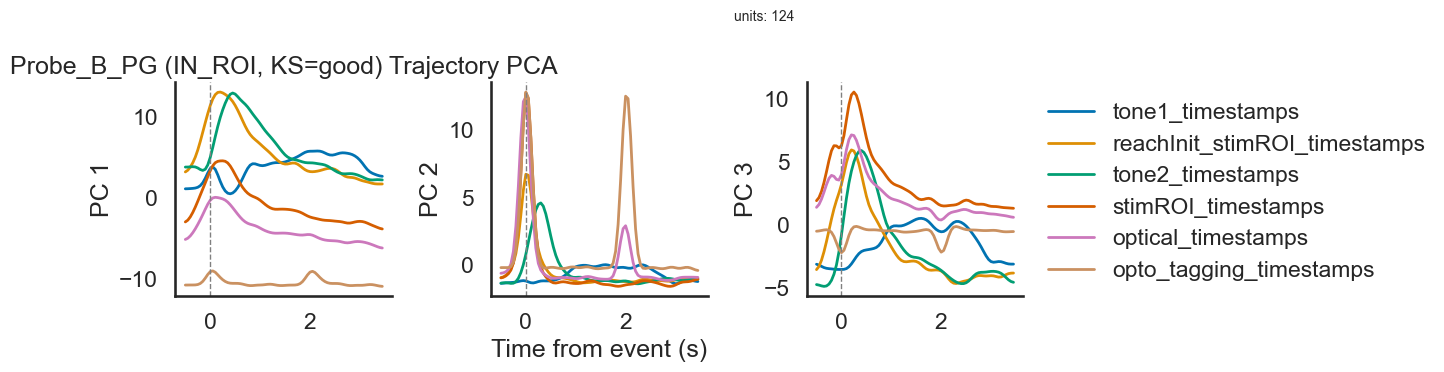

In [119]:
PCA_TARGET_PROBE = 'B'
PCA_TARGET_BRAIN_REGION = None  # None => all regions for this probe

if multiProbe_batch_run:
    PCA_PLOT_PROBE = PCA_TARGET_PROBE
    if PCA_PLOT_PROBE not in pca_results_by_probe:
        raise ValueError(f"{PCA_PLOT_PROBE} not in pca_results_by_probe. Available: {list(pca_results_by_probe.keys())}")

    available_regions = sorted(list(pca_results_by_probe[PCA_PLOT_PROBE].keys()))
    if PCA_TARGET_BRAIN_REGION is None:
        regions_to_plot = available_regions
    else:
        target_region = _pca_norm_brain_region(PCA_TARGET_BRAIN_REGION)
        if target_region not in available_regions:
            raise ValueError(f"{target_region} not available for probe {PCA_PLOT_PROBE}. Available: {available_regions}")
        regions_to_plot = [target_region]

    for brain_region in regions_to_plot:
        res = pca_results_by_probe[PCA_PLOT_PROBE][brain_region]
        pca_plot_trial_level(
            Xp=res["trial_scores"],
            trial_types=res["trial_types"],
            t_type_ind=res["trial_type_ind"],
            probe=PCA_PLOT_PROBE,
            brain_region=brain_region,
            n_units=res["trials"].shape[1],
            title_prefix=f"Probe_{PCA_PLOT_PROBE}_{brain_region} ({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})",
            show_plots=True,
        )
        pca_plot_trajectory(
            Xa_p=res["traj_scores"],
            kept_labels=res["traj_labels"],
            n_bins=res["trials"].shape[2],
            time=res["time"],
            smooth_sigma=SMOOTH_SIGMA,
            probe=PCA_PLOT_PROBE,
            brain_region=brain_region,
            n_units=res["trials"].shape[1],
            title_prefix=f"Probe_{PCA_PLOT_PROBE}_{brain_region} ({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})",
            show_plots=True,
        )
else:
    print("Multi-probe batch plotting is disabled. Set multiProbe_batch_run=True to enable.")


### Save PCA Summary


In [120]:
if multiProbe_batch_run:
    summary_rows = []
    for probe, region_dict in pca_results_by_probe.items():
        for brain_region, res in region_dict.items():
            summary_rows.append({
                "probe": probe,
                "brain_region": brain_region,
                "roi_filter": PCA_ROI_FILTER,
                "n_units": int(res["trials"].shape[1]),
                "n_events": int(res["trials"].shape[0]),
                "trial_evr_pc1": float(res["trial_evr"][0]) if len(res["trial_evr"]) else np.nan,
                "traj_evr_pc1": float(res["traj_evr"][0]) if len(res["traj_evr"]) else np.nan,
            })

    pca_summary_df = pd.DataFrame(summary_rows)
    pca_summary_path = OUT_DIR / f"all_in_one_probe_roi_pca_{PCA_ROI_FILTER if PCA_ROI_FILTER is not None else 'ALLROI'}.csv"
    pca_summary_df.to_csv(pca_summary_path, index=False)
    print("Saved:", pca_summary_path)
    save_path = root_PCA_plot_save_path / 'pca_summary'
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"pca_summary_{PCA_ROI_FILTER}.csv"
    pca_summary_df.to_csv(out, index=False)
    print(f"PCA summary saved to {out}")
    pca_summary_df
else:
    print("Multi-probe batch summary is disabled. Set multiProbe_batch_run=True to enable.")


Saved: c:\Users\user\Documents\github\PCA_on_neural_data\extra_files\all_in_one_probe_roi_pca_IN_ROI.csv
PCA summary saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\pca_summary\pca_summary_IN_ROI.csv


In [121]:
pca_summary_df

,probe,brain_region,roi_filter,n_units,n_events,trial_evr_pc1,traj_evr_pc1
0,A,IP,IN_ROI,14,3006,0.632405,0.697092
1,A,SIM,IN_ROI,117,3006,0.540486,0.473004
2,A,unknown,IN_ROI,6,3006,0.672605,0.657703
3,B,PG,IN_ROI,124,3006,0.260982,0.333033
4,C,MoP,IN_ROI,158,3006,0.239852,0.400495
5,D,VaL,IN_ROI,376,3006,0.236374,0.350603
6,E,SnR,IN_ROI,91,3006,0.223446,0.249577
7,F,RN,IN_ROI,59,3006,0.331826,0.459297


### Stimulus-Specific PCA Plotting

This section creates PCA plots where each stimulus is handled independently:
- one stimulus per figure (optional)
- all stimuli as subplots for one probe
- batch run across all probes with saving


In [122]:
# Stimulus-specific plotting config
STIM_PLOT_TIME_COL = PCA_EVENT_TIME_COL
STIM_PLOT_LABEL_COL = "stimulus" if "stimulus" in events_sel_df.columns else PCA_EVENT_FILTER_COL

STIM_PLOT_SINGLE_PROBE = "A"      # probe for single-probe run
STIM_PLOT_PROBES = None            # None => all probes from merged_dic
STIM_PLOT_ROI_FILTER = PCA_ROI_FILTER
STIM_PLOT_KSLABEL_FILTER = PCA_KSLABEL_FILTER

# brain_region controls
STIM_PLOT_SINGLE_BRAIN_REGION = None   # e.g. "VaL"; None => all regions in selected probe
STIM_PLOT_BATCH_BRAIN_REGIONS = None   # e.g. ["VaL", "SIM"]; None => all regions per probe

STIM_PLOT_MAX_EVENTS_PER_STIM = None  # optional cap per stimulus
STIM_PLOT_N_COMPONENTS = N_COMPONENTS
STIM_PLOT_SMOOTH_SIGMA = SMOOTH_SIGMA

# Plot style controls
STIM_PLOT_NCOLS = 3
STIM_PLOT_ONE_STIM_PER_FIG = True
STIM_PLOT_PANEL_PER_PROBE = True


In [123]:
def _sanitize_name(x: str) -> str:
    s = str(x)
    bad = ['\\', '/', ':', '*', '?', '"', '<', '>', '|']
    for b in bad:
        s = s.replace(b, '_')
    return s.strip().replace(' ', '_')


def pca_single_stim_trajectory(trials, n_components=12):
    """
    trials: (n_trials, n_units, n_bins) for one stimulus only
    Returns component trajectories over time for that stimulus.
    """
    Xa = trials.mean(axis=0)  # (n_units, n_bins)
    Xaz = zscore_rows(Xa)
    pca = PCA(n_components=min(n_components, Xaz.shape[0], Xaz.shape[1]))
    Xa_p = pca.fit_transform(Xaz.T).T  # (n_components, n_bins)
    return Xa_p, pca.explained_variance_ratio_


def get_stim_events(events_df, stim_label_col, stim_name, time_col, max_events_per_stim=None):
    stim_target = str(stim_name).strip().lower()
    stim_vals = events_df[stim_label_col].astype(str).str.strip().str.lower()
    sdf = events_df[stim_vals == stim_target].copy().reset_index(drop=True)
    if max_events_per_stim is not None and len(sdf) > max_events_per_stim:
        idx = np.linspace(0, len(sdf) - 1, max_events_per_stim, dtype=int)
        sdf = sdf.iloc[idx].reset_index(drop=True)
    times = pd.to_numeric(sdf[time_col], errors="coerce").dropna().to_numpy(dtype=float)
    return sdf, times


def plot_probe_stimulus_panel(probe,
                              merged_dic,
                              events_df,
                              stim_label_col,
                              time_col,
                              roi_filter=None,
                              kslabel_filter="both",
                              brain_region_filter=None,
                              n_components=12,
                              smooth_sigma=2,
                              max_tensor_gb=8.0,
                              max_events_per_stim=None,
                              ncols=3,
                              save_dir=None,
                              one_stim_per_fig=True,
                              panel_per_probe=True,
                              show_plots=True):
    probe_df = pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=probe,
        roi_filter=roi_filter,
        kslabel_filter=kslabel_filter,
        brain_region_filter=brain_region_filter,
    )
    if probe_df.empty:
        print(f"Probe {probe} | brain_region={brain_region_filter}: no units after ROI/KS/brain_region filters.")
        return None

    n_units = int(len(probe_df))
    region_label = _pca_norm_brain_region(brain_region_filter) if brain_region_filter is not None else "all_regions"

    spike_times_list = [np.asarray(x, dtype=float) for x in probe_df["spike_times"].values]
    stim_names = sorted(events_df[stim_label_col].astype(str).str.strip().unique().tolist())

    per_stim = []
    for stim_name in stim_names:
        sdf, stim_times = get_stim_events(
            events_df=events_df,
            stim_label_col=stim_label_col,
            stim_name=stim_name,
            time_col=time_col,
            max_events_per_stim=max_events_per_stim,
        )
        if len(stim_times) < 2:
            continue

        try:
            trials_stim, time = pca_bin_spikes_around_events(
                spike_times_list=spike_times_list,
                event_times_s=stim_times,
                win_start_s=WINDOW_START_S,
                win_end_s=WINDOW_END_S,
                bin_size_s=BIN_SIZE_S,
                max_tensor_gb=max_tensor_gb,
            )
        except MemoryError as e:
            print(f"Probe {probe} | brain_region={region_label} | stim {stim_name}: skipped due to memory guard: {e}")
            continue

        Xa_p, evr = pca_single_stim_trajectory(trials_stim, n_components=n_components)
        per_stim.append({
            "stim_name": stim_name,
            "n_events": len(stim_times),
            "time": time,
            "traj": Xa_p,
            "evr": evr,
            "brain_region": region_label,
            "n_units": n_units,
        })

    if len(per_stim) == 0:
        print(f"Probe {probe} | brain_region={region_label}: no stimulus groups to plot.")
        return None

    if panel_per_probe:
        n = len(per_stim)
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows), sharex=True)
        axes = np.array(axes).reshape(-1)

        for ax in axes[n:]:
            ax.axis('off')

        for i, rec in enumerate(per_stim):
            ax = axes[i]
            t = rec["time"]
            x1 = rec["traj"][0]
            x2 = rec["traj"][1] if rec["traj"].shape[0] > 1 else None
            x3 = rec["traj"][2] if rec["traj"].shape[0] > 2 else None
            if smooth_sigma and smooth_sigma > 0:
                x1 = gaussian_filter1d(x1, sigma=smooth_sigma)
                if x2 is not None: x2 = gaussian_filter1d(x2, sigma=smooth_sigma)
                if x3 is not None: x3 = gaussian_filter1d(x3, sigma=smooth_sigma)

            ax.plot(t, x1, lw=2, label='PC1')
            if x2 is not None: ax.plot(t, x2, lw=1.5, label='PC2')
            if x3 is not None: ax.plot(t, x3, lw=1.2, label='PC3')
            ax.axvline(0, color='gray', ls='--', lw=1)
            ax.set_title(f"{rec['stim_name']} (n={rec['n_events']})")
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('PC value')

        axes[0].legend(frameon=False)
        plt.suptitle(
            f"Probe {probe} | brain_region={region_label} | ROI={roi_filter} | KS={kslabel_filter}",
            y=1.02,
        )
        fig.text(0.5, 0.96, f"units: {n_units}", ha="center", va="center", fontsize=10)
        plt.tight_layout(rect=[0, 0, 1, 0.95])

        save_path = root_PCA_plot_save_path / 'stimulus_panel__byProbe'
        save_path.mkdir(parents=True, exist_ok=True)
        out = save_path / (
            f"probe_{_sanitize_name(probe)}_{_sanitize_name(region_label)}"
            f"_stimulus_panel_ROI_{_sanitize_name(roi_filter)}_KS_{_sanitize_name(kslabel_filter)}.png"
        )
        plt.savefig(out, dpi=250, bbox_inches='tight')
        print("Saved panel:", out)
        if show_plots:
            plt.show()
        else:
            plt.close()
            print(f"PCA plot saved to {out}")

    if one_stim_per_fig:
        for rec in per_stim:
            fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))
            t = rec["time"]
            x1 = rec["traj"][0]
            x2 = rec["traj"][1] if rec["traj"].shape[0] > 1 else None
            x3 = rec["traj"][2] if rec["traj"].shape[0] > 2 else None
            if smooth_sigma and smooth_sigma > 0:
                x1 = gaussian_filter1d(x1, sigma=smooth_sigma)
                if x2 is not None: x2 = gaussian_filter1d(x2, sigma=smooth_sigma)
                if x3 is not None: x3 = gaussian_filter1d(x3, sigma=smooth_sigma)

            ax.plot(t, x1, lw=2, label='PC1')
            if x2 is not None: ax.plot(t, x2, lw=1.5, label='PC2')
            if x3 is not None: ax.plot(t, x3, lw=1.2, label='PC3')
            ax.axvline(0, color='gray', ls='--', lw=1)
            ax.set_title(
                f"Probe {probe} | brain_region={region_label} | {rec['stim_name']} "
                f"(n={rec['n_events']}, units={n_units})"
            )
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('PC value')
            ax.legend(frameon=False)
            sns.despine()
            plt.tight_layout()
            subfolder = rec['stim_name']
            save_path = root_PCA_plot_save_path / 'stimulus_panel__byStim' / _sanitize_name(subfolder)
            save_path.mkdir(parents=True, exist_ok=True)
            out = save_path / (
                f"probe_{_sanitize_name(probe)}_{_sanitize_name(region_label)}"
                f"_stim_{_sanitize_name(rec['stim_name'])}_ROI_{_sanitize_name(roi_filter)}"
                f"_KS_{_sanitize_name(kslabel_filter)}.png"
            )
            plt.savefig(out, dpi=250, bbox_inches='tight')
            if show_plots:
                plt.show()
            else:
                plt.close()
                print(f"PCA plot saved to {out}")
    return per_stim


### Single-Probe Stimulus Batch Plot
Each stimulus gets its own subplot (and optional one-stimulus figures).


In [124]:
_single_probe_df = pca_get_probe_units_df(
    merged_dic=merged_dic,
    probe=STIM_PLOT_SINGLE_PROBE,
    roi_filter=STIM_PLOT_ROI_FILTER,
    kslabel_filter=STIM_PLOT_KSLABEL_FILTER,
)

if _single_probe_df.empty:
    raise ValueError(f"Probe {STIM_PLOT_SINGLE_PROBE}: no units after ROI/KS filters.")

if "brain_region" in _single_probe_df.columns:
    _single_regions_all = sorted(_single_probe_df["brain_region"].map(_pca_norm_brain_region).unique().tolist())
else:
    _single_regions_all = [None]

if STIM_PLOT_SINGLE_BRAIN_REGION is None:
    _single_regions = _single_regions_all
else:
    _single_regions = [_pca_norm_brain_region(STIM_PLOT_SINGLE_BRAIN_REGION)]

for _brain_region in _single_regions:
    region_label = _pca_norm_brain_region(_brain_region) if _brain_region is not None else "all_regions"
    print(f"Running stimulus panel for probe={STIM_PLOT_SINGLE_PROBE}, brain_region={region_label}")
    _ = plot_probe_stimulus_panel(
        probe=STIM_PLOT_SINGLE_PROBE,
        merged_dic=merged_dic,
        events_df=events_sel_df,
        stim_label_col=STIM_PLOT_LABEL_COL,
        time_col=STIM_PLOT_TIME_COL,
        roi_filter=STIM_PLOT_ROI_FILTER,
        kslabel_filter=STIM_PLOT_KSLABEL_FILTER,
        brain_region_filter=_brain_region,
        n_components=STIM_PLOT_N_COMPONENTS,
        smooth_sigma=STIM_PLOT_SMOOTH_SIGMA,
        max_tensor_gb=PCA_MAX_TENSOR_GB,
        max_events_per_stim=STIM_PLOT_MAX_EVENTS_PER_STIM,
        ncols=STIM_PLOT_NCOLS,
        one_stim_per_fig=STIM_PLOT_ONE_STIM_PER_FIG,
        panel_per_probe=STIM_PLOT_PANEL_PER_PROBE,
        show_plots=False,
    )


Running stimulus panel for probe=A, brain_region=IP
Requested tensor shape=(1900, 14, 80) est_mem=0.01 GB
Requested tensor shape=(60, 14, 80) est_mem=0.00 GB
Requested tensor shape=(270, 14, 80) est_mem=0.00 GB
Requested tensor shape=(130, 14, 80) est_mem=0.00 GB
Requested tensor shape=(376, 14, 80) est_mem=0.00 GB
Requested tensor shape=(270, 14, 80) est_mem=0.00 GB
Saved panel: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel__byProbe\probe_A_IP_stimulus_panel_ROI_IN_ROI_KS_good.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel__byProbe\probe_A_IP_stimulus_panel_ROI_IN_ROI_KS_good.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel__byStim\optical_timestamps\probe_A_IP_stim_optical_timest

### All-Probes Stimulus Batch Plot + Save
Runs the same stimulus-specific PCA plotting for every selected probe.


In [125]:
if STIM_PLOT_PROBES is None:
    _probes = sorted(list(merged_dic.keys()))
else:
    _probes = [p for p in STIM_PLOT_PROBES if p in merged_dic]

stim_plot_results = {}
for _probe in _probes:
    print("\n================================")
    print(f"Stimulus plotting for probe {_probe}")

    _probe_df = pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=_probe,
        roi_filter=STIM_PLOT_ROI_FILTER,
        kslabel_filter=STIM_PLOT_KSLABEL_FILTER,
    )
    if _probe_df.empty:
        print(f"Skipping probe {_probe}: no units after filters.")
        continue

    if "brain_region" in _probe_df.columns:
        _regions_all = sorted(_probe_df["brain_region"].map(_pca_norm_brain_region).unique().tolist())
    else:
        _regions_all = [None]

    if STIM_PLOT_BATCH_BRAIN_REGIONS is None:
        _regions = _regions_all
    else:
        _regions = [
            _pca_norm_brain_region(x)
            for x in STIM_PLOT_BATCH_BRAIN_REGIONS
            if _pca_norm_brain_region(x) in _regions_all
        ]

    stim_plot_results[_probe] = {}
    for _brain_region in _regions:
        region_label = _pca_norm_brain_region(_brain_region) if _brain_region is not None else "all_regions"
        print(f"  -> brain_region={region_label}")
        recs = plot_probe_stimulus_panel(
            probe=_probe,
            merged_dic=merged_dic,
            events_df=events_sel_df,
            stim_label_col=STIM_PLOT_LABEL_COL,
            time_col=STIM_PLOT_TIME_COL,
            roi_filter=STIM_PLOT_ROI_FILTER,
            kslabel_filter=STIM_PLOT_KSLABEL_FILTER,
            brain_region_filter=_brain_region,
            n_components=STIM_PLOT_N_COMPONENTS,
            smooth_sigma=STIM_PLOT_SMOOTH_SIGMA,
            max_tensor_gb=PCA_MAX_TENSOR_GB,
            max_events_per_stim=STIM_PLOT_MAX_EVENTS_PER_STIM,
            ncols=STIM_PLOT_NCOLS,
            one_stim_per_fig=STIM_PLOT_ONE_STIM_PER_FIG,
            panel_per_probe=STIM_PLOT_PANEL_PER_PROBE,
            show_plots=False,
        )
        stim_plot_results[_probe][region_label] = recs

print("\nCompleted stimulus plotting for probes:", list(stim_plot_results.keys()))



Stimulus plotting for probe A
  -> brain_region=IP
Requested tensor shape=(1900, 14, 80) est_mem=0.01 GB
Requested tensor shape=(60, 14, 80) est_mem=0.00 GB
Requested tensor shape=(270, 14, 80) est_mem=0.00 GB
Requested tensor shape=(130, 14, 80) est_mem=0.00 GB
Requested tensor shape=(376, 14, 80) est_mem=0.00 GB
Requested tensor shape=(270, 14, 80) est_mem=0.00 GB
Saved panel: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel__byProbe\probe_A_IP_stimulus_panel_ROI_IN_ROI_KS_good.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel__byProbe\probe_A_IP_stimulus_panel_ROI_IN_ROI_KS_good.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel__byStim\optical_timestamps\probe_A_IP_stim_optical_timest

### Selected Stimuli Overlay Plot (Together on One Plot)

Use this section when you want specific stimuli (e.g. `reachInit_stimROI_timestamps` and `stim_ROI_timestamps`) plotted together in one figure.


In [127]:
stim_df
# uniwue stimulus types
pd.unique(stim_df.stimulus.astype(str).str.strip().str.lower())
# count of each stimulus type
stim_df.stimulus.astype(str).str.strip().str.lower().value_counts()


stimulus
optical_timestamps              1900
tone1_timestamps                 376
reachinit_stimroi_timestamps     270
tone2_timestamps                 270
stimroi_timestamps               130
opto_tagging_timestamps           60
Name: count, dtype: int64

In [ ]:
# Stimulus overlay config
OVERLAY_STIMULI = ["opto_closed_loop_start_timestamps", "opto_tag_start_timestamps"]
# Examples:
OVERLAY_STIMULI = ["reachInit_stimROI_timestamps", "stimroi_timestamps"]
OVERLAY_STIMULI = ["stimROI_timestamps", "opto_tagging_timestamps"]

OVERLAY_SINGLE_PROBE = "A"
OVERLAY_PROBES = None            # None => all probes
OVERLAY_ROI_FILTER = STIM_PLOT_ROI_FILTER
OVERLAY_KSLABEL_FILTER = STIM_PLOT_KSLABEL_FILTER

# brain_region controls
OVERLAY_SINGLE_BRAIN_REGION = None   # e.g. "VaL"; None => all regions in OVERLAY_SINGLE_PROBE
OVERLAY_BATCH_BRAIN_REGIONS = None   # e.g. ["VaL", "SIM"]; None => all regions per probe

OVERLAY_MAX_EVENTS_PER_STIM = STIM_PLOT_MAX_EVENTS_PER_STIM
OVERLAY_SMOOTH_SIGMA = STIM_PLOT_SMOOTH_SIGMA
OVERLAY_N_COMPONENTS = STIM_PLOT_N_COMPONENTS

# Optional: append custom numpy timestamp arrays as overlay events
OVERLAY_INCLUDE_CUSTOM_ARRAYS = True
OVERLAY_CUSTOM_EVENT_ARRAYS = {
    "opto_closed_loop_start_timestamps": globals().get("opto_closed_loop_start_timestamps", None),
    "opto_tag_start_timestamps": globals().get("opto_tag_start_timestamps", None),
}

# Build overlay event table used by plotting cells
OVERLAY_EVENTS_DF = events_sel_df.copy()

if STIM_PLOT_LABEL_COL not in OVERLAY_EVENTS_DF.columns and "stimulus" in OVERLAY_EVENTS_DF.columns:
    OVERLAY_EVENTS_DF[STIM_PLOT_LABEL_COL] = OVERLAY_EVENTS_DF["stimulus"].astype(str)

_overlay_custom_rows = []
OVERLAY_CUSTOM_STIMULI_ADDED = []
if OVERLAY_INCLUDE_CUSTOM_ARRAYS:
    for _label, _arr in OVERLAY_CUSTOM_EVENT_ARRAYS.items():
        if _arr is None:
            continue
        _vals = np.asarray(_arr, dtype=float).ravel()
        _vals = _vals[np.isfinite(_vals)]
        if _vals.size == 0:
            continue
        _overlay_custom_rows.append(pd.DataFrame({
            STIM_PLOT_LABEL_COL: [_label] * len(_vals),
            STIM_PLOT_TIME_COL: _vals,
        }))
        OVERLAY_CUSTOM_STIMULI_ADDED.append(_label)

if len(_overlay_custom_rows) > 0:
    OVERLAY_EVENTS_DF = pd.concat([OVERLAY_EVENTS_DF] + _overlay_custom_rows, ignore_index=True, sort=False)

OVERLAY_EVENTS_DF[STIM_PLOT_TIME_COL] = pd.to_numeric(OVERLAY_EVENTS_DF[STIM_PLOT_TIME_COL], errors="coerce")
OVERLAY_EVENTS_DF = OVERLAY_EVENTS_DF.dropna(subset=[STIM_PLOT_TIME_COL]).sort_values(STIM_PLOT_TIME_COL).reset_index(drop=True)

print("Overlay custom stimuli added:", OVERLAY_CUSTOM_STIMULI_ADDED)


Overlay custom stimuli added: ['opto_closed_loop_start_timestamps', 'opto_tag_start_timestamps']


In [129]:
def plot_probe_selected_stimuli_overlay(probe,
                                        merged_dic,
                                        events_df,
                                        selected_stimuli,
                                        stim_label_col,
                                        time_col,
                                        roi_filter=None,
                                        kslabel_filter="both",
                                        brain_region_filter=None,
                                        n_components=12,
                                        smooth_sigma=2,
                                        max_tensor_gb=8.0,
                                        max_events_per_stim=None,
                                        save_dir=None,
                                        show_plots=True):
    probe_df = pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=probe,
        roi_filter=roi_filter,
        kslabel_filter=kslabel_filter,
        brain_region_filter=brain_region_filter,
    )
    if probe_df.empty:
        print(f"Probe {probe} | brain_region={brain_region_filter}: no units after ROI/KS/brain_region filters.")
        return None

    n_units = int(len(probe_df))
    region_label = _pca_norm_brain_region(brain_region_filter) if brain_region_filter is not None else "all_regions"
    spike_times_list = [np.asarray(x, dtype=float) for x in probe_df["spike_times"].values]

    recs = []
    stim_values_norm = events_df[stim_label_col].astype(str).str.strip().str.lower().unique()
    for stim_name in selected_stimuli:
        if str(stim_name).strip().lower() not in stim_values_norm:
            print(f"Probe {probe} | region={region_label} | {stim_name}: skipped (not found in events)")
            continue
        sdf, stim_times = get_stim_events(
            events_df=events_df,
            stim_label_col=stim_label_col,
            stim_name=stim_name,
            time_col=time_col,
            max_events_per_stim=max_events_per_stim,
        )
        if len(stim_times) < 2:
            print(f"Probe {probe} | region={region_label} | {stim_name}: skipped (<2 events)")
            continue

        try:
            trials_stim, t = pca_bin_spikes_around_events(
                spike_times_list=spike_times_list,
                event_times_s=stim_times,
                win_start_s=WINDOW_START_S,
                win_end_s=WINDOW_END_S,
                bin_size_s=BIN_SIZE_S,
                max_tensor_gb=max_tensor_gb,
            )
        except MemoryError as e:
            print(f"Probe {probe} | region={region_label} | {stim_name}: skipped due to memory guard: {e}")
            continue

        traj, evr = pca_single_stim_trajectory(trials_stim, n_components=n_components)
        recs.append({
            "stim": stim_name,
            "n": len(stim_times),
            "time": t,
            "traj": traj,
            "evr": evr,
        })

    if len(recs) == 0:
        print(f"Probe {probe} | region={region_label}: no selected stimuli were plottable.")
        return None

    pal = sns.color_palette("colorblind", len(recs))
    fig, axes = plt.subplots(1, 3, figsize=(20, 3.8), sharex=True)

    for k, rec in enumerate(recs):
        x1 = rec["traj"][0]
        x2 = rec["traj"][1] if rec["traj"].shape[0] > 1 else None
        x3 = rec["traj"][2] if rec["traj"].shape[0] > 2 else None
        tt = rec["time"]

        if smooth_sigma and smooth_sigma > 0:
            x1 = gaussian_filter1d(x1, sigma=smooth_sigma)
            if x2 is not None: x2 = gaussian_filter1d(x2, sigma=smooth_sigma)
            if x3 is not None: x3 = gaussian_filter1d(x3, sigma=smooth_sigma)

        axes[0].plot(tt, x1, lw=2, color=pal[k], label=f"{rec['stim']} (n={rec['n']})")
        if x2 is not None:
            axes[1].plot(tt, x2, lw=2, color=pal[k], label=f"{rec['stim']} (n={rec['n']})")
        if x3 is not None:
            axes[2].plot(tt, x3, lw=2, color=pal[k], label=f"{rec['stim']} (n={rec['n']})")

    for c, ax in enumerate(axes, start=1):
        ax.axvline(0, color='gray', ls='--', lw=1)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(f'PC{c}')

    axes[0].set_xlim(WINDOW_START_S, WINDOW_END_S)

    plt.subplots_adjust(left=0.22)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(0.02, 0.5),
        frameon=True,
    )

    plt.suptitle(
        f"Probe {probe} | brain_region={region_label} | ROI={roi_filter} | KS={kslabel_filter} | "
        f"Selected stimuli overlay={selected_stimuli}",
        y=0.98,
    )
    fig.text(0.5, 0.93, f"units: {n_units}", ha="center", va="center", fontsize=10)
    sns.despine()

    plt.tight_layout(rect=(0.275, 0, 1, 0.9))

    stim_tag = "__".join([_sanitize_name(s) for s in selected_stimuli])
    save_path = root_PCA_plot_save_path / 'stimulus_panel_overlay' / stim_tag
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / (
        f"probe_{_sanitize_name(probe)}_{_sanitize_name(region_label)}"
        f"_ROI_{_sanitize_name(roi_filter)}_KS_{_sanitize_name(kslabel_filter)}.png"
    )
    plt.savefig(out, dpi=250, bbox_inches='tight')
    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")
    return recs


### Sinlge plot for one probe and selected stimuli

In [130]:
# list of all stimuli in the stim_df
stimuli_list = stim_df["stimulus"].astype(str).unique().tolist()
print("Unique stimuli in stim_df:", stimuli_list)

Unique stimuli in stim_df: ['tone1_timestamps', 'reachInit_stimROI_timestamps', 'tone2_timestamps', 'stimROI_timestamps', 'optical_timestamps', 'opto_tagging_timestamps']


In [131]:
print(f"opto_closed_loop_start_timestamps: {len(opto_closed_loop_start_timestamps)}")
print(f"opto_tag_start_timestamps: {len(opto_tag_start_timestamps)}")

opto_closed_loop_start_timestamps: 1300
opto_tag_start_timestamps: 600


Running overlay for probe=A, brain_region=IP, stimuli=['opto_closed_loop_start_timestamps', 'opto_tag_start_timestamps']
Requested tensor shape=(1300, 14, 80) est_mem=0.01 GB
Requested tensor shape=(600, 14, 80) est_mem=0.00 GB


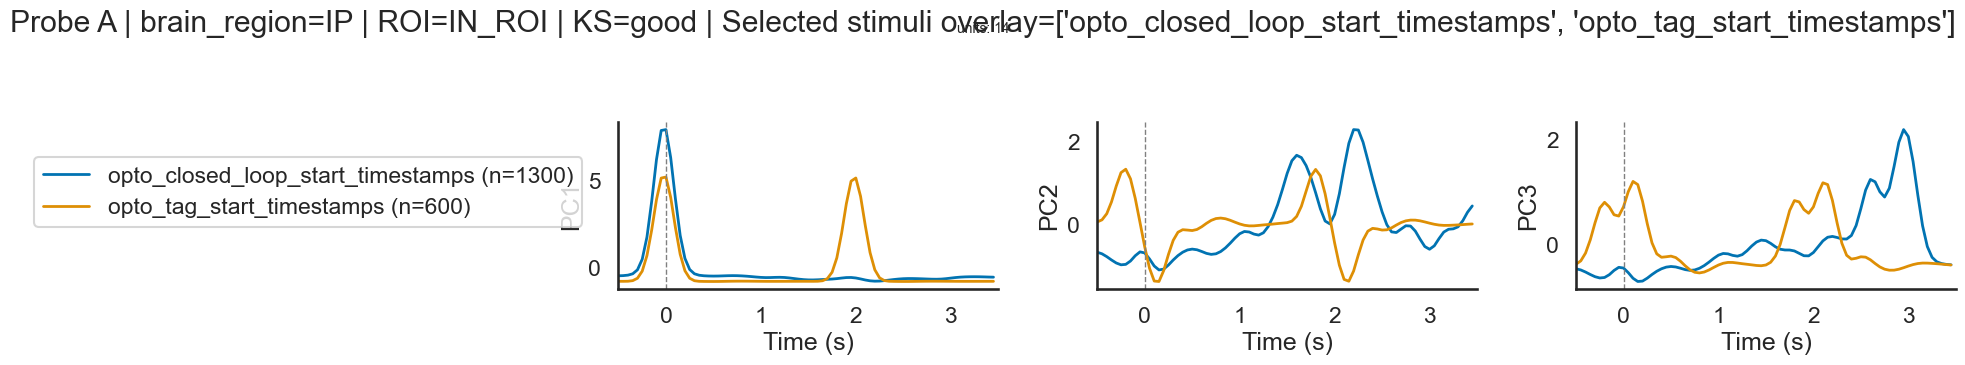

Running overlay for probe=A, brain_region=SIM, stimuli=['opto_closed_loop_start_timestamps', 'opto_tag_start_timestamps']
Requested tensor shape=(1300, 117, 80) est_mem=0.05 GB
Requested tensor shape=(600, 117, 80) est_mem=0.02 GB


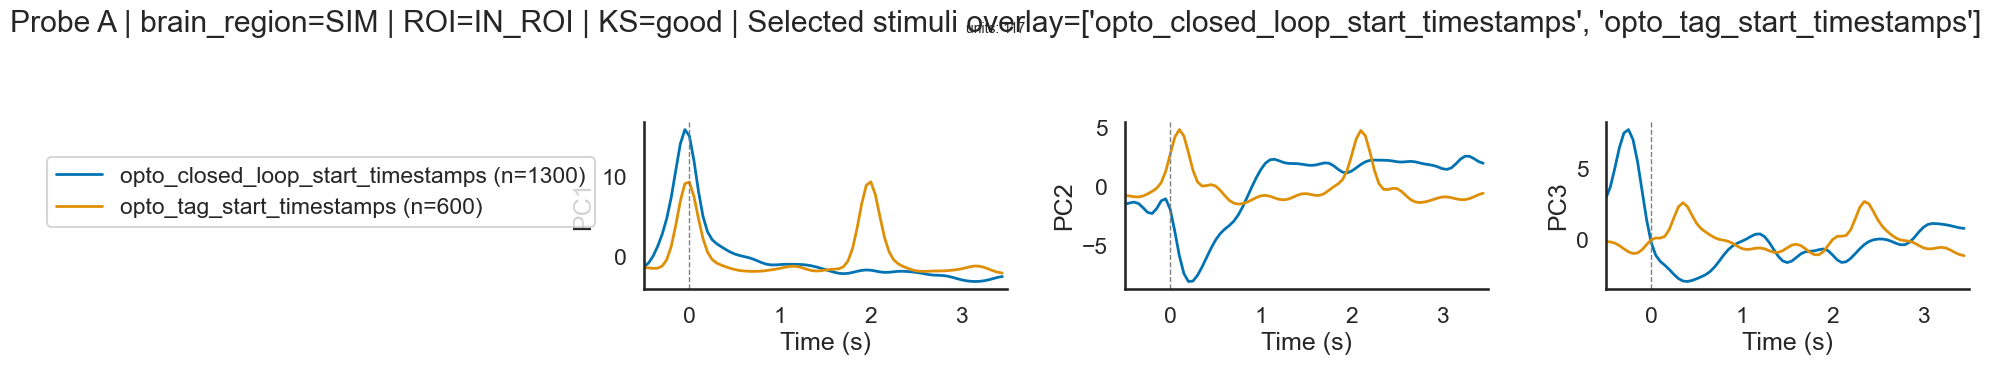

Running overlay for probe=A, brain_region=unknown, stimuli=['opto_closed_loop_start_timestamps', 'opto_tag_start_timestamps']
Requested tensor shape=(1300, 6, 80) est_mem=0.00 GB
Requested tensor shape=(600, 6, 80) est_mem=0.00 GB


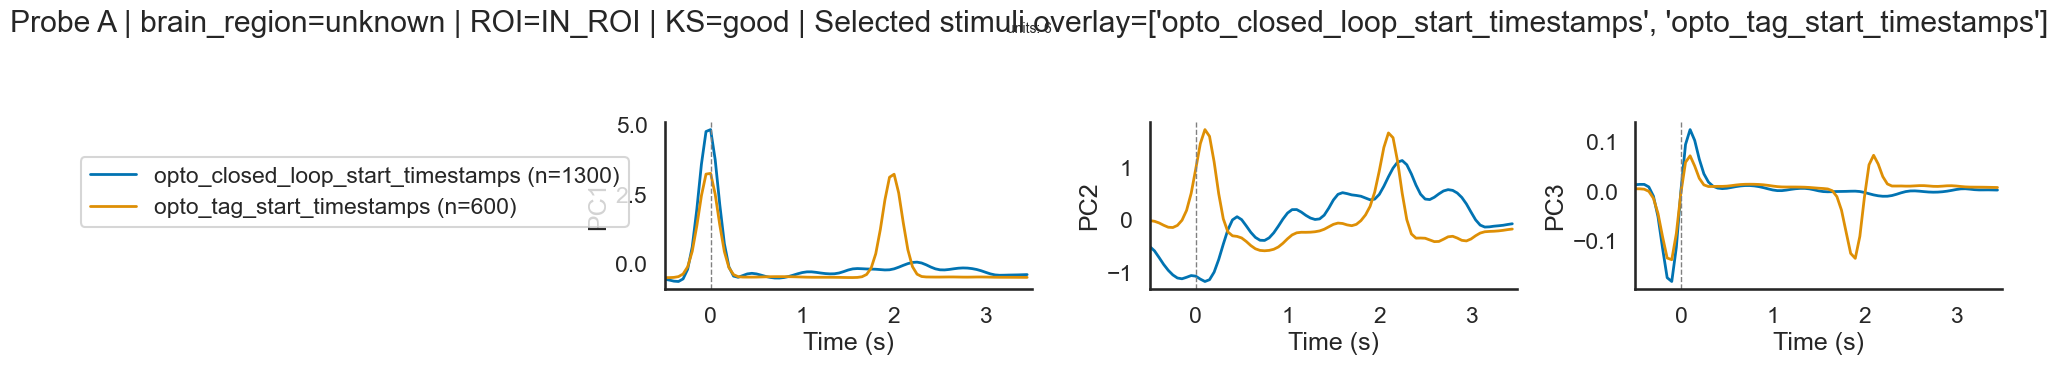

Running overlay for probe=A, brain_region=IP, stimuli=['opto_closed_loop_start_timestamps', 'opto_tag_start_timestamps']
Requested tensor shape=(1300, 14, 80) est_mem=0.01 GB
Requested tensor shape=(600, 14, 80) est_mem=0.00 GB


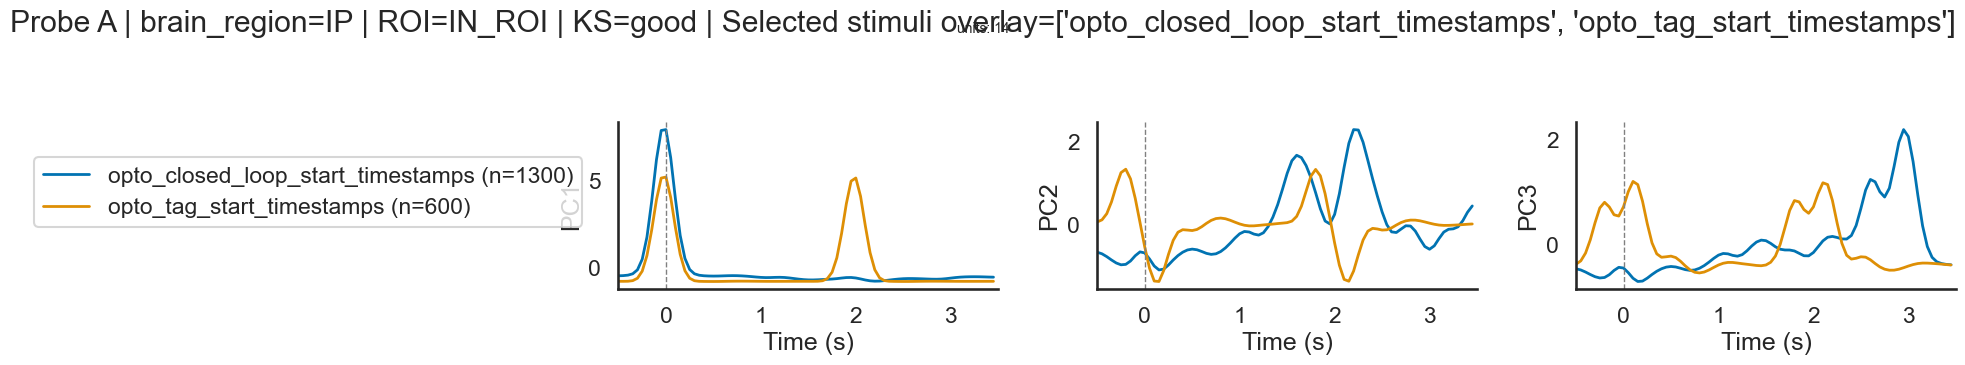

Running overlay for probe=A, brain_region=SIM, stimuli=['opto_closed_loop_start_timestamps', 'opto_tag_start_timestamps']
Requested tensor shape=(1300, 117, 80) est_mem=0.05 GB
Requested tensor shape=(600, 117, 80) est_mem=0.02 GB


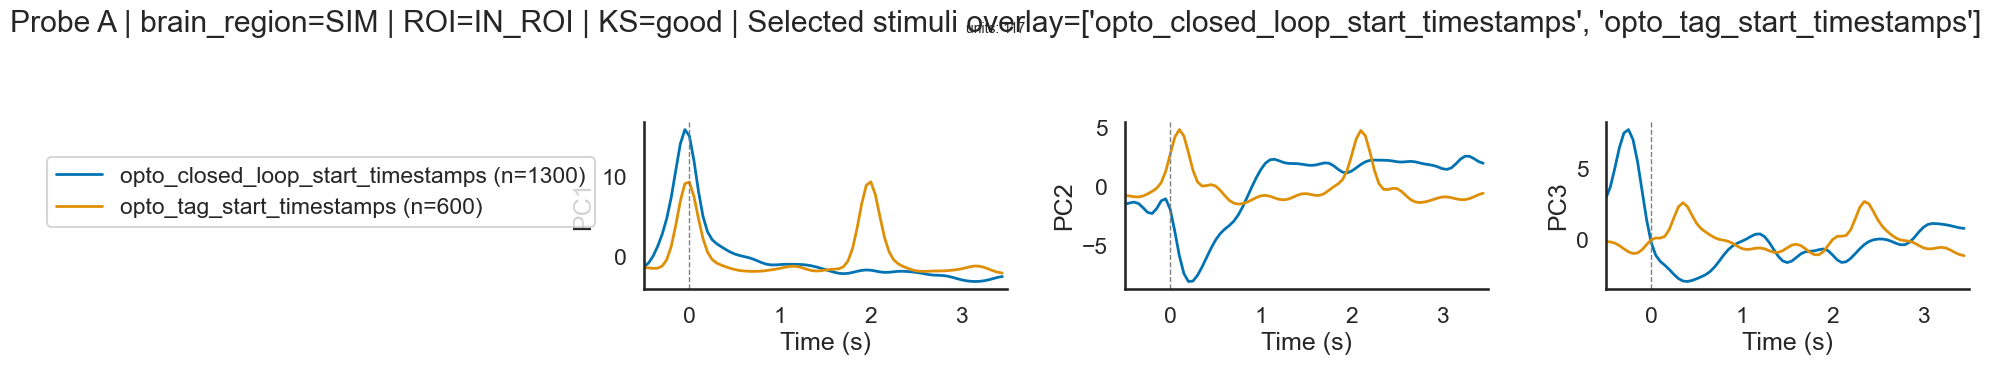

Running overlay for probe=A, brain_region=unknown, stimuli=['opto_closed_loop_start_timestamps', 'opto_tag_start_timestamps']
Requested tensor shape=(1300, 6, 80) est_mem=0.00 GB
Requested tensor shape=(600, 6, 80) est_mem=0.00 GB


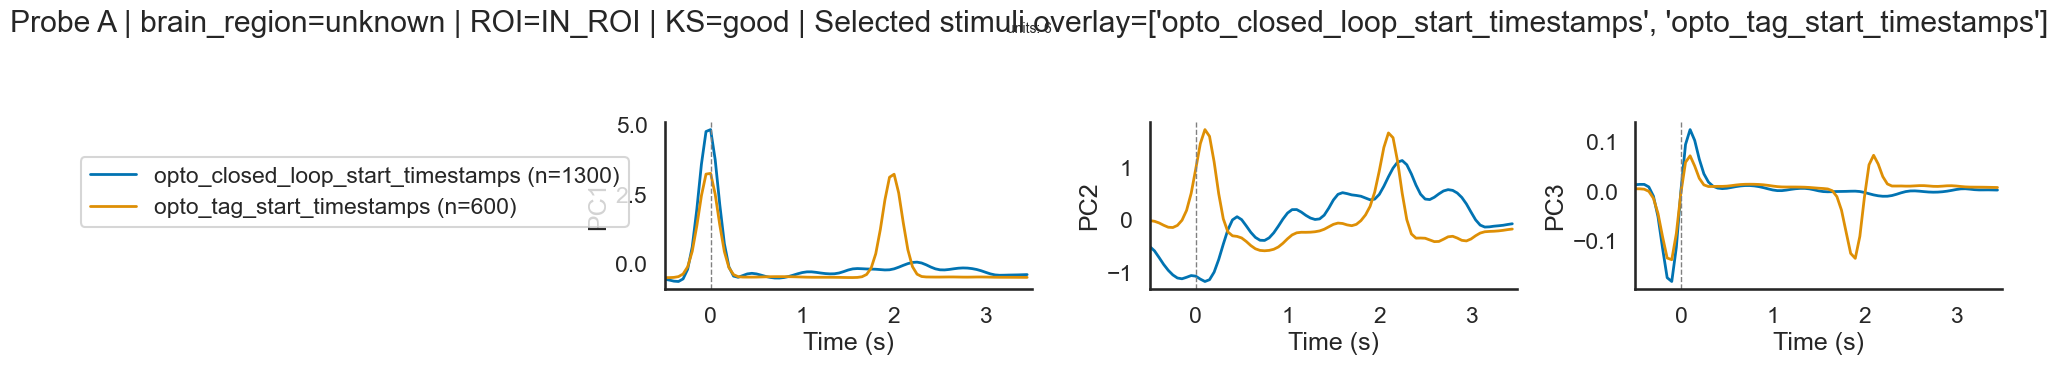

Running overlay for probe=A, brain_region=IP, stimuli=['tone1_timestamps', 'tone2_timestamps']
Requested tensor shape=(376, 14, 80) est_mem=0.00 GB
Requested tensor shape=(270, 14, 80) est_mem=0.00 GB


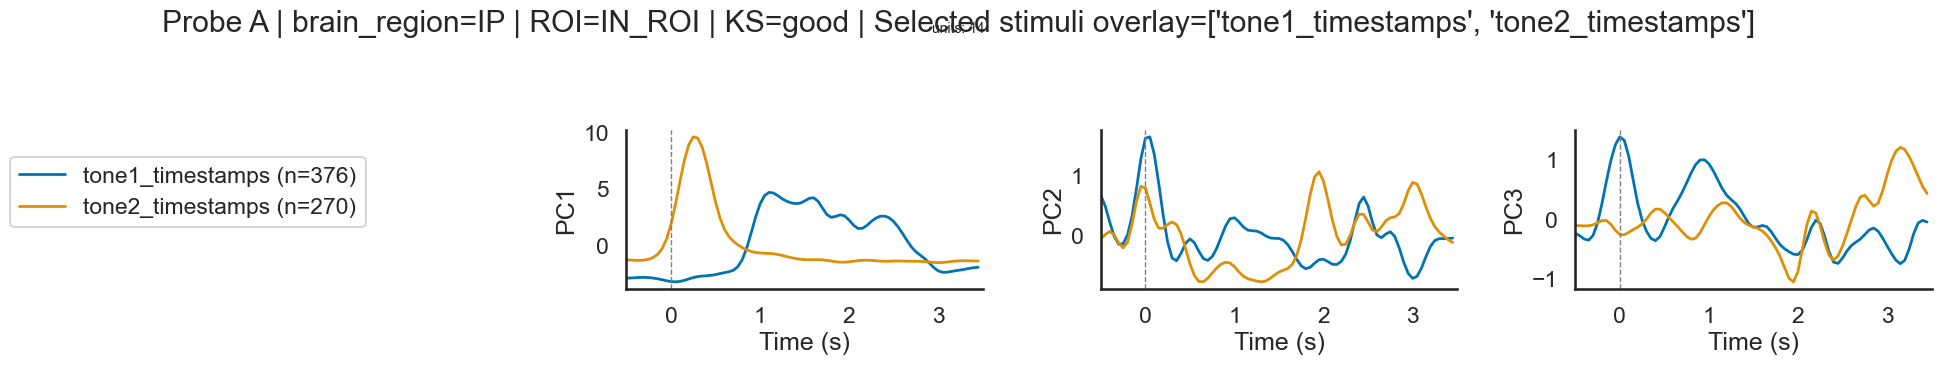

Running overlay for probe=A, brain_region=SIM, stimuli=['tone1_timestamps', 'tone2_timestamps']
Requested tensor shape=(376, 117, 80) est_mem=0.01 GB
Requested tensor shape=(270, 117, 80) est_mem=0.01 GB


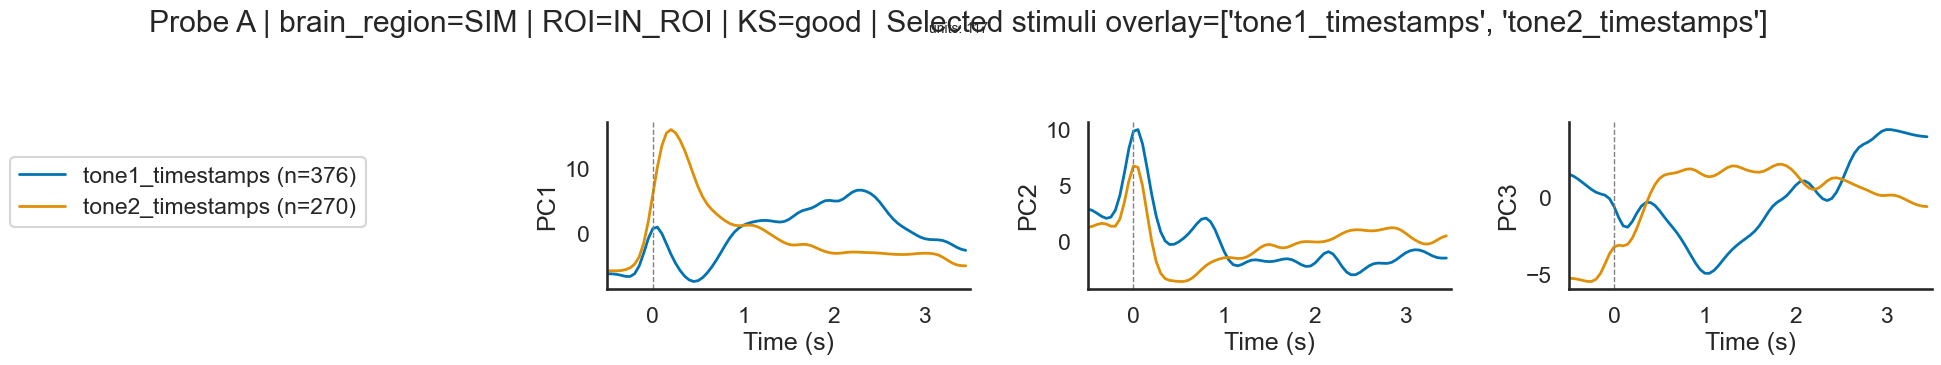

Running overlay for probe=A, brain_region=unknown, stimuli=['tone1_timestamps', 'tone2_timestamps']
Requested tensor shape=(376, 6, 80) est_mem=0.00 GB
Requested tensor shape=(270, 6, 80) est_mem=0.00 GB


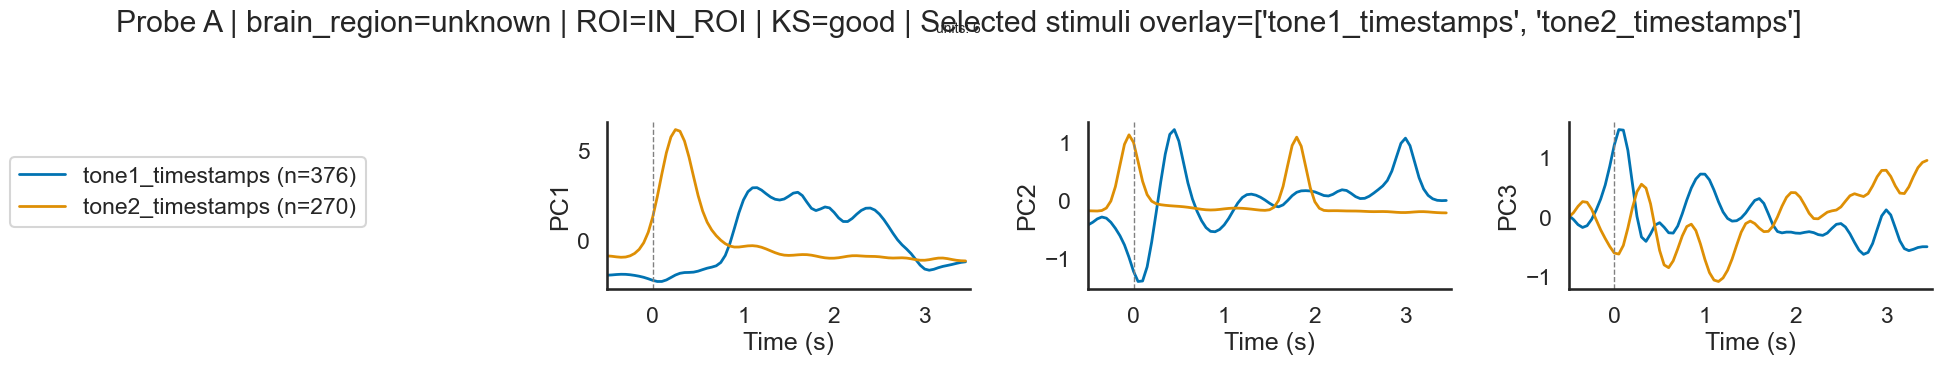

In [133]:
# Single-probe overlay run
# Example groups:
OVERLAY_STIMULI_1 = ["opto_closed_loop_start_timestamps", "opto_tag_start_timestamps"]
OVERLAY_STIMULI_2 = ["opto_closed_loop_start_timestamps", "opto_tag_start_timestamps"]
OVERLAY_STIMULI_3 = ["tone1_timestamps", "tone2_timestamps"]

OVERLAY_STIMULI = {
    "group1": OVERLAY_STIMULI_1,
    "group2": OVERLAY_STIMULI_2,
    "group3": OVERLAY_STIMULI_3,
}

for group_name, group_stims in OVERLAY_STIMULI.items():
    _single_overlay_df = pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=OVERLAY_SINGLE_PROBE,
        roi_filter=OVERLAY_ROI_FILTER,
        kslabel_filter=OVERLAY_KSLABEL_FILTER,
    )
    if _single_overlay_df.empty:
        raise ValueError(f"Probe {OVERLAY_SINGLE_PROBE}: no units after filters.")

    if "brain_region" in _single_overlay_df.columns:
        _overlay_regions_all = sorted(_single_overlay_df["brain_region"].map(_pca_norm_brain_region).unique().tolist())
    else:
        _overlay_regions_all = [None]

    if OVERLAY_SINGLE_BRAIN_REGION is None:
        _overlay_regions = _overlay_regions_all
    else:
        _overlay_regions = [_pca_norm_brain_region(OVERLAY_SINGLE_BRAIN_REGION)]

    for _brain_region in _overlay_regions:
        region_label = _pca_norm_brain_region(_brain_region) if _brain_region is not None else "all_regions"
        print(f"Running overlay for probe={OVERLAY_SINGLE_PROBE}, brain_region={region_label}, stimuli={group_stims}")
        overlay_single = plot_probe_selected_stimuli_overlay(
            probe=OVERLAY_SINGLE_PROBE,
            merged_dic=merged_dic,
            events_df=OVERLAY_EVENTS_DF,
            selected_stimuli=group_stims,
            stim_label_col=STIM_PLOT_LABEL_COL,
            time_col=STIM_PLOT_TIME_COL,
            roi_filter=OVERLAY_ROI_FILTER,
            kslabel_filter=OVERLAY_KSLABEL_FILTER,
            brain_region_filter=_brain_region,
            n_components=OVERLAY_N_COMPONENTS,
            smooth_sigma=OVERLAY_SMOOTH_SIGMA,
            max_tensor_gb=PCA_MAX_TENSOR_GB,
            max_events_per_stim=OVERLAY_MAX_EVENTS_PER_STIM,
            show_plots=True,
        )


### Batch overlay across probes

In [134]:
# list of all available stimuli in overlay events table (includes custom arrays if enabled)
stimuli_list = OVERLAY_EVENTS_DF[STIM_PLOT_LABEL_COL].astype(str).unique().tolist()
print('======= Options for OVERLAY_STIMULI =======')
print("Unique stimuli in OVERLAY_EVENTS_DF:", stimuli_list)


======= Options for OVERLAY_STIMULI =======
Unique stimuli in OVERLAY_EVENTS_DF: ['tone1_timestamps', 'reachInit_stimROI_timestamps', 'tone2_timestamps', 'stimROI_timestamps', 'opto_closed_loop_start_timestamps', 'optical_timestamps', 'opto_tag_start_timestamps', 'opto_tagging_timestamps']


In [136]:
# Batch overlay runs for multiple stimulus sets
OVERLAY_STIMULI_1 = ["reachInit_stimROI_timestamps", "tone1_timestamps", "tone2_timestamps"]
OVERLAY_STIMULI_2 = ["tone1_timestamps", "tone2_timestamps"]
OVERLAY_STIMULI_3 = ["stimROI_timestamps", "opto_tagging_timestamps"]
OVERLAY_STIMULI_4 = ["opto_closed_loop_start_timestamps", "opto_tag_start_timestamps"]

STIMULI_BATCH_OPTIONS = {
    "option1": OVERLAY_STIMULI_1,
    "option2": OVERLAY_STIMULI_2,
    "option3": OVERLAY_STIMULI_3,
    "option4_custom_arrays": OVERLAY_STIMULI_4,
}

for option_name, stimuli_set in STIMULI_BATCH_OPTIONS.items():
    print(f"\n=== Running overlay batch for stimuli set: {option_name} ===")
    print(f"Selected stimuli: {stimuli_set}")

    if OVERLAY_PROBES is None:
        _overlay_probes = sorted(list(merged_dic.keys()))
    else:
        _overlay_probes = [p for p in OVERLAY_PROBES if p in merged_dic]

    overlay_batch_results = {}
    for _probe in _overlay_probes:
        print("\n================================")
        print(f"Overlay plotting for probe {_probe}")

        _probe_df = pca_get_probe_units_df(
            merged_dic=merged_dic,
            probe=_probe,
            roi_filter=OVERLAY_ROI_FILTER,
            kslabel_filter=OVERLAY_KSLABEL_FILTER,
        )
        if _probe_df.empty:
            print(f"Skipping probe {_probe}: no units after filters.")
            continue

        if "brain_region" in _probe_df.columns:
            _regions_all = sorted(_probe_df["brain_region"].map(_pca_norm_brain_region).unique().tolist())
        else:
            _regions_all = [None]

        if OVERLAY_BATCH_BRAIN_REGIONS is None:
            _regions = _regions_all
        else:
            _regions = [
                _pca_norm_brain_region(x)
                for x in OVERLAY_BATCH_BRAIN_REGIONS
                if _pca_norm_brain_region(x) in _regions_all
            ]

        overlay_batch_results[_probe] = {}
        for _brain_region in _regions:
            region_label = _pca_norm_brain_region(_brain_region) if _brain_region is not None else "all_regions"
            print(f"  -> brain_region={region_label}")
            overlay_batch_results[_probe][region_label] = plot_probe_selected_stimuli_overlay(
                probe=_probe,
                merged_dic=merged_dic,
                events_df=OVERLAY_EVENTS_DF,
                selected_stimuli=stimuli_set,
                stim_label_col=STIM_PLOT_LABEL_COL,
                time_col=STIM_PLOT_TIME_COL,
                roi_filter=OVERLAY_ROI_FILTER,
                kslabel_filter=OVERLAY_KSLABEL_FILTER,
                brain_region_filter=_brain_region,
                n_components=OVERLAY_N_COMPONENTS,
                smooth_sigma=OVERLAY_SMOOTH_SIGMA,
                max_tensor_gb=PCA_MAX_TENSOR_GB,
                max_events_per_stim=OVERLAY_MAX_EVENTS_PER_STIM,
                show_plots=False,
            )

print("\nCompleted overlay plots for probes:", list(overlay_batch_results.keys()))



=== Running overlay batch for stimuli set: option1 ===
Selected stimuli: ['reachInit_stimROI_timestamps', 'tone1_timestamps', 'tone2_timestamps']

Overlay plotting for probe A
  -> brain_region=IP
Requested tensor shape=(270, 14, 80) est_mem=0.00 GB
Requested tensor shape=(376, 14, 80) est_mem=0.00 GB
Requested tensor shape=(270, 14, 80) est_mem=0.00 GB
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel_overlay\reachInit_stimROI_timestamps__tone1_timestamps__tone2_timestamps\probe_A_IP_ROI_IN_ROI_KS_good.png
  -> brain_region=SIM
Requested tensor shape=(270, 117, 80) est_mem=0.01 GB
Requested tensor shape=(376, 117, 80) est_mem=0.01 GB
Requested tensor shape=(270, 117, 80) est_mem=0.01 GB
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\stimulus_panel_overlay\reachInit_stimROI_timestamps__tone1_

### Epoch/Condition Event Mapping (From Trial Indices)

This section builds:
1. `stimulation_trials_start_times`
2. `washout_trials_start_times`
3. `pca_event_meta` with `epoch_id` + `condition`

It uses:
- `all_stimROI_triggers_start_times`
- `baseline_trials_idx`, `optoicalStim_trials_idx`, `washout_trials_idx`


In [303]:
def _flatten_idx(x):
    if isinstance(x, np.ndarray):
        x = x.tolist()
    if not isinstance(x, (list, tuple)):
        return [int(x)]
    out = []
    for item in x:
        if isinstance(item, (list, tuple, np.ndarray)):
            out.extend(_flatten_idx(item))
        else:
            out.append(int(item))
    return out


def _normalize_trial_indices(idx_nested, n_trials):
    """
    Accept nested trial index/number groups and normalize to 0-based integer indices.
    Handles 1-based trial numbers automatically.
    Returns list[list[int]] preserving epoch nesting.
    """
    if isinstance(idx_nested, np.ndarray):
        idx_nested = idx_nested.tolist()
    if not isinstance(idx_nested, (list, tuple)):
        idx_nested = [idx_nested]

    # force epoch nesting
    epochs = []
    for ep in idx_nested:
        if isinstance(ep, (list, tuple, np.ndarray)):
            epochs.append([int(v) for v in _flatten_idx(ep)])
        else:
            epochs.append([int(ep)])

    # detect indexing convention from global max
    all_vals = [v for ep in epochs for v in ep]
    if len(all_vals) == 0:
        return [[] for _ in epochs]

    max_v = max(all_vals)
    min_v = min(all_vals)

    # 1-based if max equals n_trials and min >= 1
    one_based = (max_v <= n_trials) and (min_v >= 1)

    norm = []
    for ep in epochs:
        if one_based:
            ep0 = [v - 1 for v in ep]
        else:
            ep0 = [v for v in ep]
        ep0 = [v for v in ep0 if 0 <= v < n_trials]
        norm.append(sorted(list(set(ep0))))
    return norm


if 'all_stimROI_triggers_start_times' not in globals():
    raise ValueError("all_stimROI_triggers_start_times not found. Run the stim extraction cells first.")
if 'baseline_trials_idx' not in globals() or 'optoicalStim_trials_idx' not in globals() or 'washout_trials_idx' not in globals():
    raise ValueError("Need baseline_trials_idx, optoicalStim_trials_idx, washout_trials_idx loaded first.")

all_stimROI_triggers_start_times = np.asarray(all_stimROI_triggers_start_times, dtype=float)
n_trials_total = len(all_stimROI_triggers_start_times)

baseline_idx_epochs = _normalize_trial_indices(baseline_trials_idx, n_trials_total)
stim_idx_epochs = _normalize_trial_indices(optoicalStim_trials_idx, n_trials_total)
wash_idx_epochs = _normalize_trial_indices(washout_trials_idx, n_trials_total)

# Build metadata rows
rows = []

# baseline is epoch 0 (or baseline_1 for plotting readability)
for ep_i, ep_idx in enumerate(baseline_idx_epochs, start=1):
    for tidx in ep_idx:
        rows.append({
            "trial_index0": int(tidx),
            "trial_number": int(tidx + 1),
            "start_time": float(all_stimROI_triggers_start_times[tidx]),
            "condition": "baseline",
            "epoch_id": int(0),
            "condition_epoch": f"baseline_epoch",
        })

for ep_i, ep_idx in enumerate(stim_idx_epochs, start=1):
    for tidx in ep_idx:
        rows.append({
            "trial_index0": int(tidx),
            "trial_number": int(tidx + 1),
            "start_time": float(all_stimROI_triggers_start_times[tidx]),
            "condition": "stimulation",
            "epoch_id": int(ep_i),
            "condition_epoch": f"stimulation_epoch_{ep_i}",
        })

for ep_i, ep_idx in enumerate(wash_idx_epochs, start=1):
    for tidx in ep_idx:
        rows.append({
            "trial_index0": int(tidx),
            "trial_number": int(tidx + 1),
            "start_time": float(all_stimROI_triggers_start_times[tidx]),
            "condition": "washout",
            "epoch_id": int(ep_i),
            "condition_epoch": f"washout_epoch_{ep_i}",
        })

pca_event_meta = pd.DataFrame(rows).drop_duplicates(subset=["trial_index0"]).sort_values("trial_index0").reset_index(drop=True)

# Requested outputs
stimulation_trials_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "stimulation", "start_time"].to_numpy(dtype=float)
washout_trials_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "washout", "start_time"].to_numpy(dtype=float)

print("Built pca_event_meta rows:", len(pca_event_meta))
print("stimulation_trials_start_times:", len(stimulation_trials_start_times))
print("washout_trials_start_times:", len(washout_trials_start_times))
# print("\nCounts by condition/epoch:")
# print(pca_event_meta.groupby(["condition", "epoch_id"]).size())

pca_event_meta.head(5)


Built pca_event_meta rows: 270
stimulation_trials_start_times: 130
washout_trials_start_times: 120


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
0,0,1,10239.893300,baseline,0,baseline_epoch
1,1,2,10263.343867,baseline,0,baseline_epoch
2,2,3,10285.494367,baseline,0,baseline_epoch
3,3,4,10306.931567,baseline,0,baseline_epoch
4,4,5,10383.171333,baseline,0,baseline_epoch


### Look at range of trial indices in each condition

In [304]:
baseline_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "baseline", "start_time"].to_numpy(dtype=float)
stimulation_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "stimulation", "start_time"].to_numpy(dtype=float)
washout_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "washout", "start_time"].to_numpy(dtype=float)
print("Baseline trials:", len(baseline_start_times), "start times range:", baseline_start_times.min(), "-", baseline_start_times.max())
print("Stimulation trials:", len(stimulation_start_times), "start times range:", stimulation_start_times.min(), "-", stimulation_start_times.max())
print("Washout trials:", len(washout_start_times), "start times range:", washout_start_times.min(), "-", washout_start_times.max())



Baseline trials: 20 start times range: 10239.8933 - 10893.505433333334
Stimulation trials: 130 start times range: 10919.65 - 18785.4879
Washout trials: 120 start times range: 11432.124666666667 - 18502.825833333332


### PCA Plot: Color by Epoch, Marker by Condition

- Color encodes `epoch_id`
- Marker encodes `condition` (`baseline`, `stimulation`, `washout`)


In [305]:
def run_epoch_condition_pca_for_probe(probe,
                                      merged_dic,
                                      event_meta,
                                      roi_filter=None,
                                      kslabel_filter="both",
                                      include_conditions=None,
                                      n_components=12,
                                      max_tensor_gb=8.0,
                                      brain_region_filter=None):
    if include_conditions is None:
        include_conditions = ["baseline", "stimulation", "washout"]

    em = event_meta.copy()
    em = em[em["condition"].isin(include_conditions)].reset_index(drop=True)
    if em.empty:
        raise ValueError("No events left after include_conditions filter.")

    probe_df = pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=probe,
        roi_filter=roi_filter,
        kslabel_filter=kslabel_filter,
    )
    if probe_df.empty:
        raise ValueError(f"Probe {probe}: no units after filtering.")

    if "brain_region" in probe_df.columns:
        br = probe_df["brain_region"].map(_normalize_brain_region_value)
        probe_df = probe_df.assign(brain_region=br)
        if brain_region_filter is not None:
            target = _normalize_brain_region_value(brain_region_filter)
            probe_df = probe_df[probe_df["brain_region"] == target].reset_index(drop=True)
            if probe_df.empty:
                raise ValueError(f"Probe {probe}: no units for brain_region={target} after filtering.")

    spike_times = [np.asarray(x, dtype=float) for x in probe_df["spike_times"].values]

    trials, t = pca_bin_spikes_around_events(
        spike_times_list=spike_times,
        event_times_s=em["start_time"].to_numpy(dtype=float),
        win_start_s=WINDOW_START_S,
        win_end_s=WINDOW_END_S,
        bin_size_s=BIN_SIZE_S,
        max_tensor_gb=max_tensor_gb,
    )

    # Trial-level PCA (one point per event)
    X_trial = trials.mean(axis=2).T  # (units, n_events)
    Xz = zscore_rows(X_trial)
    pca = PCA(n_components=min(n_components, Xz.shape[0], Xz.shape[1]))
    Xp = pca.fit_transform(Xz.T).T

    return em, trials, t, Xp, pca.explained_variance_ratio_



def _normalize_brain_region_value(v):
    if pd.isna(v):
        return "unknown"
    s = str(v).strip()
    if s == "":
        return "unknown"
    if s.lower() in {"nan", "none", "null"}:
        return "unknown"
    return s
def _list_probe_brain_regions(merged_dic, probe, roi_filter=None, kslabel_filter="both"):
    probe_df = pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=probe,
        roi_filter=roi_filter,
        kslabel_filter=kslabel_filter,
    )
    if probe_df.empty:
        return []

    if "brain_region" not in probe_df.columns:
        return ["unknown"]

    vals = probe_df["brain_region"].map(_normalize_brain_region_value)
    return sorted(vals.unique().tolist())


def _probe_brain_region_label(merged_dic, probe, roi_filter=None, kslabel_filter="both", max_regions=6, brain_region_filter=None):
    probe_df = pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=probe,
        roi_filter=roi_filter,
        kslabel_filter=kslabel_filter,
    )
    if probe_df.empty or ("brain_region" not in probe_df.columns):
        return "brain_region: n/a"

    vals = probe_df["brain_region"].map(_normalize_brain_region_value)

    if brain_region_filter is not None:
        return f"brain_region: {_normalize_brain_region_value(brain_region_filter)}"

    uniq = sorted(vals.unique().tolist())
    if len(uniq) == 0:
        return "brain_region: n/a"
    if len(uniq) <= max_regions:
        return "brain_region: " + ", ".join(uniq)
    head = ", ".join(uniq[:max_regions])
    return f"brain_region: {head}, +{len(uniq) - max_regions} more"


def plot_epoch_condition_scatter(Xp, event_meta, title_prefix="", subtitle="", probe="unknown", brain_region="unknown", n_units=None, show_plots=True):
    if Xp.shape[0] < 3:
        raise ValueError(f"Need at least 3 PCs for plotting; got {Xp.shape[0]}.")

    projections = [(0, 1), (1, 2), (0, 2)]

    # Color by epoch
    epochs = sorted(event_meta["epoch_id"].dropna().astype(int).unique().tolist())
    pal = sns.color_palette("husl", max(3, len(epochs)))
    epoch_color = {ep: pal[i % len(pal)] for i, ep in enumerate(epochs)}

    # Marker by condition
    cond_marker = {
        "baseline": "o",
        "stimulation": "^",
        "washout": "s",
    }

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    for ax, (i, j) in zip(axes, projections):
        for cond in event_meta["condition"].unique():
            em_cond = event_meta[event_meta["condition"] == cond]
            marker = cond_marker.get(cond, "o")
            for ep in sorted(em_cond["epoch_id"].dropna().astype(int).unique()):
                idx = em_cond.index[em_cond["epoch_id"].astype(int) == ep].to_numpy()
                label = f"{cond}, epoch {ep}"
                ax.scatter(
                    Xp[i, idx],
                    Xp[j, idx],
                    s=140,
                    alpha=1.0,
                    marker=marker,
                    color=epoch_color[ep],
                    edgecolors="black",
                    linewidths=0.8,
                    label=label,
                )

        ax.set_xlabel(f"PC {i+1}")
        ax.set_ylabel(f"PC {j+1}")

    handles, labels = axes[-1].get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    axes[-1].legend(uniq.values(), uniq.keys(), frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=10)

    fig.suptitle(title_prefix, fontsize=18, y=0.99)
    if subtitle:
        fig.text(0.5, 0.94, subtitle, ha="center", va="center", fontsize=11)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.91 if subtitle else 0.94, units_text, ha="center", va="center", fontsize=10)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 1, 0.9])

    save_path = root_PCA_plot_save_path / 'PCA_by_Epoch' / '2D_scatter'
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_{_sanitize_name(brain_region)}_epoch_condition_scatter_2D.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_condition_scatter_3d(Xp, event_meta, title_prefix="", subtitle="", probe="unknown", brain_region="unknown", n_units=None, show_plots=False):
    if Xp.shape[0] < 3:
        raise ValueError(f"Need at least 3 PCs for 3D plotting; got {Xp.shape[0]}.")

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    epochs = sorted(event_meta["epoch_id"].dropna().astype(int).unique().tolist())
    pal = sns.color_palette("husl", max(3, len(epochs)))
    epoch_color = {ep: pal[i % len(pal)] for i, ep in enumerate(epochs)}

    cond_marker = {
        "baseline": "o",
        "stimulation": "^",
        "washout": "s",
    }

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection="3d")

    for cond in event_meta["condition"].unique():
        em_cond = event_meta[event_meta["condition"] == cond]
        marker = cond_marker.get(cond, "o")
        for ep in sorted(em_cond["epoch_id"].dropna().astype(int).unique()):
            idx = em_cond.index[em_cond["epoch_id"].astype(int) == ep].to_numpy()
            label = f"{cond}, epoch {ep}"
            ax.scatter(
                Xp[0, idx],
                Xp[1, idx],
                Xp[2, idx],
                s=90,
                alpha=1.0,
                marker=marker,
                color=epoch_color[ep],
                edgecolors="black",
                linewidths=0.6,
                label=label,
            )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")

    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=9)

    fig.suptitle(title_prefix + " (3D)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "3D_scatter"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_{_sanitize_name(brain_region)}_epoch_condition_scatter_3D.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")
    if show_plots:
         plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_condition_line_3d_time(
    Xp,
    event_meta,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    time_col="start_time",
    n_units=None,
    show_plots=False,
):
    if Xp.shape[0] < 2:
        raise ValueError(f"Need at least 2 PCs for PC1-PC2-Time plotting; got {Xp.shape[0]}.")
    if time_col not in event_meta.columns:
        raise ValueError(f"{time_col} not found in event_meta columns: {list(event_meta.columns)}")

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    em = event_meta.copy()
    em[time_col] = pd.to_numeric(em[time_col], errors="coerce")
    em = em.dropna(subset=[time_col, "epoch_id", "condition"]).reset_index(drop=True)
    if em.empty:
        raise ValueError("No valid events available after dropping NaN times/labels.")

    t0 = em[time_col].min()
    em["time_rel_s"] = em[time_col] - t0

    epochs = sorted(em["epoch_id"].astype(int).unique().tolist())
    pal = sns.color_palette("husl", max(3, len(epochs)))
    epoch_color = {ep: pal[i % len(pal)] for i, ep in enumerate(epochs)}

    cond_marker = {
        "baseline": "o",
        "stimulation": "^",
        "washout": "s",
    }
    cond_linestyle = {
        "baseline": "-",
        "stimulation": "--",
        "washout": ":",
    }

    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection="3d")

    for cond in em["condition"].astype(str).unique():
        em_cond = em[em["condition"].astype(str) == cond]
        marker = cond_marker.get(cond, "o")
        ls = cond_linestyle.get(cond, "-")

        for ep in sorted(em_cond["epoch_id"].astype(int).unique()):
            idx = em_cond.index[em_cond["epoch_id"].astype(int) == ep].to_numpy()
            if idx.size < 2:
                continue

            order = np.argsort(em.loc[idx, "time_rel_s"].to_numpy(dtype=float))
            idx = idx[order]
            label = f"{cond}, epoch {ep}"

            ax.plot(
                Xp[0, idx],
                Xp[1, idx],
                em.loc[idx, "time_rel_s"].to_numpy(dtype=float),
                color=epoch_color[ep],
                linestyle=ls,
                linewidth=2.2,
                marker=marker,
                markersize=4.0,
                markeredgecolor="black",
                markeredgewidth=0.5,
                label=label,
            )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("Time (s, rel)")

    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=9)

    fig.suptitle(title_prefix + " (PC1-PC2-Time)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "3D_PC12_Time"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_epoch_condition_line_PC12_Time.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")

def _epoch_condition_color_marker_maps(event_meta):
    epochs = sorted(event_meta["epoch_id"].dropna().astype(int).unique().tolist())
    pal = sns.color_palette("husl", max(3, len(epochs)))
    epoch_color = {ep: pal[i % len(pal)] for i, ep in enumerate(epochs)}

    cond_marker = {
        "baseline": "o",
        "stimulation": "^",
        "washout": "s",
    }
    cond_linestyle = {
        "baseline": "-",
        "stimulation": "--",
        "washout": "-",
    }
    return epoch_color, cond_marker, cond_linestyle


def _epoch_mean_pc_table(Xp, event_meta, time_col="start_time"):
    em = event_meta.copy().reset_index(drop=True)
    if Xp.shape[1] != len(em):
        raise ValueError(f"Xp/events mismatch: Xp has {Xp.shape[1]} events, event_meta has {len(em)} rows.")

    em["_event_idx"] = np.arange(len(em), dtype=int)
    rows = []
    n_pc = min(3, Xp.shape[0])

    for (cond, ep), g in em.groupby(["condition", "epoch_id"], dropna=True):
        idx = g["_event_idx"].to_numpy(dtype=int)
        if idx.size == 0:
            continue

        rec = {
            "condition": str(cond),
            "epoch_id": int(ep),
            "n_trials": int(idx.size),
        }
        for pc in range(n_pc):
            rec[f"pc{pc+1}"] = float(np.mean(Xp[pc, idx]))

        if time_col in g.columns:
            tvals = pd.to_numeric(g[time_col], errors="coerce").dropna().to_numpy(dtype=float)
            rec["time_mean"] = float(np.mean(tvals)) if tvals.size else np.nan

        rows.append(rec)

    out = pd.DataFrame(rows)
    if out.empty:
        raise ValueError("No epoch groups available for epoch-mean plotting.")

    out = out.sort_values(["condition", "epoch_id"]).reset_index(drop=True)
    if "time_mean" in out.columns:
        t0 = np.nanmin(out["time_mean"].to_numpy(dtype=float))
        if np.isfinite(t0):
            out["time_rel_s"] = out["time_mean"] - t0

    return out


def plot_epoch_condition_epochmean_scatter(
    Xp,
    event_meta,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    n_units=None,
    show_plots=True,
):
    if Xp.shape[0] < 3:
        raise ValueError(f"Need at least 3 PCs for plotting; got {Xp.shape[0]}.")

    em_mean = _epoch_mean_pc_table(Xp, event_meta)
    epoch_color, cond_marker, _ = _epoch_condition_color_marker_maps(event_meta)

    projections = [(0, 1), (1, 2), (0, 2)]
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    for ax, (i, j) in zip(axes, projections):
        for _, rec in em_mean.iterrows():
            cond = str(rec["condition"])
            ep = int(rec["epoch_id"])
            ax.scatter(
                rec[f"pc{i+1}"],
                rec[f"pc{j+1}"],
                s=240,
                alpha=1.0,
                marker=cond_marker.get(cond, "o"),
                color=epoch_color.get(ep, "tab:blue"),
                edgecolors="black",
                linewidths=1.0,
                label=f"{cond}, epoch {ep} (n={int(rec['n_trials'])})",
            )

        ax.set_xlabel(f"PC {i+1}")
        ax.set_ylabel(f"PC {j+1}")

    handles, labels = axes[-1].get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    axes[-1].legend(uniq.values(), uniq.keys(), frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=10)

    fig.suptitle(title_prefix + " (Epoch means)", fontsize=18, y=0.99)
    if subtitle:
        fig.text(0.5, 0.94, subtitle, ha="center", va="center", fontsize=11)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.91 if subtitle else 0.94, units_text, ha="center", va="center", fontsize=10)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 0.86, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "EpochMean_2D"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_epochmean_scatter_2D.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_condition_epochmean_scatter_3d(
    Xp,
    event_meta,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    n_units=None,
    show_plots=False,
):
    if Xp.shape[0] < 3:
        raise ValueError(f"Need at least 3 PCs for 3D plotting; got {Xp.shape[0]}.")

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    em_mean = _epoch_mean_pc_table(Xp, event_meta)
    epoch_color, cond_marker, _ = _epoch_condition_color_marker_maps(event_meta)

    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection="3d")

    for _, rec in em_mean.iterrows():
        cond = str(rec["condition"])
        ep = int(rec["epoch_id"])
        ax.scatter(
            rec["pc1"],
            rec["pc2"],
            rec["pc3"],
            s=120,
            alpha=1.0,
            marker=cond_marker.get(cond, "o"),
            color=epoch_color.get(ep, "tab:blue"),
            edgecolors="black",
            linewidths=0.8,
            label=f"{cond}, epoch {ep} (n={int(rec['n_trials'])})",
        )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")

    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=9)

    fig.suptitle(title_prefix + " (Epoch means, 3D)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "EpochMean_3D"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_epochmean_scatter_3D.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_condition_epochmean_line_3d_time(
    Xp,
    event_meta,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    smooth_sigma=1.2,
    n_units=None,
    show_plots=False,
):
    if Xp.shape[0] < 2:
        raise ValueError(f"Need at least 2 PCs for PC1-PC2-Time plotting; got {Xp.shape[0]}.")

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    em_mean = _epoch_mean_pc_table(Xp, event_meta)
    if "time_rel_s" not in em_mean.columns:
        em_mean = em_mean.copy()
        em_mean["time_rel_s"] = em_mean["epoch_id"].astype(float)

    epoch_color, cond_marker, cond_linestyle = _epoch_condition_color_marker_maps(event_meta)

    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection="3d")

    for cond in em_mean["condition"].astype(str).unique():
        g = em_mean[em_mean["condition"].astype(str) == cond].sort_values("epoch_id")
        if g.empty:
            continue

        x = g["pc1"].to_numpy(dtype=float)
        y = g["pc2"].to_numpy(dtype=float)
        z = g["time_rel_s"].to_numpy(dtype=float)

        if smooth_sigma and smooth_sigma > 0 and len(x) >= 3:
            x = gaussian_filter1d(x, sigma=smooth_sigma)
            y = gaussian_filter1d(y, sigma=smooth_sigma)
            z = gaussian_filter1d(z, sigma=smooth_sigma)

        ax.plot(
            x,
            y,
            z,
            color="black",
            linestyle=cond_linestyle.get(cond, "-"),
            linewidth=2.4,
            alpha=0.85,
            label=f"{cond} trend",
        )

        for ii, (_, rec) in enumerate(g.iterrows()):
            ep = int(rec["epoch_id"])
            ax.scatter(
                x[ii],
                y[ii],
                z[ii],
                s=120,
                alpha=1.0,
                marker=cond_marker.get(cond, "o"),
                color=epoch_color.get(ep, "tab:blue"),
                edgecolors="black",
                linewidths=0.8,
                label=f"{cond}, epoch {ep} (n={int(rec['n_trials'])})",
            )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("Time (s, rel)")

    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=9)

    fig.suptitle(title_prefix + " (Epoch means, PC1-PC2-Time)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "EpochMean_PC12_Time"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_epochmean_line_PC12_Time.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def pca_trial_timebin_scores(trials, n_components=6):
    if trials.ndim != 3:
        raise ValueError(f"Expected trials shape (n_trials, n_units, n_bins), got {trials.shape}")

    n_trials, n_units, n_bins = trials.shape
    X = trials.transpose(0, 2, 1).reshape(n_trials * n_bins, n_units)

    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    Xz = (X - mu) / sd

    pca = PCA(n_components=min(n_components, Xz.shape[0], Xz.shape[1]))
    S = pca.fit_transform(Xz)
    S = S.reshape(n_trials, n_bins, -1)
    return S, pca.explained_variance_ratio_


def plot_epoch_condition_trial_time_lines_2d(
    trial_time_scores,
    event_meta,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    smooth_sigma=1.2,
    n_units=None,
    show_plots=False,
):
    if trial_time_scores.shape[2] < 2:
        raise ValueError(f"Need at least 2 PCs; got {trial_time_scores.shape[2]}.")
    if trial_time_scores.shape[0] != len(event_meta):
        raise ValueError("Mismatch between trial_time_scores trials and event_meta rows.")

    em = event_meta.copy().reset_index(drop=True)
    epoch_color, _, cond_linestyle = _epoch_condition_color_marker_maps(em)

    fig, ax = plt.subplots(1, 1, figsize=(13, 10))
    seen = set()

    for i in range(len(em)):
        cond = str(em.loc[i, "condition"])
        ep = int(em.loc[i, "epoch_id"])
        x = trial_time_scores[i, :, 0].astype(float)
        y = trial_time_scores[i, :, 1].astype(float)

        if smooth_sigma and smooth_sigma > 0:
            x = gaussian_filter1d(x, sigma=smooth_sigma)
            y = gaussian_filter1d(y, sigma=smooth_sigma)

        label = f"{cond}, epoch {ep}"
        if label in seen:
            label = None
        else:
            seen.add(label)

        ax.plot(
            x,
            y,
            color=epoch_color.get(ep, "tab:blue"),
            linestyle=cond_linestyle.get(cond, "-"),
            linewidth=1.6,
            alpha=0.65,
            label=label,
        )
        ax.scatter(
            x,
            y,
            s=8,
            color=epoch_color.get(ep, "tab:blue"),
            alpha=0.35,
            linewidths=0,
        )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=9)

    fig.suptitle(title_prefix + " (Trial lines from time bins, 2D)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "TrialTimeLines_2D"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_trial_time_lines_2D.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_condition_trial_time_lines_3d(
    trial_time_scores,
    event_meta,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    smooth_sigma=1.2,
    n_units=None,
    show_plots=False,
):
    if trial_time_scores.shape[2] < 3:
        raise ValueError(f"Need at least 3 PCs; got {trial_time_scores.shape[2]}.")
    if trial_time_scores.shape[0] != len(event_meta):
        raise ValueError("Mismatch between trial_time_scores trials and event_meta rows.")

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    em = event_meta.copy().reset_index(drop=True)
    epoch_color, _, cond_linestyle = _epoch_condition_color_marker_maps(em)

    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection="3d")
    seen = set()

    for i in range(len(em)):
        cond = str(em.loc[i, "condition"])
        ep = int(em.loc[i, "epoch_id"])
        x = trial_time_scores[i, :, 0].astype(float)
        y = trial_time_scores[i, :, 1].astype(float)
        z = trial_time_scores[i, :, 2].astype(float)

        if smooth_sigma and smooth_sigma > 0:
            x = gaussian_filter1d(x, sigma=smooth_sigma)
            y = gaussian_filter1d(y, sigma=smooth_sigma)
            z = gaussian_filter1d(z, sigma=smooth_sigma)

        label = f"{cond}, epoch {ep}"
        if label in seen:
            label = None
        else:
            seen.add(label)

        ax.plot(
            x,
            y,
            z,
            color=epoch_color.get(ep, "tab:blue"),
            linestyle=cond_linestyle.get(cond, "-"),
            linewidth=1.6,
            alpha=0.65,
            label=label,
        )
        ax.scatter(
            x,
            y,
            z,
            s=6,
            color=epoch_color.get(ep, "tab:blue"),
            alpha=0.30,
            linewidths=0,
        )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=9)

    fig.suptitle(title_prefix + " (Trial lines from time bins, 3D)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "TrialTimeLines_3D"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_trial_time_lines_3D.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")

def plot_epoch_condition_epochmean_scatter_3d_time(
    Xp,
    event_meta,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    n_units=None,
    show_plots=False,
):
    if Xp.shape[0] < 2:
        raise ValueError(f"Need at least 2 PCs for PC1-PC2-Time plotting; got {Xp.shape[0]}.")

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    em_mean = _epoch_mean_pc_table(Xp, event_meta)
    if "time_rel_s" not in em_mean.columns:
        raise ValueError("time_rel_s missing from epoch-mean table. Check event time column in event_meta.")

    epoch_color, cond_marker, _ = _epoch_condition_color_marker_maps(event_meta)

    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection="3d")

    for _, rec in em_mean.iterrows():
        cond = str(rec["condition"])
        ep = int(rec["epoch_id"])
        ax.scatter(
            rec["pc1"],
            rec["pc2"],
            rec["time_rel_s"],
            s=120,
            alpha=1.0,
            marker=cond_marker.get(cond, "o"),
            color=epoch_color.get(ep, "tab:blue"),
            edgecolors="black",
            linewidths=0.8,
            label=f"{cond}, epoch {ep} (n={int(rec['n_trials'])})",
        )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("Time (s, rel)")

    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=9)

    fig.suptitle(title_prefix + " (Epoch means, PC1-PC2-Time points)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "EpochMean_PC12_Time_Points"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_epochmean_scatter_PC12_Time.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_condition_trial_time_lines_pc12_time(
    trial_time_scores,
    event_meta,
    bin_time=None,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    smooth_sigma=1.2,
    n_units=None,
    show_plots=False,
):
    if trial_time_scores.shape[2] < 2:
        raise ValueError(f"Need at least 2 PCs; got {trial_time_scores.shape[2]}.")
    if trial_time_scores.shape[0] != len(event_meta):
        raise ValueError("Mismatch between trial_time_scores trials and event_meta rows.")

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    n_trials, n_bins, _ = trial_time_scores.shape
    if bin_time is None:
        z = np.arange(n_bins, dtype=float)
    else:
        z = np.asarray(bin_time, dtype=float).ravel()
        if z.size != n_bins:
            raise ValueError(f"bin_time length ({z.size}) must equal n_bins ({n_bins}).")
    z = z - np.nanmin(z)

    em = event_meta.copy().reset_index(drop=True)
    epoch_color, _, cond_linestyle = _epoch_condition_color_marker_maps(em)

    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection="3d")
    seen = set()

    for i in range(n_trials):
        cond = str(em.loc[i, "condition"])
        ep = int(em.loc[i, "epoch_id"])

        x = trial_time_scores[i, :, 0].astype(float)
        y = trial_time_scores[i, :, 1].astype(float)

        if smooth_sigma and smooth_sigma > 0:
            x = gaussian_filter1d(x, sigma=smooth_sigma)
            y = gaussian_filter1d(y, sigma=smooth_sigma)

        label = f"{cond}, epoch {ep}"
        if label in seen:
            label = None
        else:
            seen.add(label)

        ax.plot(
            x,
            y,
            z,
            color=epoch_color.get(ep, "tab:blue"),
            linestyle=cond_linestyle.get(cond, "-"),
            linewidth=1.6,
            alpha=0.65,
            label=label,
        )
        ax.scatter(
            x,
            y,
            z,
            s=6,
            color=epoch_color.get(ep, "tab:blue"),
            alpha=0.30,
            linewidths=0,
        )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("Time from event (s)")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=9)

    fig.suptitle(title_prefix + " (Per-trial lines, PC1-PC2-Time)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "TrialTimeLines_PC12_Time"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_trial_time_lines_PC12_Time.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")

def pca_epoch_population_timebin_trajectories(trials, event_meta, n_components=6):
    """
    Build one average population trajectory per (condition, epoch_id):
    - average trials within each epoch -> (n_units, n_bins)
    - concatenate all epoch means across time bins
    - run PCA once across concatenated epoch trajectories
    Returns:
        epoch_info_df: row per epoch group with labels and counts
        epoch_traj: list of arrays, each shape (n_components_used, n_bins)
        evr: explained variance ratio
    """
    if trials.ndim != 3:
        raise ValueError(f"Expected trials shape (n_trials, n_units, n_bins), got {trials.shape}")

    n_trials, n_units, n_bins = trials.shape
    em = event_meta.copy().reset_index(drop=True)
    if len(em) != n_trials:
        raise ValueError(f"event_meta rows ({len(em)}) must match n_trials ({n_trials}).")

    for col in ["condition", "epoch_id"]:
        if col not in em.columns:
            raise ValueError(f"Required column '{col}' missing from event_meta.")

    em["_trial_idx"] = np.arange(len(em), dtype=int)

    rows = []
    epoch_means = []
    for (cond, ep), g in em.groupby(["condition", "epoch_id"], dropna=True):
        idx = g["_trial_idx"].to_numpy(dtype=int)
        if idx.size == 0:
            continue

        mean_pop = trials[idx].mean(axis=0)  # (n_units, n_bins)
        epoch_means.append(mean_pop)

        rec = {
            "condition": str(cond),
            "epoch_id": int(ep),
            "n_trials": int(idx.size),
            "first_trial_idx": int(np.min(idx)),
        }
        if "start_time" in g.columns:
            st = pd.to_numeric(g["start_time"], errors="coerce").dropna().to_numpy(dtype=float)
            rec["start_time_mean"] = float(np.mean(st)) if st.size else np.nan
        rows.append(rec)

    if len(rows) == 0:
        raise ValueError("No epoch groups found to build population trajectories.")

    epoch_info_df = pd.DataFrame(rows)
    if "start_time_mean" in epoch_info_df.columns:
        epoch_info_df = epoch_info_df.sort_values(["start_time_mean", "first_trial_idx"], na_position="last").reset_index(drop=True)
    else:
        epoch_info_df = epoch_info_df.sort_values(["condition", "epoch_id", "first_trial_idx"]).reset_index(drop=True)

    # Reorder epoch means to match epoch_info_df
    key_to_mean = {}
    for k, row in enumerate(rows):
        key_to_mean[(row["condition"], int(row["epoch_id"]), int(row["first_trial_idx"]))] = epoch_means[k]
    ordered_means = []
    for _, row in epoch_info_df.iterrows():
        ordered_means.append(key_to_mean[(str(row["condition"]), int(row["epoch_id"]), int(row["first_trial_idx"]))])

    Xa = np.hstack(ordered_means)  # (n_units, n_epochs * n_bins)
    Xaz = zscore_rows(Xa)
    pca = PCA(n_components=min(n_components, Xaz.shape[0], Xaz.shape[1]))
    Xa_p = pca.fit_transform(Xaz.T).T

    epoch_traj = []
    for i in range(len(epoch_info_df)):
        s = i * n_bins
        e = (i + 1) * n_bins
        epoch_traj.append(Xa_p[:, s:e])

    return epoch_info_df, epoch_traj, pca.explained_variance_ratio_


def plot_epoch_population_lines_2d(
    epoch_info_df,
    epoch_traj,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    smooth_sigma=1.2,
    n_units=None,
    show_plots=False,
):
    if len(epoch_traj) == 0:
        raise ValueError("epoch_traj is empty.")
    if epoch_traj[0].shape[0] < 2:
        raise ValueError(f"Need at least 2 PCs; got {epoch_traj[0].shape[0]}.")

    epoch_color, cond_marker, cond_linestyle = _epoch_condition_color_marker_maps(epoch_info_df)

    fig, ax = plt.subplots(1, 1, figsize=(13, 10))
    for i, rec in epoch_info_df.reset_index(drop=True).iterrows():
        cond = str(rec["condition"])
        ep = int(rec["epoch_id"])
        x = epoch_traj[i][0].astype(float)
        y = epoch_traj[i][1].astype(float)

        if smooth_sigma and smooth_sigma > 0 and x.size >= 3:
            x = gaussian_filter1d(x, sigma=smooth_sigma)
            y = gaussian_filter1d(y, sigma=smooth_sigma)

        label = f"{cond}, epoch {ep} (n={int(rec['n_trials'])})"
        ax.plot(
            x,
            y,
            color=epoch_color.get(ep, "tab:blue"),
            linestyle=cond_linestyle.get(cond, "-"),
            linewidth=2.4,
            alpha=0.9,
            label=label,
        )
        ax.scatter(
            x,
            y,
            s=12,
            color=epoch_color.get(ep, "tab:blue"),
            marker=cond_marker.get(cond, "o"),
            alpha=0.35,
            linewidths=0,
        )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=9)

    fig.suptitle(title_prefix + " (One line per epoch, 2D)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "EpochPopulationLines_2D"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_epoch_population_lines_2D.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_population_lines_3d(
    epoch_info_df,
    epoch_traj,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    smooth_sigma=1.2,
    n_units=None,
    show_plots=False,
):
    if len(epoch_traj) == 0:
        raise ValueError("epoch_traj is empty.")
    if epoch_traj[0].shape[0] < 3:
        raise ValueError(f"Need at least 3 PCs; got {epoch_traj[0].shape[0]}.")

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    epoch_color, cond_marker, cond_linestyle = _epoch_condition_color_marker_maps(epoch_info_df)

    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection="3d")

    for i, rec in epoch_info_df.reset_index(drop=True).iterrows():
        cond = str(rec["condition"])
        ep = int(rec["epoch_id"])
        x = epoch_traj[i][0].astype(float)
        y = epoch_traj[i][1].astype(float)
        z = epoch_traj[i][2].astype(float)

        if smooth_sigma and smooth_sigma > 0 and x.size >= 3:
            x = gaussian_filter1d(x, sigma=smooth_sigma)
            y = gaussian_filter1d(y, sigma=smooth_sigma)
            z = gaussian_filter1d(z, sigma=smooth_sigma)

        label = f"{cond}, epoch {ep} (n={int(rec['n_trials'])})"
        ax.plot(
            x,
            y,
            z,
            color=epoch_color.get(ep, "tab:blue"),
            linestyle=cond_linestyle.get(cond, "-"),
            linewidth=2.2,
            alpha=0.9,
            label=label,
        )
        ax.scatter(
            x,
            y,
            z,
            s=8,
            color=epoch_color.get(ep, "tab:blue"),
            marker=cond_marker.get(cond, "o"),
            alpha=0.30,
            linewidths=0,
        )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=9)

    fig.suptitle(title_prefix + " (One line per epoch, 3D)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "EpochPopulationLines_3D"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_epoch_population_lines_3D.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_population_lines_pc12_time(
    epoch_info_df,
    epoch_traj,
    bin_time,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    smooth_sigma=1.2,
    n_units=None,
    show_plots=False,
):
    if len(epoch_traj) == 0:
        raise ValueError("epoch_traj is empty.")
    if epoch_traj[0].shape[0] < 2:
        raise ValueError(f"Need at least 2 PCs; got {epoch_traj[0].shape[0]}.")

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    bt = np.asarray(bin_time, dtype=float).ravel()
    n_bins = epoch_traj[0].shape[1]
    if bt.size != n_bins:
        raise ValueError(f"bin_time length ({bt.size}) must equal n_bins ({n_bins}).")
    z = bt - np.nanmin(bt)

    epoch_color, cond_marker, cond_linestyle = _epoch_condition_color_marker_maps(epoch_info_df)

    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection="3d")

    for i, rec in epoch_info_df.reset_index(drop=True).iterrows():
        cond = str(rec["condition"])
        ep = int(rec["epoch_id"])
        x = epoch_traj[i][0].astype(float)
        y = epoch_traj[i][1].astype(float)

        if smooth_sigma and smooth_sigma > 0 and x.size >= 3:
            x = gaussian_filter1d(x, sigma=smooth_sigma)
            y = gaussian_filter1d(y, sigma=smooth_sigma)

        label = f"{cond}, epoch {ep} (n={int(rec['n_trials'])})"
        ax.plot(
            x,
            y,
            z,
            color=epoch_color.get(ep, "tab:blue"),
            linestyle=cond_linestyle.get(cond, "-"),
            linewidth=2.2,
            alpha=0.9,
            label=label,
        )
        ax.scatter(
            x,
            y,
            z,
            s=8,
            color=epoch_color.get(ep, "tab:blue"),
            marker=cond_marker.get(cond, "o"),
            alpha=0.30,
            linewidths=0,
        )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("Time from event (s)")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=9)

    fig.suptitle(title_prefix + " (One line per epoch, PC1-PC2-Time)", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.85, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "EpochPopulationLines_PC12_Time"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_epoch_population_lines_PC12_Time.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")

def plot_epoch_condition_group_base_trial(
    Xp,
    event_meta,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    time_col="start_time",
    n_units=None,
    show_plots=False,
):
    if Xp.shape[0] < 3:
        raise ValueError(f"Need at least 3 PCs; got {Xp.shape[0]}.")
    if time_col not in event_meta.columns:
        raise ValueError(f"{time_col} not in event_meta columns: {list(event_meta.columns)}")

    em = event_meta.copy().reset_index(drop=True)
    em[time_col] = pd.to_numeric(em[time_col], errors="coerce")
    em = em.dropna(subset=[time_col, "condition", "epoch_id"]).reset_index(drop=True)
    if len(em) != Xp.shape[1]:
        raise ValueError(f"event_meta rows ({len(em)}) must match Xp events ({Xp.shape[1]}).")

    t0 = em[time_col].min()
    em["time_rel_s"] = em[time_col] - t0

    epoch_color, cond_marker, cond_linestyle = _epoch_condition_color_marker_maps(em)

    fig = plt.figure(figsize=(24, 8))
    gs = fig.add_gridspec(1, 3, wspace=0.25)
    ax2d = fig.add_subplot(gs[0, 0])
    ax3d = fig.add_subplot(gs[0, 1], projection="3d")
    ax3t = fig.add_subplot(gs[0, 2], projection="3d")

    for cond in em["condition"].astype(str).unique():
        em_cond = em[em["condition"].astype(str) == cond]
        marker = cond_marker.get(cond, "o")
        ls = cond_linestyle.get(cond, "-")
        for ep in sorted(em_cond["epoch_id"].astype(int).unique()):
            idx = em_cond.index[em_cond["epoch_id"].astype(int) == ep].to_numpy()
            label = f"{cond}, epoch {ep}"

            ax2d.scatter(
                Xp[0, idx], Xp[1, idx],
                s=45, alpha=0.9, marker=marker,
                color=epoch_color.get(ep, "tab:blue"),
                edgecolors="black", linewidths=0.5,
                label=label,
            )

            ax3d.scatter(
                Xp[0, idx], Xp[1, idx], Xp[2, idx],
                s=30, alpha=0.85, marker=marker,
                color=epoch_color.get(ep, "tab:blue"),
                edgecolors="black", linewidths=0.4,
                label=label,
            )

            if idx.size >= 2:
                ord_idx = np.argsort(em.loc[idx, "time_rel_s"].to_numpy(dtype=float))
                idx2 = idx[ord_idx]
                ax3t.plot(
                    Xp[0, idx2], Xp[1, idx2], em.loc[idx2, "time_rel_s"].to_numpy(dtype=float),
                    color=epoch_color.get(ep, "tab:blue"), linestyle=ls, linewidth=2.0,
                    marker=marker, markersize=3.5,
                    markeredgecolor="black", markeredgewidth=0.5,
                    label=label,
                )
            else:
                ax3t.scatter(
                    Xp[0, idx], Xp[1, idx], em.loc[idx, "time_rel_s"].to_numpy(dtype=float),
                    s=30, alpha=0.85, marker=marker,
                    color=epoch_color.get(ep, "tab:blue"),
                    edgecolors="black", linewidths=0.4,
                    label=label,
                )

    ax2d.set_title("2D: PC1 vs PC2")
    ax2d.set_xlabel("PC 1")
    ax2d.set_ylabel("PC 2")

    ax3d.set_title("3D: PC1-PC2-PC3")
    ax3d.set_xlabel("PC 1")
    ax3d.set_ylabel("PC 2")
    ax3d.set_zlabel("PC 3")

    ax3t.set_title("3D: PC1-PC2-Time")
    ax3t.set_xlabel("PC 1")
    ax3t.set_ylabel("PC 2")
    ax3t.set_zlabel("Time (s, rel)")

    handles, labels = ax3t.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax3t.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(1.03, 1.0), frameon=False, fontsize=9)

    fig.suptitle(title_prefix + " | Group: Base Trial-Level Epoch Plots", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.86, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "Grouped_BaseTrial"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_group_base_trial.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_condition_group_epochmean(
    Xp,
    event_meta,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    smooth_sigma=1.2,
    n_units=None,
    show_plots=False,
):
    if Xp.shape[0] < 3:
        raise ValueError(f"Need at least 3 PCs; got {Xp.shape[0]}.")

    em_mean = _epoch_mean_pc_table(Xp, event_meta)
    epoch_color, cond_marker, cond_linestyle = _epoch_condition_color_marker_maps(event_meta)

    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(2, 2, wspace=0.2, hspace=0.25)
    ax2d = fig.add_subplot(gs[0, 0])
    ax3d = fig.add_subplot(gs[0, 1], projection="3d")
    ax3t_pts = fig.add_subplot(gs[1, 0], projection="3d")
    ax3t_line = fig.add_subplot(gs[1, 1], projection="3d")

    for _, rec in em_mean.iterrows():
        cond = str(rec["condition"])
        ep = int(rec["epoch_id"])
        label = f"{cond}, epoch {ep} (n={int(rec['n_trials'])})"

        ax2d.scatter(
            rec["pc1"], rec["pc2"],
            s=220, alpha=1.0, marker=cond_marker.get(cond, "o"),
            color=epoch_color.get(ep, "tab:blue"), edgecolors="black", linewidths=0.9,
            label=label,
        )

        ax3d.scatter(
            rec["pc1"], rec["pc2"], rec["pc3"],
            s=110, alpha=1.0, marker=cond_marker.get(cond, "o"),
            color=epoch_color.get(ep, "tab:blue"), edgecolors="black", linewidths=0.7,
            label=label,
        )

        ax3t_pts.scatter(
            rec["pc1"], rec["pc2"], rec["time_rel_s"],
            s=110, alpha=1.0, marker=cond_marker.get(cond, "o"),
            color=epoch_color.get(ep, "tab:blue"), edgecolors="black", linewidths=0.7,
            label=label,
        )

    for cond in em_mean["condition"].astype(str).unique():
        g = em_mean[em_mean["condition"].astype(str) == cond].sort_values("epoch_id")
        if g.empty:
            continue

        x = g["pc1"].to_numpy(dtype=float)
        y = g["pc2"].to_numpy(dtype=float)
        z = g["time_rel_s"].to_numpy(dtype=float)

        if smooth_sigma and smooth_sigma > 0 and len(x) >= 3:
            x = gaussian_filter1d(x, sigma=smooth_sigma)
            y = gaussian_filter1d(y, sigma=smooth_sigma)
            z = gaussian_filter1d(z, sigma=smooth_sigma)

        ax3t_line.plot(
            x, y, z,
            color="black", linestyle=cond_linestyle.get(cond, "-"), linewidth=2.3,
            alpha=0.85, label=f"{cond} trend",
        )

        for ii, (_, rec) in enumerate(g.iterrows()):
            ep = int(rec["epoch_id"])
            ax3t_line.scatter(
                x[ii], y[ii], z[ii],
                s=90, alpha=1.0, marker=cond_marker.get(cond, "o"),
                color=epoch_color.get(ep, "tab:blue"), edgecolors="black", linewidths=0.6,
                label=f"{cond}, epoch {ep} (n={int(rec['n_trials'])})",
            )

    ax2d.set_title("2D: Epoch mean PC1 vs PC2")
    ax2d.set_xlabel("PC 1")
    ax2d.set_ylabel("PC 2")

    ax3d.set_title("3D: Epoch mean PC1-PC2-PC3")
    ax3d.set_xlabel("PC 1")
    ax3d.set_ylabel("PC 2")
    ax3d.set_zlabel("PC 3")

    ax3t_pts.set_title("3D: Epoch mean PC1-PC2-Time points")
    ax3t_pts.set_xlabel("PC 1")
    ax3t_pts.set_ylabel("PC 2")
    ax3t_pts.set_zlabel("Time (s, rel)")

    ax3t_line.set_title("3D: Epoch mean PC1-PC2-Time lines")
    ax3t_line.set_xlabel("PC 1")
    ax3t_line.set_ylabel("PC 2")
    ax3t_line.set_zlabel("Time (s, rel)")

    handles, labels = ax3t_line.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax3t_line.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(1.03, 1.0), frameon=False, fontsize=8)

    fig.suptitle(title_prefix + " | Group: Epoch-Mean Family", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.94, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.91 if subtitle else 0.94, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.86, 0.92])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "Grouped_EpochMean"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_group_epochmean.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_condition_group_trial_time(
    trial_time_scores,
    event_meta,
    bin_time=None,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    smooth_sigma=1.2,
    n_units=None,
    show_plots=False,
):
    if trial_time_scores.shape[2] < 3:
        raise ValueError(f"Need at least 3 PCs; got {trial_time_scores.shape[2]}.")
    if trial_time_scores.shape[0] != len(event_meta):
        raise ValueError("Mismatch between trial_time_scores and event_meta rows.")

    n_trials, n_bins, _ = trial_time_scores.shape
    if bin_time is None:
        zt = np.arange(n_bins, dtype=float)
    else:
        zt = np.asarray(bin_time, dtype=float).ravel()
        if zt.size != n_bins:
            raise ValueError(f"bin_time length ({zt.size}) must equal n_bins ({n_bins}).")
    zt = zt - np.nanmin(zt)

    em = event_meta.copy().reset_index(drop=True)
    epoch_color, _, cond_linestyle = _epoch_condition_color_marker_maps(em)

    fig = plt.figure(figsize=(24, 8))
    gs = fig.add_gridspec(1, 3, wspace=0.25)
    ax2d = fig.add_subplot(gs[0, 0])
    ax3d = fig.add_subplot(gs[0, 1], projection="3d")
    ax3t = fig.add_subplot(gs[0, 2], projection="3d")

    seen = set()
    for i in range(n_trials):
        cond = str(em.loc[i, "condition"])
        ep = int(em.loc[i, "epoch_id"])
        x = trial_time_scores[i, :, 0].astype(float)
        y = trial_time_scores[i, :, 1].astype(float)
        z = trial_time_scores[i, :, 2].astype(float)

        if smooth_sigma and smooth_sigma > 0:
            x = gaussian_filter1d(x, sigma=smooth_sigma)
            y = gaussian_filter1d(y, sigma=smooth_sigma)
            z = gaussian_filter1d(z, sigma=smooth_sigma)

        label = f"{cond}, epoch {ep}"
        label2 = label if label not in seen else None
        seen.add(label)

        ax2d.plot(x, y, color=epoch_color.get(ep, "tab:blue"), linestyle=cond_linestyle.get(cond, "-"), linewidth=1.5, alpha=0.65, label=label2)
        ax3d.plot(x, y, z, color=epoch_color.get(ep, "tab:blue"), linestyle=cond_linestyle.get(cond, "-"), linewidth=1.4, alpha=0.65, label=label2)
        ax3t.plot(x, y, zt, color=epoch_color.get(ep, "tab:blue"), linestyle=cond_linestyle.get(cond, "-"), linewidth=1.5, alpha=0.65, label=label2)

    ax2d.set_title("2D: Per-trial time-bin lines (PC1-PC2)")
    ax2d.set_xlabel("PC 1")
    ax2d.set_ylabel("PC 2")

    ax3d.set_title("3D: Per-trial time-bin lines (PC1-PC2-PC3)")
    ax3d.set_xlabel("PC 1")
    ax3d.set_ylabel("PC 2")
    ax3d.set_zlabel("PC 3")

    ax3t.set_title("3D: Per-trial time-bin lines (PC1-PC2-Time)")
    ax3t.set_xlabel("PC 1")
    ax3t.set_ylabel("PC 2")
    ax3t.set_zlabel("Time from event (s)")

    handles, labels = ax3t.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax3t.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(1.03, 1.0), frameon=False, fontsize=9)

    fig.suptitle(title_prefix + " | Group: Per-Trial Time-Bin Family", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.86, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "Grouped_TrialTime"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_group_trial_time.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


def plot_epoch_condition_group_epoch_population(
    epoch_info_df,
    epoch_traj,
    bin_time,
    title_prefix="",
    subtitle="",
    probe="unknown",
    brain_region="unknown",
    smooth_sigma=1.2,
    n_units=None,
    show_plots=False,
):
    if len(epoch_traj) == 0:
        raise ValueError("epoch_traj is empty.")
    if epoch_traj[0].shape[0] < 3:
        raise ValueError(f"Need at least 3 PCs; got {epoch_traj[0].shape[0]}.")

    bt = np.asarray(bin_time, dtype=float).ravel()
    n_bins = epoch_traj[0].shape[1]
    if bt.size != n_bins:
        raise ValueError(f"bin_time length ({bt.size}) must equal n_bins ({n_bins}).")
    zt = bt - np.nanmin(bt)

    epoch_color, cond_marker, cond_linestyle = _epoch_condition_color_marker_maps(epoch_info_df)

    fig = plt.figure(figsize=(24, 8))
    gs = fig.add_gridspec(1, 3, wspace=0.25)
    ax2d = fig.add_subplot(gs[0, 0])
    ax3d = fig.add_subplot(gs[0, 1], projection="3d")
    ax3t = fig.add_subplot(gs[0, 2], projection="3d")

    for i, rec in epoch_info_df.reset_index(drop=True).iterrows():
        cond = str(rec["condition"])
        ep = int(rec["epoch_id"])
        label = f"{cond}, epoch {ep} (n={int(rec['n_trials'])})"

        x = epoch_traj[i][0].astype(float)
        y = epoch_traj[i][1].astype(float)
        z = epoch_traj[i][2].astype(float)

        if smooth_sigma and smooth_sigma > 0 and x.size >= 3:
            x = gaussian_filter1d(x, sigma=smooth_sigma)
            y = gaussian_filter1d(y, sigma=smooth_sigma)
            z = gaussian_filter1d(z, sigma=smooth_sigma)

        ax2d.plot(x, y, color=epoch_color.get(ep, "tab:blue"), linestyle=cond_linestyle.get(cond, "-"), linewidth=2.1, alpha=0.9, label=label)
        ax2d.scatter(x, y, s=10, color=epoch_color.get(ep, "tab:blue"), marker=cond_marker.get(cond, "o"), alpha=0.30, linewidths=0)

        ax3d.plot(x, y, z, color=epoch_color.get(ep, "tab:blue"), linestyle=cond_linestyle.get(cond, "-"), linewidth=2.0, alpha=0.9, label=label)
        ax3d.scatter(x, y, z, s=8, color=epoch_color.get(ep, "tab:blue"), marker=cond_marker.get(cond, "o"), alpha=0.25, linewidths=0)

        ax3t.plot(x, y, zt, color=epoch_color.get(ep, "tab:blue"), linestyle=cond_linestyle.get(cond, "-"), linewidth=2.0, alpha=0.9, label=label)
        ax3t.scatter(x, y, zt, s=8, color=epoch_color.get(ep, "tab:blue"), marker=cond_marker.get(cond, "o"), alpha=0.25, linewidths=0)

    ax2d.set_title("2D: One line per epoch (PC1-PC2)")
    ax2d.set_xlabel("PC 1")
    ax2d.set_ylabel("PC 2")

    ax3d.set_title("3D: One line per epoch (PC1-PC2-PC3)")
    ax3d.set_xlabel("PC 1")
    ax3d.set_ylabel("PC 2")
    ax3d.set_zlabel("PC 3")

    ax3t.set_title("3D: One line per epoch (PC1-PC2-Time)")
    ax3t.set_xlabel("PC 1")
    ax3t.set_ylabel("PC 2")
    ax3t.set_zlabel("Time from event (s)")

    handles, labels = ax3t.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax3t.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(1.03, 1.0), frameon=False, fontsize=9)

    fig.suptitle(title_prefix + " | Group: One-Line-Per-Epoch Population Family", fontsize=16, y=0.98)
    if subtitle:
        fig.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=10)
    units_text = f"units: {n_units}" if n_units is not None else "units: n/a"
    fig.text(0.5, 0.90 if subtitle else 0.93, units_text, ha="center", va="center", fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.86, 0.9])

    save_path = root_PCA_plot_save_path / "PCA_by_Epoch" / "Grouped_EpochPopulation"
    save_path.mkdir(parents=True, exist_ok=True)
    out = save_path / f"probe_{_sanitize_name(probe)}_region_{_sanitize_name(brain_region)}_group_epoch_population.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close()
        print(f"PCA plot saved to {out}")


### Run Epoch/Condition PCA (Single Probe)


Requested tensor shape=(270, 14, 80) est_mem=0.00 GB
Probe: A | Brain region: IP
Events: 270 Units: 14
EVR first 5: [0.6409 0.1279 0.074  0.0584 0.0497]
brain_region: IP
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\2D_scatter\probe_A_IP_epoch_condition_scatter_2D.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\3D_scatter\probe_A_IP_epoch_condition_scatter_3D.png


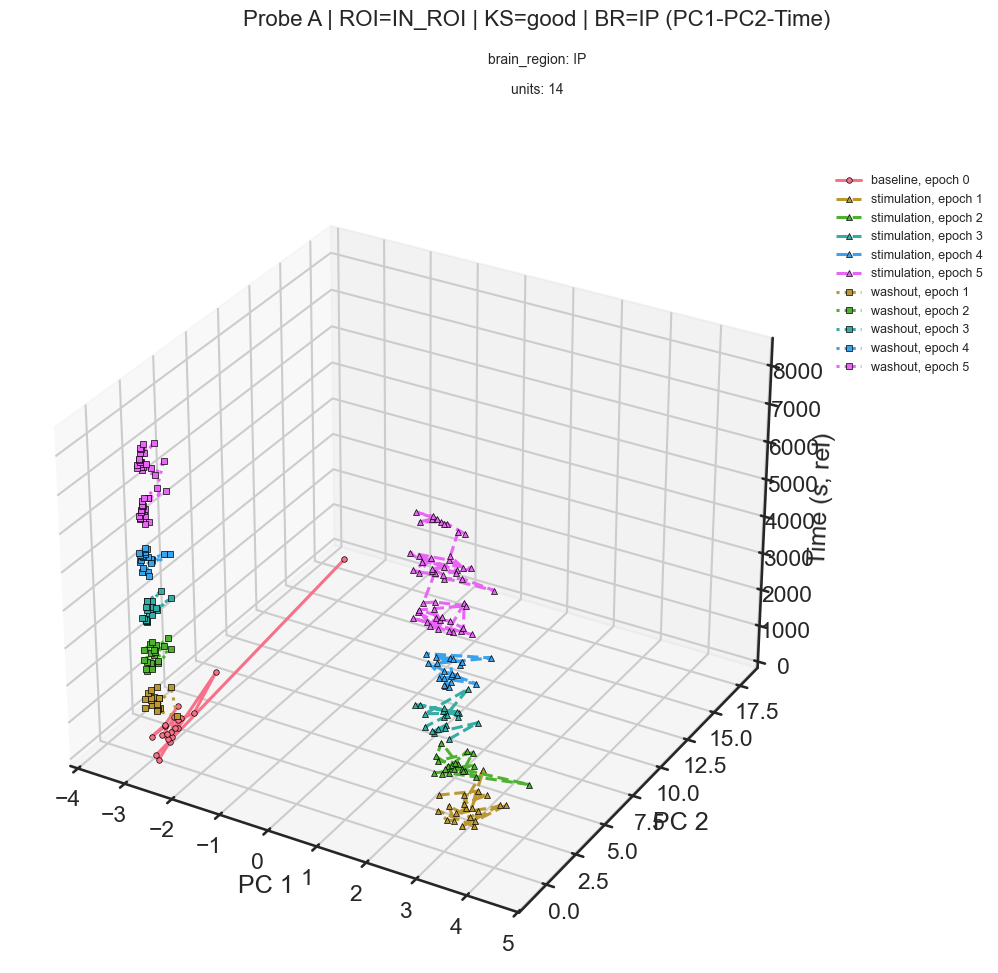

Requested tensor shape=(270, 117, 80) est_mem=0.01 GB
Probe: A | Brain region: SIM
Events: 270 Units: 117
EVR first 5: [0.5922 0.0753 0.0499 0.0286 0.0202]
brain_region: SIM
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\2D_scatter\probe_A_SIM_epoch_condition_scatter_2D.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\3D_scatter\probe_A_SIM_epoch_condition_scatter_3D.png


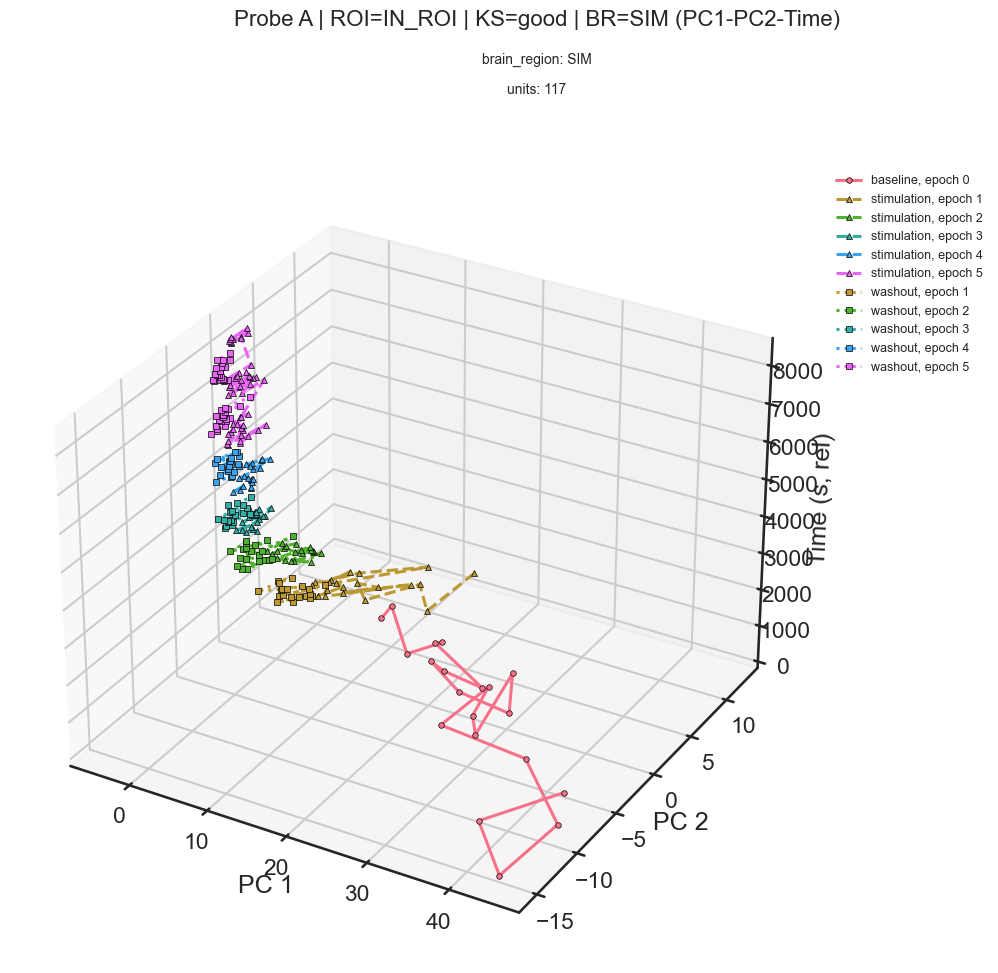

Requested tensor shape=(270, 6, 80) est_mem=0.00 GB
Probe: A | Brain region: unknown
Events: 270 Units: 6
EVR first 5: [0.6658 0.1959 0.1357 0.0012 0.001 ]
brain_region: unknown
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\2D_scatter\probe_A_unknown_epoch_condition_scatter_2D.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\3D_scatter\probe_A_unknown_epoch_condition_scatter_3D.png


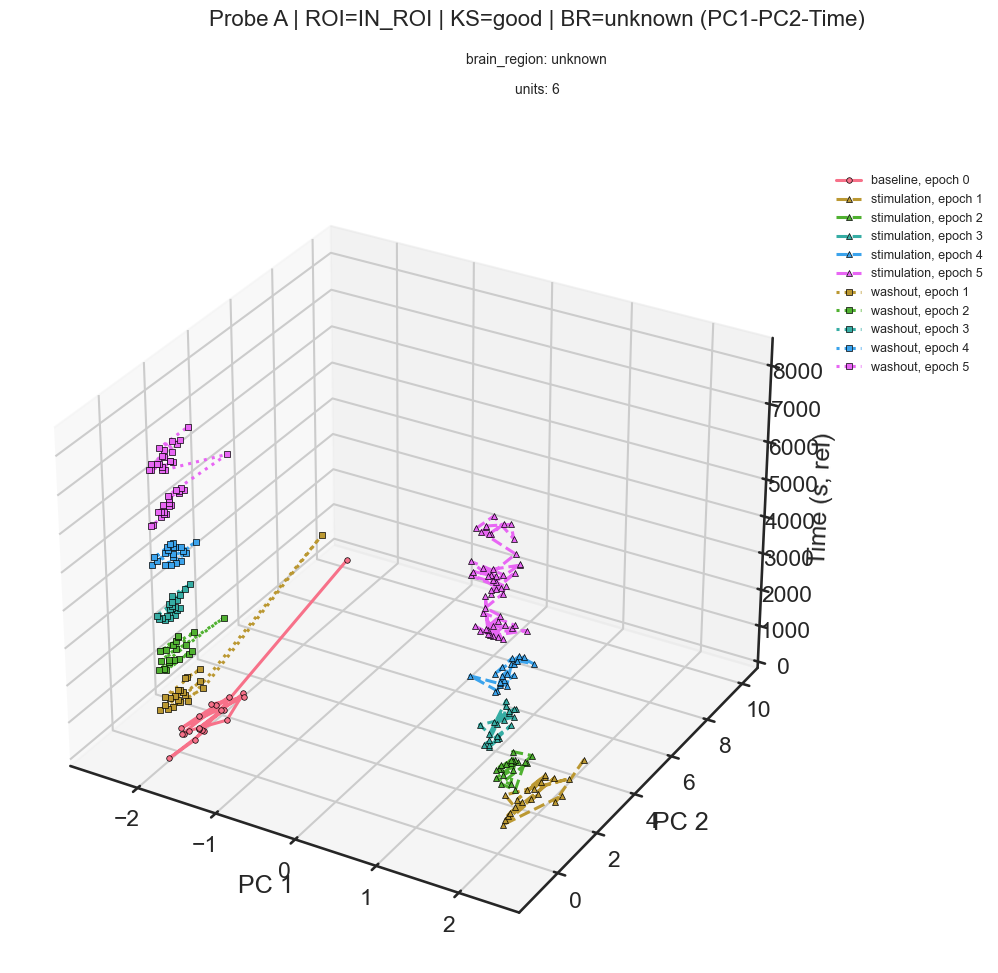

In [264]:
# Plot config for epoch/condition PCA
EPOCH_PCA_PROBE = 'A'
EPOCH_PCA_ROI_FILTER = PCA_ROI_FILTER
EPOCH_PCA_KSLABEL_FILTER = PCA_KSLABEL_FILTER
EPOCH_PCA_N_COMPONENTS = max(3, N_COMPONENTS)
EPOCH_PCA_INCLUDE_CONDITIONS = ["baseline", "stimulation", "washout"]

# ALWAYS split this probe by brain_region and plot each region separately
brain_regions_to_plot = _list_probe_brain_regions(
    merged_dic=merged_dic,
    probe=EPOCH_PCA_PROBE,
    roi_filter=EPOCH_PCA_ROI_FILTER,
    kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
)

if len(brain_regions_to_plot) == 0:
    raise ValueError(f"Probe {EPOCH_PCA_PROBE}: no brain regions found after ROI/KS filtering.")

for brain_region in brain_regions_to_plot:
    event_meta_probe, trials_ec, time_ec, Xp_ec, evr_ec = run_epoch_condition_pca_for_probe(
        probe=EPOCH_PCA_PROBE,
        merged_dic=merged_dic,
        event_meta=pca_event_meta,
        roi_filter=EPOCH_PCA_ROI_FILTER,
        kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
        include_conditions=EPOCH_PCA_INCLUDE_CONDITIONS,
        n_components=EPOCH_PCA_N_COMPONENTS,
        max_tensor_gb=PCA_MAX_TENSOR_GB,
        brain_region_filter=brain_region,
    )

    brain_region_subtitle = _probe_brain_region_label(
        merged_dic=merged_dic,
        probe=EPOCH_PCA_PROBE,
        roi_filter=EPOCH_PCA_ROI_FILTER,
        kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
        brain_region_filter=brain_region,
    )

    print("Probe:", EPOCH_PCA_PROBE, "| Brain region:", brain_region)
    print("Events:", len(event_meta_probe), "Units:", trials_ec.shape[1])
    print("EVR first 5:", np.round(evr_ec[:5], 4))
    print(brain_region_subtitle)

    plot_epoch_condition_scatter(
        Xp=Xp_ec,
        event_meta=event_meta_probe,
        title_prefix=f"Probe {EPOCH_PCA_PROBE} | ROI={EPOCH_PCA_ROI_FILTER} | KS={EPOCH_PCA_KSLABEL_FILTER} | BR={brain_region}",
        subtitle=brain_region_subtitle,
        probe=EPOCH_PCA_PROBE,
        brain_region=brain_region,
        n_units=trials_ec.shape[1],
        show_plots=False,
    )

    plot_epoch_condition_scatter_3d(
        Xp=Xp_ec,
        event_meta=event_meta_probe,
        title_prefix=f"Probe {EPOCH_PCA_PROBE} | ROI={EPOCH_PCA_ROI_FILTER} | KS={EPOCH_PCA_KSLABEL_FILTER} | BR={brain_region}",
        subtitle=brain_region_subtitle,
        probe=EPOCH_PCA_PROBE,
        brain_region=brain_region,
        n_units=trials_ec.shape[1],
        show_plots=False,
    )

    plot_epoch_condition_line_3d_time(
        Xp=Xp_ec,
        event_meta=event_meta_probe,
        title_prefix=f"Probe {EPOCH_PCA_PROBE} | ROI={EPOCH_PCA_ROI_FILTER} | KS={EPOCH_PCA_KSLABEL_FILTER} | BR={brain_region}",
        subtitle=brain_region_subtitle,
        probe=EPOCH_PCA_PROBE,
        brain_region=brain_region,
        time_col="start_time",
        n_units=trials_ec.shape[1],
        show_plots=True
    )




### Run Epoch/Condition PCA (Batch Probe)


In [222]:
if PCA_SELECTED_PROBES is None:
    probes_to_run = sorted(list(merged_dic.keys()))
else:
    probes_to_run = [p for p in PCA_SELECTED_PROBES if p in merged_dic]

for probe in probes_to_run:
    EPOCH_PCA_PROBE = probe
    EPOCH_PCA_ROI_FILTER = PCA_ROI_FILTER
    EPOCH_PCA_KSLABEL_FILTER = PCA_KSLABEL_FILTER
    EPOCH_PCA_N_COMPONENTS = max(3, N_COMPONENTS)
    EPOCH_PCA_INCLUDE_CONDITIONS = ["baseline", "stimulation", "washout"]

    brain_regions_to_plot = _list_probe_brain_regions(
        merged_dic=merged_dic,
        probe=EPOCH_PCA_PROBE,
        roi_filter=EPOCH_PCA_ROI_FILTER,
        kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
    )
    if len(brain_regions_to_plot) == 0:
        print(f"Probe {EPOCH_PCA_PROBE}: skipped (no brain regions after filters)")
        continue

    for brain_region in brain_regions_to_plot:
        event_meta_probe, trials_ec, time_ec, Xp_ec, evr_ec = run_epoch_condition_pca_for_probe(
            probe=EPOCH_PCA_PROBE,
            merged_dic=merged_dic,
            event_meta=pca_event_meta,
            roi_filter=EPOCH_PCA_ROI_FILTER,
            kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
            include_conditions=EPOCH_PCA_INCLUDE_CONDITIONS,
            n_components=EPOCH_PCA_N_COMPONENTS,
            max_tensor_gb=PCA_MAX_TENSOR_GB,
            brain_region_filter=brain_region,
        )

        brain_region_subtitle = _probe_brain_region_label(
            merged_dic=merged_dic,
            probe=EPOCH_PCA_PROBE,
            roi_filter=EPOCH_PCA_ROI_FILTER,
            kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
            brain_region_filter=brain_region,
        )

        print("Probe:", EPOCH_PCA_PROBE, "| Brain region:", brain_region)
        print("Events:", len(event_meta_probe), "Units:", trials_ec.shape[1])
        print("EVR first 5:", np.round(evr_ec[:5], 4))
        print(brain_region_subtitle)

        plot_epoch_condition_scatter(
            Xp=Xp_ec,
            event_meta=event_meta_probe,
            title_prefix=f"Probe {EPOCH_PCA_PROBE} | ROI={EPOCH_PCA_ROI_FILTER} | KS={EPOCH_PCA_KSLABEL_FILTER} | BR={brain_region}",
            subtitle=brain_region_subtitle,
            probe=EPOCH_PCA_PROBE,
            brain_region=brain_region,
            n_units=trials_ec.shape[1],
            show_plots=False,
        )

        plot_epoch_condition_scatter_3d(
            Xp=Xp_ec,
            event_meta=event_meta_probe,
            title_prefix=f"Probe {EPOCH_PCA_PROBE} | ROI={EPOCH_PCA_ROI_FILTER} | KS={EPOCH_PCA_KSLABEL_FILTER} | BR={brain_region}",
            subtitle=brain_region_subtitle,
            probe=EPOCH_PCA_PROBE,
            brain_region=brain_region,
            n_units=trials_ec.shape[1],
            show_plots=False,
        )

        plot_epoch_condition_line_3d_time(
            Xp=Xp_ec,
            event_meta=event_meta_probe,
            title_prefix=f"Probe {EPOCH_PCA_PROBE} | ROI={EPOCH_PCA_ROI_FILTER} | KS={EPOCH_PCA_KSLABEL_FILTER} | BR={brain_region}",
            subtitle=brain_region_subtitle,
            probe=EPOCH_PCA_PROBE,
            brain_region=brain_region,
            time_col="start_time",
            n_units=trials_ec.shape[1],
            show_plots=False,
        )




Requested tensor shape=(270, 14, 80) est_mem=0.00 GB
Probe: A | Brain region: IP
Events: 270 Units: 14
EVR first 5: [0.6409 0.1279 0.074  0.0584 0.0497]
brain_region: IP
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\2D_scatter\probe_A_IP_epoch_condition_scatter_2D.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\3D_scatter\probe_A_IP_epoch_condition_scatter_3D.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\3D_PC12_Time\probe_A_region_IP_epoch_condition_line_PC12_Time.png
Requested tensor shape=(270, 117, 80) est_mem=0.01 GB
Probe: A | Brain region: SIM
Events: 270 Units: 117
EVR first 5: [0.5922 0.0753 0.0499 0.0286 0.0202]
brain_region: SIM
PCA plot saved to H:\Grant\N

### Batch Run: Grouped Epoch/Condition Plot Sets
Each probe/brain_region now saves grouped figures:

- Group 1: base trial-level epoch plots (3 subplots)

- Group 2: epoch-mean family (4 subplots)

- Group 3: per-trial time-bin family (3 subplots)

- Group 4: one-line-per-epoch population family (3 subplots)


### Advanced Epoch PCA Plots (Epoch Means + Trial-Time Lines)
Use this after running a single-probe epoch PCA cell so `event_meta_probe`, `trials_ec`, and `Xp_ec` exist.


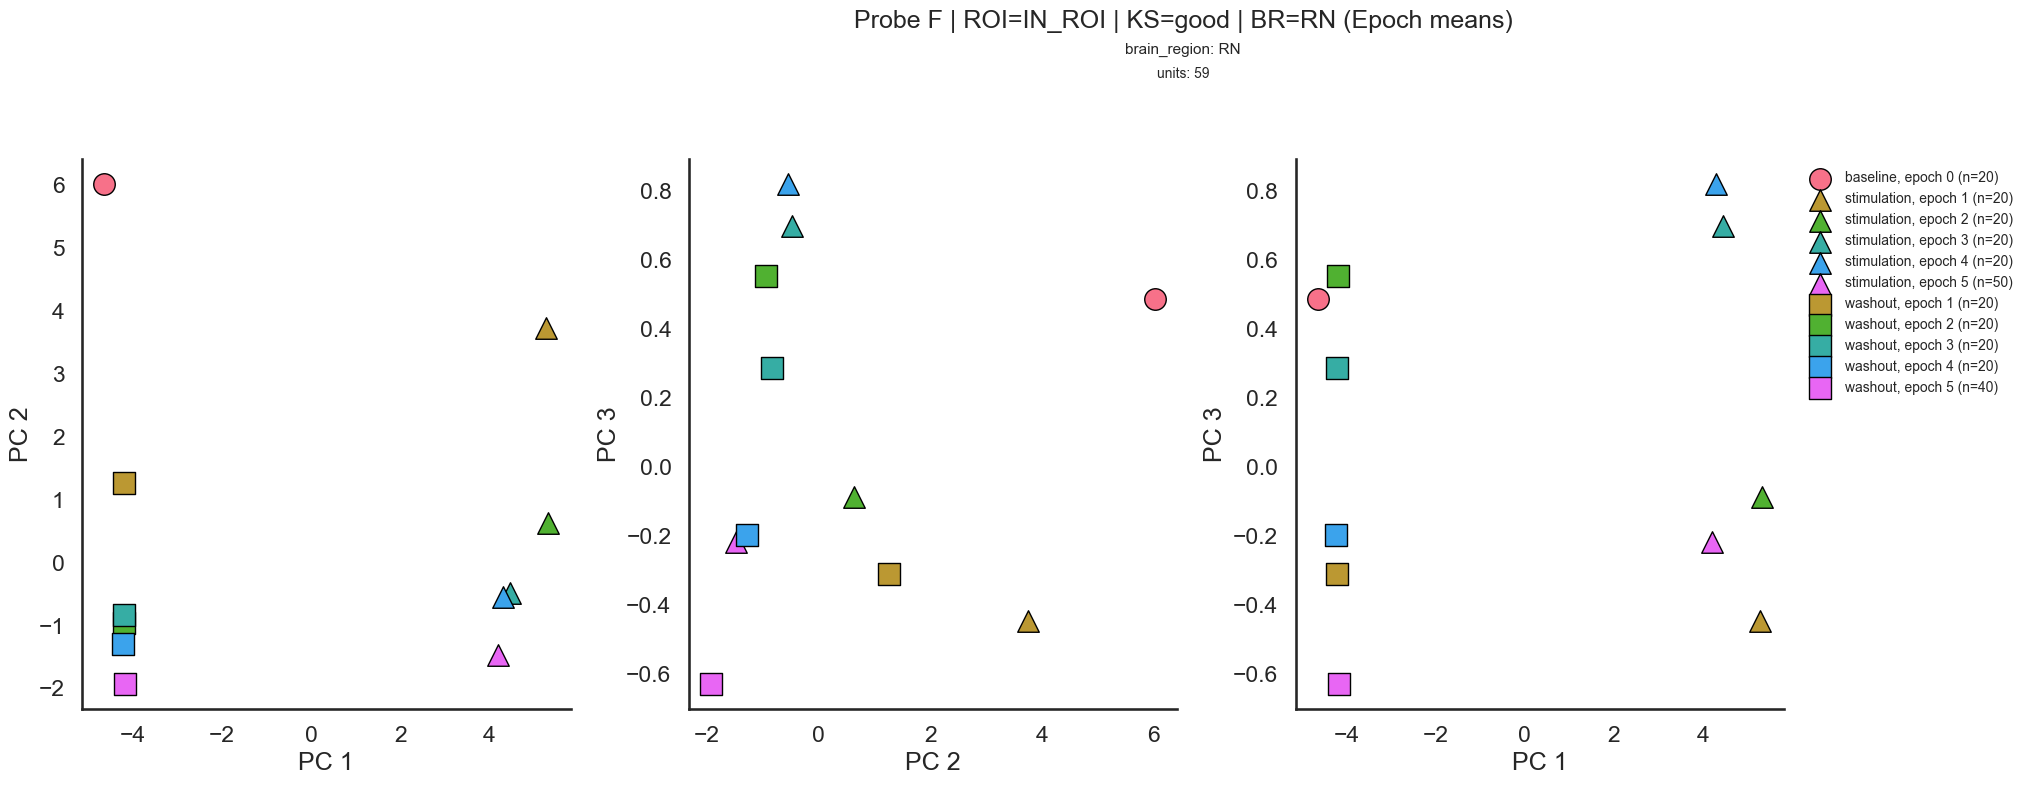

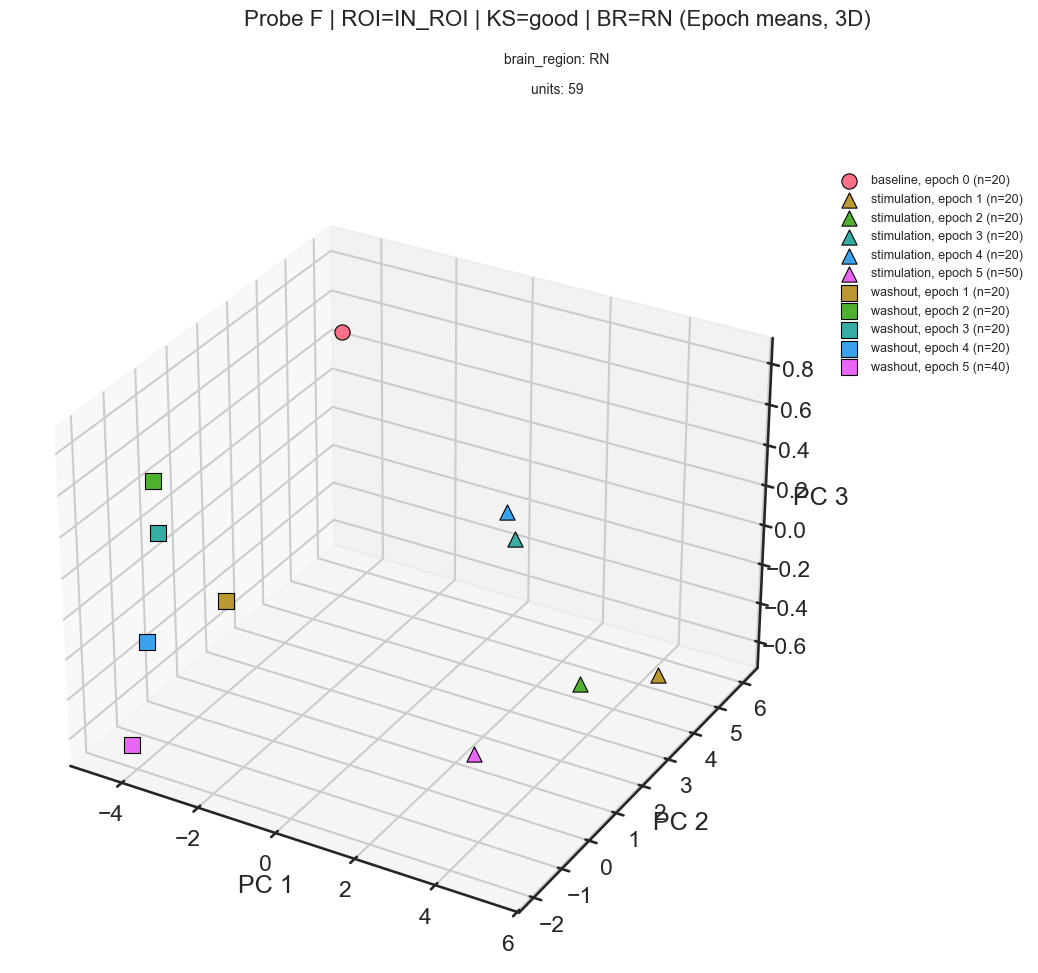

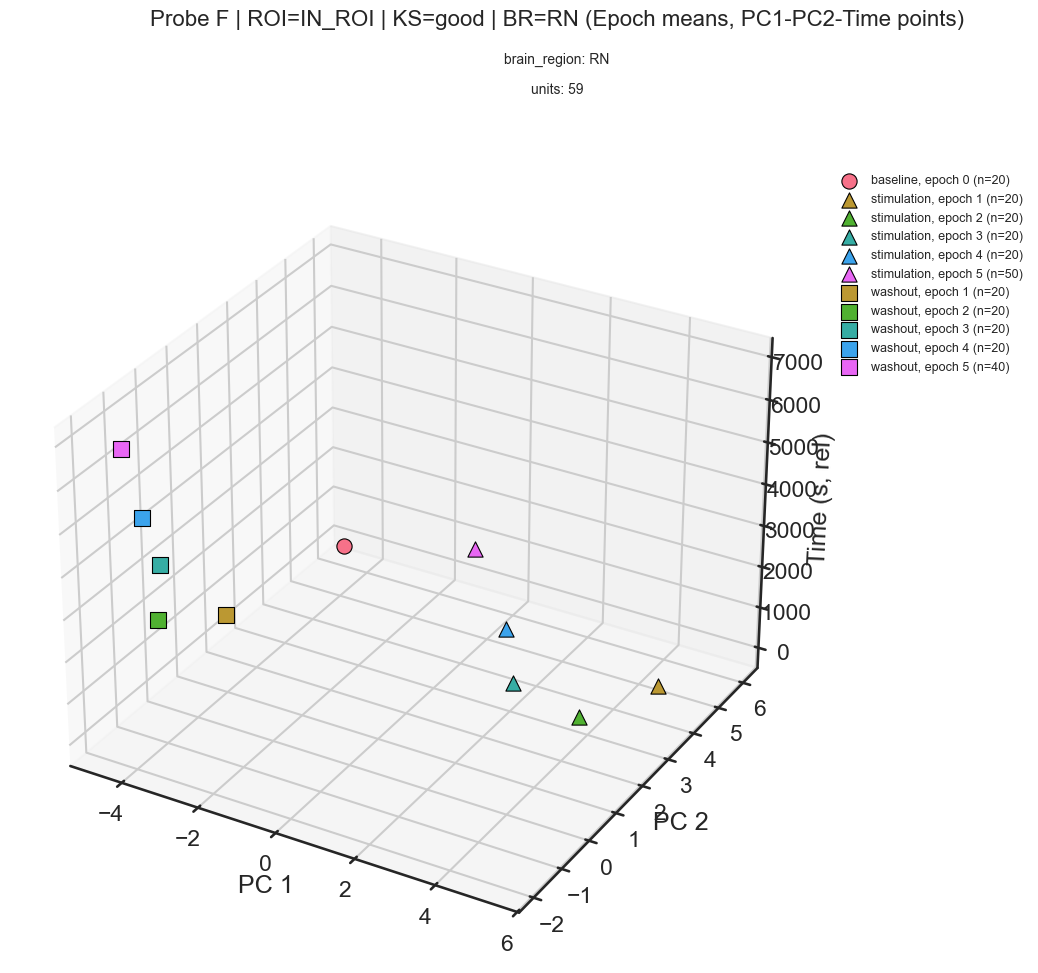

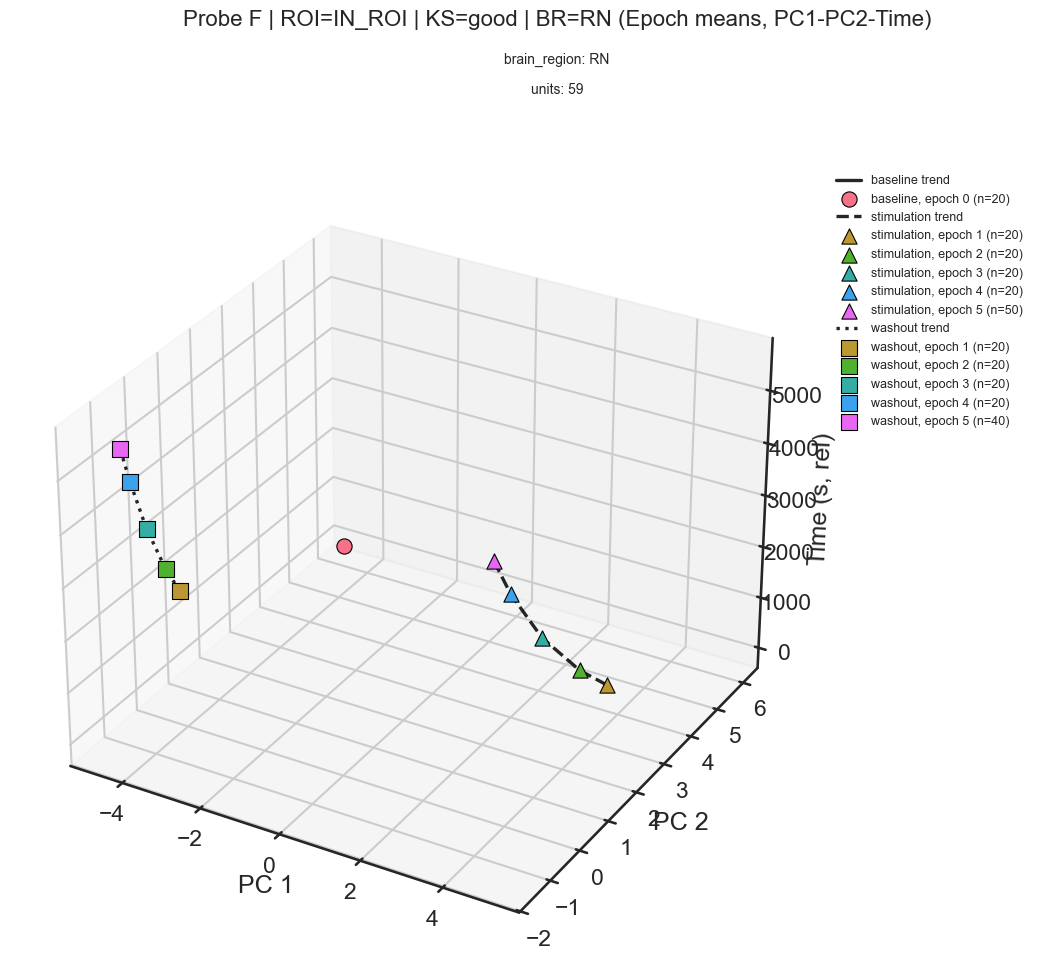

Trial-time PCA EVR first 5: [0.3392 0.0294 0.0278 0.0262 0.0244]


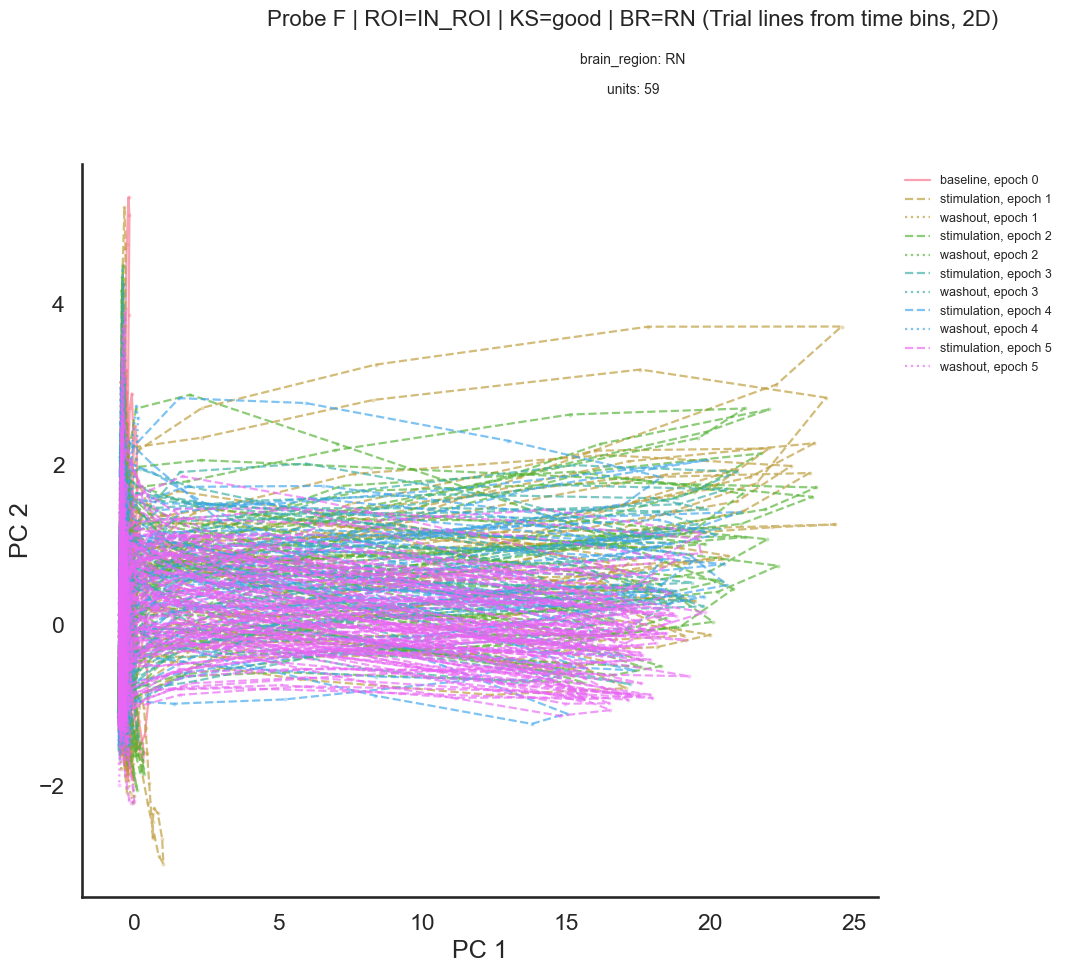

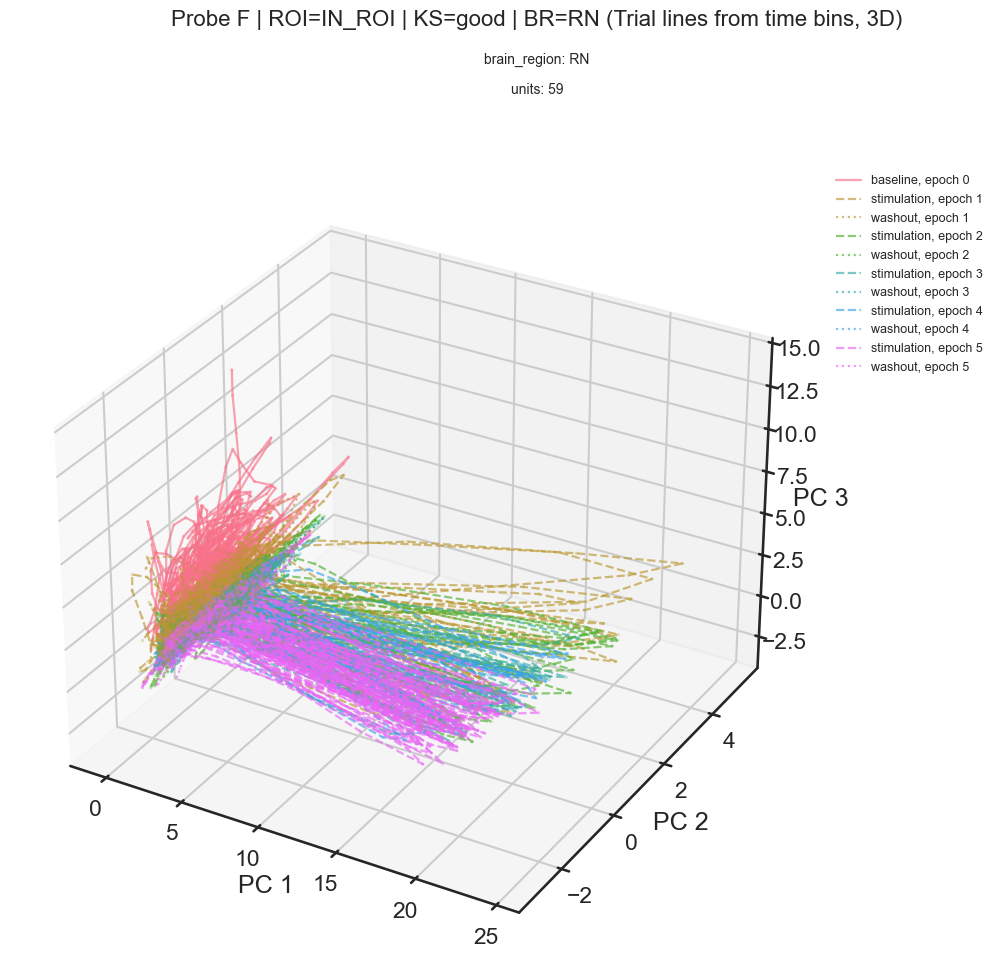

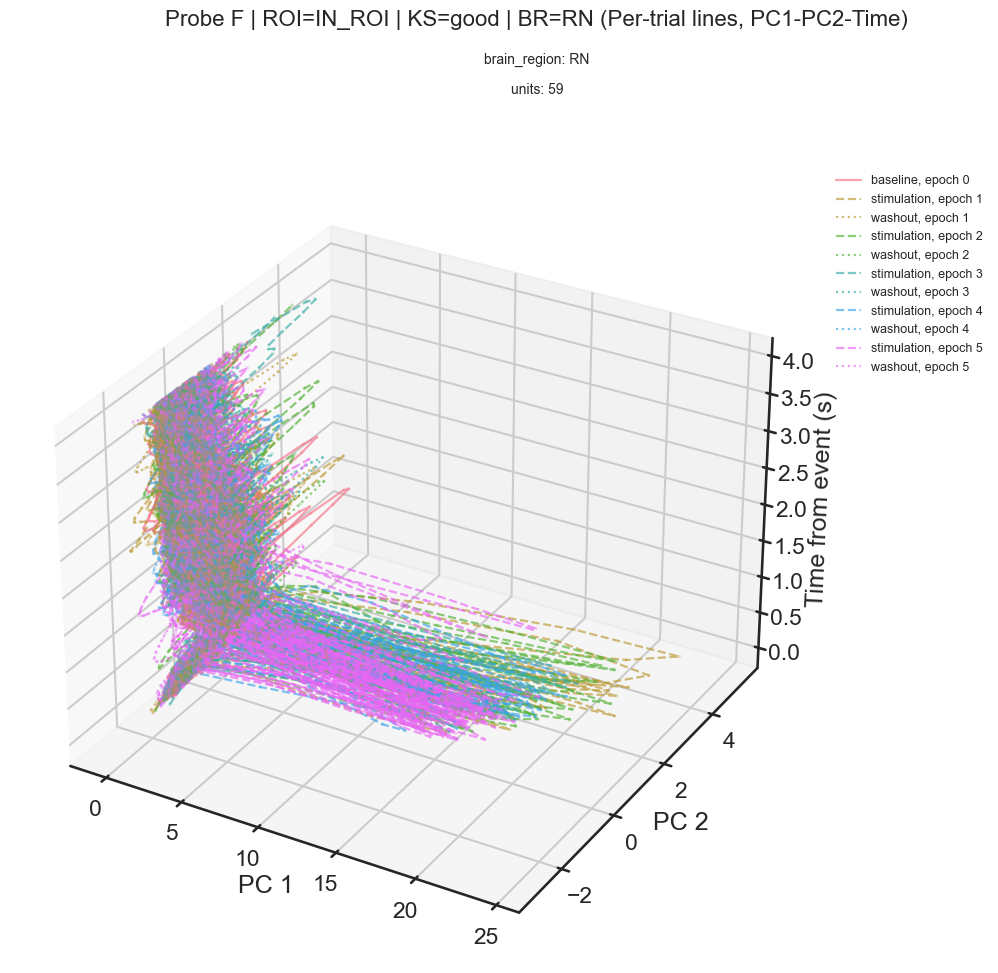

In [ ]:
ADV_PLOTS_RUN = True
ADV_PLOTS_SHOW = True
ADV_PLOTS_SMOOTH_SIGMA = 1.5
ADV_PLOTS_N_COMPONENTS = max(3, N_COMPONENTS)

if ADV_PLOTS_RUN:
    required = ["event_meta_probe", "trials_ec", "Xp_ec", "EPOCH_PCA_PROBE", "time_ec"]
    missing = [k for k in required if k not in globals()]
    if len(missing) > 0:
        raise ValueError(f"Missing required variables for advanced plots: {missing}. Run the single-probe epoch PCA cell first.")

    _probe = EPOCH_PCA_PROBE
    _brain_region = globals().get("brain_region", "unknown")
    _subtitle = _probe_brain_region_label(
        merged_dic=merged_dic,
        probe=_probe,
        roi_filter=EPOCH_PCA_ROI_FILTER,
        kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
        brain_region_filter=_brain_region,
    )
    _title = f"Probe {_probe} | ROI={EPOCH_PCA_ROI_FILTER} | KS={EPOCH_PCA_KSLABEL_FILTER} | BR={_brain_region}"

    # Set 1 grouped: base trial-level epoch plots
    plot_epoch_condition_group_base_trial(
        Xp=Xp_ec,
        event_meta=event_meta_probe,
        title_prefix=_title,
        subtitle=_subtitle,
        probe=_probe,
        brain_region=_brain_region,
        time_col="start_time",
        n_units=trials_ec.shape[1],
        show_plots=ADV_PLOTS_SHOW,
    )

    # Set 2 grouped: epoch-mean family
    plot_epoch_condition_group_epochmean(
        Xp=Xp_ec,
        event_meta=event_meta_probe,
        title_prefix=_title,
        subtitle=_subtitle,
        probe=_probe,
        brain_region=_brain_region,
        smooth_sigma=ADV_PLOTS_SMOOTH_SIGMA,
        n_units=trials_ec.shape[1],
        show_plots=ADV_PLOTS_SHOW,
    )

    # Set 3 grouped: per-trial time-bin family
    trial_time_scores, trial_time_evr = pca_trial_timebin_scores(
        trials=trials_ec,
        n_components=ADV_PLOTS_N_COMPONENTS,
    )
    print("Trial-time PCA EVR first 5:", np.round(trial_time_evr[:5], 4))

    plot_epoch_condition_group_trial_time(
        trial_time_scores=trial_time_scores,
        event_meta=event_meta_probe,
        bin_time=time_ec,
        title_prefix=_title,
        subtitle=_subtitle,
        probe=_probe,
        brain_region=_brain_region,
        smooth_sigma=ADV_PLOTS_SMOOTH_SIGMA,
        n_units=trials_ec.shape[1],
        show_plots=ADV_PLOTS_SHOW,
    )

    # Set 4 grouped: one-line-per-epoch population family
    epoch_info_df, epoch_traj, epoch_evr = pca_epoch_population_timebin_trajectories(
        trials=trials_ec,
        event_meta=event_meta_probe,
        n_components=ADV_PLOTS_N_COMPONENTS,
    )
    print("Epoch-population PCA EVR first 5:", np.round(epoch_evr[:5], 4))

    plot_epoch_condition_group_epoch_population(
        epoch_info_df=epoch_info_df,
        epoch_traj=epoch_traj,
        bin_time=time_ec,
        title_prefix=_title,
        subtitle=_subtitle,
        probe=_probe,
        brain_region=_brain_region,
        smooth_sigma=ADV_PLOTS_SMOOTH_SIGMA,
        n_units=trials_ec.shape[1],
        show_plots=ADV_PLOTS_SHOW,
    )


In [306]:
EPOCH_ALL_PLOTS_BATCH_RUN = True
EPOCH_ALL_PLOTS_SHOW = False
EPOCH_ALL_PLOTS_SMOOTH_SIGMA = 1.5
EPOCH_ALL_PLOTS_N_COMPONENTS = max(3, N_COMPONENTS)

if EPOCH_ALL_PLOTS_BATCH_RUN:
    if PCA_SELECTED_PROBES is None:
        _probes = sorted(list(merged_dic.keys()))
    else:
        _probes = [p for p in PCA_SELECTED_PROBES if p in merged_dic]

    for _probe in _probes:
        _roi = PCA_ROI_FILTER
        _ks = PCA_KSLABEL_FILTER
        _conds = ["baseline", "stimulation", "washout"]

        _brain_regions = _list_probe_brain_regions(
            merged_dic=merged_dic,
            probe=_probe,
            roi_filter=_roi,
            kslabel_filter=_ks,
        )
        if len(_brain_regions) == 0:
            print(f"Probe {_probe}: skipped (no brain regions after filters)")
            continue

        for _br in _brain_regions:
            try:
                _em, _trials, _time, _Xp, _evr = run_epoch_condition_pca_for_probe(
                    probe=_probe,
                    merged_dic=merged_dic,
                    event_meta=pca_event_meta,
                    roi_filter=_roi,
                    kslabel_filter=_ks,
                    include_conditions=_conds,
                    n_components=max(3, EPOCH_ALL_PLOTS_N_COMPONENTS),
                    max_tensor_gb=PCA_MAX_TENSOR_GB,
                    brain_region_filter=_br,
                )
            except Exception as e:
                print(f"Probe {_probe} | BR={_br}: skipped due to {e}")
                continue

            _subtitle = _probe_brain_region_label(
                merged_dic=merged_dic,
                probe=_probe,
                roi_filter=_roi,
                kslabel_filter=_ks,
                brain_region_filter=_br,
            )
            _title = f"Probe {_probe} | ROI={_roi} | KS={_ks} | BR={_br}"
            _n_units = _trials.shape[1]

            print(f"Running grouped epoch plot sets for probe={_probe}, brain_region={_br}, units={_n_units}, events={len(_em)}")

            # Group 1: Base trial-level epoch plots
            plot_epoch_condition_group_base_trial(
                Xp=_Xp,
                event_meta=_em,
                title_prefix=_title,
                subtitle=_subtitle,
                probe=_probe,
                brain_region=_br,
                time_col="start_time",
                n_units=_n_units,
                show_plots=EPOCH_ALL_PLOTS_SHOW,
            )

            # Group 2: Epoch-mean family
            plot_epoch_condition_group_epochmean(
                Xp=_Xp,
                event_meta=_em,
                title_prefix=_title,
                subtitle=_subtitle,
                probe=_probe,
                brain_region=_br,
                smooth_sigma=EPOCH_ALL_PLOTS_SMOOTH_SIGMA,
                n_units=_n_units,
                show_plots=EPOCH_ALL_PLOTS_SHOW,
            )

            # Group 3: Per-trial time-bin family
            _scores, _scores_evr = pca_trial_timebin_scores(
                trials=_trials,
                n_components=max(3, EPOCH_ALL_PLOTS_N_COMPONENTS),
            )
            print("  trial-time EVR first 3:", np.round(_scores_evr[:3], 4))

            plot_epoch_condition_group_trial_time(
                trial_time_scores=_scores,
                event_meta=_em,
                bin_time=_time,
                title_prefix=_title,
                subtitle=_subtitle,
                probe=_probe,
                brain_region=_br,
                smooth_sigma=EPOCH_ALL_PLOTS_SMOOTH_SIGMA,
                n_units=_n_units,
                show_plots=EPOCH_ALL_PLOTS_SHOW,
            )

            # Group 4: One-line-per-epoch population family
            _epoch_info, _epoch_traj, _epoch_evr = pca_epoch_population_timebin_trajectories(
                trials=_trials,
                event_meta=_em,
                n_components=max(3, EPOCH_ALL_PLOTS_N_COMPONENTS),
            )
            print("  epoch-population EVR first 3:", np.round(_epoch_evr[:3], 4))

            plot_epoch_condition_group_epoch_population(
                epoch_info_df=_epoch_info,
                epoch_traj=_epoch_traj,
                bin_time=_time,
                title_prefix=_title,
                subtitle=_subtitle,
                probe=_probe,
                brain_region=_br,
                smooth_sigma=EPOCH_ALL_PLOTS_SMOOTH_SIGMA,
                n_units=_n_units,
                show_plots=EPOCH_ALL_PLOTS_SHOW,
            )
else:
    print("Set EPOCH_ALL_PLOTS_BATCH_RUN=True to run grouped batch epoch plotting.")


Requested tensor shape=(270, 14, 80) est_mem=0.00 GB
Running grouped epoch plot sets for probe=A, brain_region=IP, units=14, events=270
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\Grouped_BaseTrial\probe_A_region_IP_group_base_trial.png
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\Grouped_EpochMean\probe_A_region_IP_group_epochmean.png
  trial-time EVR first 3: [0.6276 0.0906 0.0725]
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\PCA_by_Epoch\Grouped_TrialTime\probe_A_region_IP_group_trial_time.png
  epoch-population EVR first 3: [0.6847 0.0885 0.0754]
PCA plot saved to H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_p